# EBA 2025 stress test: bank profit shortfalls and their drivers

**64 banks · projection years 2025–2027 · EUR millions**

For every bank, this notebook compares the sum of the three annual after-tax profits in the baseline
and adverse scenarios, then reconciles their difference to the separately disclosed P&L components.
Positive contributions increase the shortfall; negative contributions offset it. These are accounting
attributions of a joint scenario, not estimates of the causal effect of independently shocked risk factors.

**Run:** use Python 3.10 or later and **Restart Kernel and Run All**. Dependencies:
`numpy`, `pandas`, `openpyxl`, `matplotlib`, and `IPython` (plus a Jupyter kernel).
If needed, install them in your environment with
`python -m pip install numpy pandas openpyxl matplotlib ipykernel`.
The original public data files are embedded as a compressed, checksummed snapshot; the default run
needs no internet, database, credentials, external scripts, or adjacent files. All 64 bank reports
are generated and retained in the saved notebook.

The analysis uses annual **profit or loss for the year**, including minority interests, before
dividend distributions. It does not use retained earnings, CET1 changes, or end-2027 profit alone.
The 2024 starting point is excluded from the three-year sums. Figures are hypothetical scenario
outcomes under the stress-test assumptions, not forecasts of realised earnings.

## 1. Sources and the 2025 measurement boundary

The mappings below were established from the **January 2025 final methodology and templates**,
then checked against the published **ST2025 data dictionary** and actual bank disclosures.

| Source | Evidence used |
|---|---|
| [EBA 2025 publication page](https://www.eba.europa.eu/eu-wide-stress-test-2025/) | Final releases, database release `763451`, bank PDFs and revisions |
| [Methodological Note](https://www.eba.europa.eu/sites/default/files/2025-01/0246e2f3-fa57-47d1-99f2-7a5b80cae509/2025%20EU-wide%20stress%20test%20-%20Methodological%20Note.pdf) | §§1.3, 2, 3, 4, 5 and 6; especially §§346–350, 428–430, 491, 527–533 |
| [Template Guidance](https://www.eba.europa.eu/sites/default/files/2025-01/db21dc89-5af6-4cab-a3a0-3a631eb48378/2025%20EU-wide%20stress%20test%20-%20Template%20Guidance.pdf) | §§6–8 (public versus supervisory templates), 13–15 (units and zeros), 191–193 (NII), 264–278 (P&L) |
| [Final workbook](https://www.eba.europa.eu/sites/default/files/2025-01/6116a07a-5d8a-45ac-9c97-447c7317fd83/2025%20EU-wide%20stress%20test%20-%20Templates.xlsx) | Exact formulas in `TRA_P&L`, `CSV_P&L`, `CSV_NII_SUM`; blank versus applicable cells |
| [Database guide](https://www.eba.europa.eu/assets/st25/full_database/763451/CSV_guide.pdf) | pp. 2–4: file contents, UTF-8, dimensions and scenario codes |
| [Data dictionary](https://www.eba.europa.eu/assets/st25/full_database/763451/Data_Dictionary.xlsx) and [Metadata](https://www.eba.europa.eu/assets/st25/full_database/763451/Metadata_TR.xlsx) | `SDD`, `ListOfBanks`, `Scenario`: 2025 item identities and all 64 banks |
| [Other templates CSV](https://www.eba.europa.eu/assets/st25/full_database/763451/TRA_OTH.csv) | Numerical source for the complete P&L bridge and independent summary checks |
| [Results report](https://www.eba.europa.eu/sites/default/files/2025-08/0178b9c5-2f0d-42ee-8226-6fa0a87c0d6c/2025%20EU-wide%20stress%20test%20-%20Results.pdf) | pp. 30–31 / Figure 13 and Table A5: aggregate profit and loss cross-checks |
| [Results FAQs](https://www.eba.europa.eu/sites/default/files/2025-08/5227881b-3a1c-49ee-b988-9478874cb6e5/2025%20EU-wide%20stress%20test%20-%20FAQs%20-%20Results.pdf) | Questions 6, 9 and 22: revised methodology, centralised NII and repricing channels |

Source review date: **3 October 2026**. The report's data cut-off is **17 July 2025, 16:00 CET**.
This notebook pins the downloaded database bytes rather than silently accepting future revisions.
The [December 2025 Svenska Handelsbanken revision](https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_NHBDILHZTYCNBV5UYZ31_rev.pdf)
states on page 1 that it only changes standardised risk exposure amounts for the output floor,
does not affect overall results, and was not incorporated into the database. Its P&L is checked below.

### What can be measured separately?

| Risk or P&L effect | Public measurement | Interpretation and limits |
|---|---|---|
| Credit risk through impairments | `2536010` | Direct signed impairment P&L; a proxy for the disclosed credit-loss channel, not all credit-related effects. Includes amortised-cost securitisation impairments through `CSV_CR_SEC_SUM`; excludes CCR default losses and REA movements. |
| Interest-related earnings | `2536001` | Total NII scenario difference, an earnings proxy. Includes reference rates, margins, funding spreads, credit deterioration, hedges and caps. **It is not a pure IRRBB measure**; no standalone IRRBB attribution is available. |
| Trading and valuation effects | `2536006` | Public trading P&L includes valuation/reserve effects and projected client revenues. The difference is not a gross market-risk loss measure. CVA/FuVA and liquidity-reserve components are not separately disclosed. |
| Non-trading FVPL revaluation | `2536007` | Separate adverse-2025 revaluation line. The other projection cells are structurally absent. Hedge-accounting effects can also sit in other operating P&L; this line plus trading is not the whole market-risk module. |
| Counterparty defaults (CCR) | Embedded in `2536011` | `CSV_P&L!O53` is separately calculated in supervisory templates, but the public P&L folds it into other income/expenses. No bank-level standalone amount can be extracted here. |
| Conduct and other operational risk | Embedded in `2536011` for projections | Supervisory `CSV_OR_GEN` / `CSV_P&L` distinguish them. Public disclosures aggregate them with other expenses. **Unavailable separately**, not assumed zero or inferred from operational-risk REA. |
| Fees, dividend income | `2536005`, `2536004` | Direct earnings components. Dividend income is different from dividends paid. |
| Other operating P&L | `2536008` | Disclosed net aggregate; includes remaining operating items and hedge-accounting effects. Not an unexplained residual. |
| Other income and expenses | `2536011` | Disclosed net aggregate, including costs, depreciation, other provisions/impairments, equity-method earnings, operational losses, CCR losses and pre-tax MDA adjustments. No invented sub-allocation. |
| Taxes | `2536013` | Use the reported **signed** P&L amount, including permitted deferred-tax effects. Do not multiply each contribution by 70%; tax accounting depends on losses and DTA treatment. |
| Discontinued operations | `2536014`, historical only | No projection cells. `CSV_P&L!L75=L72` (and corresponding years/scenarios) means no separate projected discontinued-operations contribution. |
| Unexplained residual | Profit less selected components | Retained explicitly at full precision; separate from both disclosed “other” aggregates. Material residuals stop the analysis. |

**Excluded from the bridge:** OCI fair-value movements, prudential valuation adjustments deducted
directly from capital, pension OCI, REA/RWA changes and output floors, regulatory deductions,
capital issuance, distributions and minority-interest allocation. Accounting valuation losses already
in P&L are retained. The one-off-adjustment and total MDA memo rows are not added again because
their relevant P&L effects are already reflected in the reported lines; some MDA effects only concern
distributions. Stock-of-provision changes and the additional credit-risk CSVs are not needed to
measure the published impairment flow and would risk overlapping it.

The workbook equations establish the boundaries: `TRA_P&L!G15=G16-SUM(G8,G11,G12,G13,G14)`
and `G18=G19-SUM(G16:G17)`. These disclosed “other” lines complete the operating and pre-tax
identities. The tax label in the dictionary is potentially misleading: its actual formula points to
`CSV_P&L!L71`, where expenses are negative and income is positive. Profit adds that signed amount.

### Changes from the supplied notebooks

The [2023 benchmarking notebook](https://github.com/at621/eba_stresstest_2023/blob/main/stresstest_benchmarking.ipynb)
and [data-preparation notebook](https://github.com/at621/eba_stresstest/blob/main/data_preparation.ipynb)
were reviewed. The latter currently references the 2021 exercise internally. This adaptation retains
dictionary-based decoding but replaces year-one ratios with three-year P&L differences, uses the
2025 schema and explicit item IDs, keys by LEI, and removes PostgreSQL dependencies. Unlike the
earlier loaders, it preserves actual zeros, rejects unknown numeric tokens, and never sums duplicate
records with `pivot_table`. Old item codes or metadata sheet names are not assumed to apply.

In [1]:
from pathlib import Path
from io import BytesIO
from urllib.request import Request, urlopen
import base64
import gzip
import hashlib
import html
import importlib.metadata
import platform
import re
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import StrMethodFormatter
from IPython.display import HTML, Markdown, display

# 'embedded' is portable and offline; 'local' reads these same three files from DATA_DIR.
# 'download' fetches pinned public URLs and verifies their hashes, without changing local files.
DATA_MODE = 'embedded'
DATA_DIR = Path('data/eba_2025')
EXPORT_RESULTS = False  # Optional CSVs and chart PNGs under OUTPUT_DIR.
OUTPUT_DIR = Path('output/eba_2025')
YEARS = (2025, 2026, 2027)
PERIODS = tuple(year * 100 + 12 for year in YEARS)
ABS_TOL = 1e-5  # EUR million: EUR 10, comfortably above floating-point noise.
EXPECTED_BANKS = 64

pd.set_option('display.max_colwidth', 110)
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'figure.dpi': 110,
    'savefig.dpi': 140, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
display(HTML('''<style>
.eba-table-wrap { overflow-x:auto; margin:10px 0 20px; }
.eba-table { border-collapse:collapse; font-size:13px; width:100%; }
.eba-table th { text-align:right; padding:7px 10px; border-bottom:2px solid #203b59; }
.eba-table td { text-align:right; padding:5px 10px; border-bottom:1px solid #e4e8ec; }
.eba-table th:first-child, .eba-table td:first-child { text-align:left; }
.eba-table tbody tr:nth-child(even) { background:#f6f8fa; }
.eba-note { color:#465260; font-size:13px; }
</style>'''))

def show_table(frame, caption=None, digits=2):
    table = frame.to_html(index=False, classes='eba-table', border=0,
                          float_format=lambda value: f'{value:,.{digits}f}', escape=True)
    heading = f'<p><strong>{html.escape(caption)}</strong></p>' if caption else ''
    display(HTML(heading + '<div class="eba-table-wrap">' + table + '</div>'))

versions = {'Python': platform.python_version()}
versions.update({name: importlib.metadata.version(name)
                 for name in ['numpy', 'pandas', 'openpyxl', 'matplotlib', 'IPython']})
print('Runtime:', ', '.join(f'{key} {value}' for key, value in versions.items()))

Runtime: Python 3.13.1, numpy 2.2.4, pandas 2.2.3, openpyxl 3.1.5, matplotlib 3.10.1, IPython 9.0.2


In [2]:
SOURCE_MANIFEST = {'TRA_OTH.csv': {'url': 'https://www.eba.europa.eu/assets/st25/full_database/763451/TRA_OTH.csv', 'sha256': 'e7a48b99984d8728b5b24285d9b00aed94b605a7855705f04b41c5b21da5378a', 'bytes': 6223488, 'review_date': '2026-10-03'}, 'Data_Dictionary.xlsx': {'url': 'https://www.eba.europa.eu/assets/st25/full_database/763451/Data_Dictionary.xlsx', 'sha256': '46ea6eb59eec41e57ed6fb4c327aa147ce49d4fed6c99d29c537be7f5d94fa22', 'bytes': 27210, 'review_date': '2026-10-03'}, 'Metadata_TR.xlsx': {'url': 'https://www.eba.europa.eu/assets/st25/full_database/763451/Metadata_TR.xlsx', 'sha256': '5f3fab231e4a3d254abfdf246e701f1860e12f6850bec29b771dbd52436e6274', 'bytes': 114960, 'review_date': '2026-10-03'}}

BANK_PDF_URLS = {'PQOH26KWDF7CG10L6792': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_AT_PQOH26KWDF7CG10L6792.pdf', '9ZHRYM6F437SQJ6OUG95': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_AT_9ZHRYM6F437SQJ6OUG95.pdf', 'A5GWLFH3KM7YV2SFQL84': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_BE_A5GWLFH3KM7YV2SFQL84.pdf', '213800X3Q9LSAKRUWY91': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_BE_213800X3Q9LSAKRUWY91.pdf', 'MAES062Z21O4RZ2U7M96': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DK_MAES062Z21O4RZ2U7M96.pdf', '3M5E1GQGKL17HI6CPN30': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DK_3M5E1GQGKL17HI6CPN30.pdf', 'LIU16F6VZJSD6UKHD557': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DK_LIU16F6VZJSD6UKHD557.pdf', '5299009N55YRQC69CN08': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_GR_5299009N55YRQC69CN08.pdf', '5UMCZOEYKCVFAW8ZLO05': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_GR_5UMCZOEYKCVFAW8ZLO05.pdf', 'M6AD1Y1KW32H8THQ6F76': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_GR_M6AD1Y1KW32H8THQ6F76.pdf', '529900ODI3047E2LIV03': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FI_529900ODI3047E2LIV03.pdf', '7437003B5WFBOIEFY714': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FI_7437003B5WFBOIEFY714.pdf', 'R0MUWSFPU8MPRO8K5P83': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_R0MUWSFPU8MPRO8K5P83.pdf', '549300FH0WJAPEHTIQ77': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_549300FH0WJAPEHTIQ77.pdf', '9695000CG7B84NLR5984': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_9695000CG7B84NLR5984.pdf', 'FR9695005MSX1OYEMGDF': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_FR9695005MSX1OYEMGDF.pdf', 'FR969500TJ5KRTCJQWXH': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_FR969500TJ5KRTCJQWXH.pdf', 'F0HUI1NY1AZMJMD8LP67': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_F0HUI1NY1AZMJMD8LP67.pdf', '96950066U5XAAIRCPA78': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_96950066U5XAAIRCPA78.pdf', 'O2RNE8IBXP4R0TD8PU41': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_O2RNE8IBXP4R0TD8PU41.pdf', 'VDYMYTQGZZ6DU0912C88': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_VDYMYTQGZZ6DU0912C88.pdf', '6TJCK1B7E7UTXP528Y04': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_6TJCK1B7E7UTXP528Y04.pdf', '851WYGNLUQLFZBSYGB56': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_851WYGNLUQLFZBSYGB56.pdf', '7LTWFZYICNSX8D621K86': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_7LTWFZYICNSX8D621K86.pdf', '529900HNOAA1KXQJUQ27': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_529900HNOAA1KXQJUQ27.pdf', '8IBZUGJ7JPLH368JE346': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_8IBZUGJ7JPLH368JE346.pdf', '549300ZK53CNGEEI6A29': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_549300ZK53CNGEEI6A29.pdf', 'B81CK4ESI35472RHJ606': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_B81CK4ESI35472RHJ606.pdf', 'DIZES5CFO5K3I5R58746': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_DIZES5CFO5K3I5R58746.pdf', '549300C9KPZR0VZ16R05': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_549300C9KPZR0VZ16R05.pdf', 'DSNHHQ2B9X5N6OUJ1236': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_DSNHHQ2B9X5N6OUJ1236.pdf', '529900SSGT49ZZSWYE62': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_529900SSGT49ZZSWYE62.pdf', '529900W3MOO00A18X956': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_HU_529900W3MOO00A18X956.pdf', '635400AKJBGNS5WNQL34': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IE_635400AKJBGNS5WNQL34.pdf', 'EQYXK86SF381Q21S3020': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IE_EQYXK86SF381Q21S3020.pdf', '635400C8EK6DRI12LJ39': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IE_635400C8EK6DRI12LJ39.pdf', '2G5BKIC2CB69PRJH1W31': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IE_2G5BKIC2CB69PRJH1W31.pdf', 'N1FBEDJ5J41VKZLO2475': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IE_N1FBEDJ5J41VKZLO2475.pdf', 'J4CP7MHCXR8DAQMKIL78': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IT_J4CP7MHCXR8DAQMKIL78.pdf', '815600E4E6DCD2D25E30': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IT_815600E4E6DCD2D25E30.pdf', 'N747OI7JINV7RUUH6190': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IT_N747OI7JINV7RUUH6190.pdf', 'NNVPP80YIZGEY2314M97': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IT_NNVPP80YIZGEY2314M97.pdf', '2W8N8UU78PMDQKZENC08': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IT_2W8N8UU78PMDQKZENC08.pdf', '549300TRUWO2CD2G5692': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_IT_549300TRUWO2CD2G5692.pdf', 'BFXS5XCH7N0Y05NIXW11': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_NL_BFXS5XCH7N0Y05NIXW11.pdf', 'DG3RU1DBUFHT4ZF9WN62': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_NL_DG3RU1DBUFHT4ZF9WN62.pdf', '549300NYKK9MWM7GGW15': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_NL_549300NYKK9MWM7GGW15.pdf', '549300GKFG0RYRRQ1414': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_NO_549300GKFG0RYRRQ1414.pdf', '5493000LKS7B3UTF7H35': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_PL_5493000LKS7B3UTF7H35.pdf', 'P4GTT6GF1W40CVIMFR43': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_PL_P4GTT6GF1W40CVIMFR43.pdf', 'JU1U6S0DG9YLT7N8ZV32': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_PT_JU1U6S0DG9YLT7N8ZV32.pdf', 'TO822O0VT80V06K0FH57': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_PT_TO822O0VT80V06K0FH57.pdf', '549300RG3H390KEL8896': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_RO_549300RG3H390KEL8896.pdf', 'K8MS7FD7N5Z2WQ51AZ71': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_ES_K8MS7FD7N5Z2WQ51AZ71.pdf', 'SI5RG2M0WQQLZCXKRM20': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_ES_SI5RG2M0WQQLZCXKRM20.pdf', '5493006QMFDDMYWIAM13': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_ES_5493006QMFDDMYWIAM13.pdf', 'VWMYAEQSTOPNV0SUGU82': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_ES_VWMYAEQSTOPNV0SUGU82.pdf', '7CUNS533WID6K7DGFI87': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_ES_7CUNS533WID6K7DGFI87.pdf', '5493007SJLLCTM6J6M37': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_ES_5493007SJLLCTM6J6M37.pdf', '549300C6TUMDXNOVXS82': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_549300C6TUMDXNOVXS82.pdf', 'H0YX5LBGKDVOWCXBZ594': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_H0YX5LBGKDVOWCXBZ594.pdf', 'F3JS33DEI6XQ4ZBPTN86': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_F3JS33DEI6XQ4ZBPTN86.pdf', 'NHBDILHZTYCNBV5UYZ31': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_NHBDILHZTYCNBV5UYZ31_rev.pdf', 'M312WZV08Y7LYUC71685': 'https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_M312WZV08Y7LYUC71685.pdf'}

### Embedded source snapshot

The next collapsed code cell stores **the complete original files**, not calculated results.
Its base64 strings decode to gzip-compressed bytes. Hashes below verify the decompressed files
before parsing; all tables, calculations, narratives and charts are then recomputed.

In [3]:
EMBEDDED_GZIP_BASE64 = {'TRA_OTH.csv': '...', 'Data_Dictionary.xlsx': '...', 'Metadata_TR.xlsx': '...'}

In [4]:
def source_bytes(name, mode=DATA_MODE):
    spec = SOURCE_MANIFEST[name]
    if mode == 'embedded':
        raw = gzip.decompress(base64.b64decode(EMBEDDED_GZIP_BASE64[name], validate=True))
    elif mode == 'local':
        path = DATA_DIR / name
        if not path.is_file():
            raise FileNotFoundError(f'Missing {path}; use embedded mode or download {spec["url"]}')
        raw = path.read_bytes()
    elif mode == 'download':
        # Some EBA cache endpoints reject a bare URL; the query variant serves the same file.
        from urllib.error import HTTPError
        try:
            with urlopen(Request(spec['url'], headers={'User-Agent': 'Mozilla/5.0'}), timeout=90) as response:
                raw = response.read()
        except HTTPError as exc:
            if exc.code != 403:
                raise
            with urlopen(Request(spec['url'] + '?download=1',
                                 headers={'User-Agent': 'Mozilla/5.0'}), timeout=90) as response:
                raw = response.read()
    else:
        raise ValueError('DATA_MODE must be embedded, local, or download')
    if len(raw) != spec['bytes'] or hashlib.sha256(raw).hexdigest() != spec['sha256']:
        raise ValueError(f'{name}: source snapshot mismatch. Review any revised release before changing the manifest.')
    return raw

def normalized_text(value):
    return re.sub(r'\s+', ' ', str(value)).strip()

def parse_facts(raw):
    frame = pd.read_csv(BytesIO(raw), encoding='utf-8-sig', dtype=str, keep_default_na=False)
    frame.columns = frame.columns.str.strip().str.lower()
    expected = {'country_code', 'lei_code', 'bank_name', 'period', 'item',
                'scenario', 'fact_char', 'amount'}
    if set(frame.columns) != expected:
        raise ValueError(f'Unexpected TRA_OTH schema: {list(frame.columns)}')
    for column in frame.columns:
        frame[column] = frame[column].str.strip()
    for column in ['period', 'item', 'scenario']:
        parsed = pd.to_numeric(frame[column], errors='raise')
        if not np.isfinite(parsed).all() or not parsed.eq(np.floor(parsed)).all():
            raise ValueError(f'{column} must contain finite integer identifiers')
        frame[column] = parsed.astype('int64')
    # A missing token is not zero. Unknown strings raise instead of being silently coerced.
    amount_text = frame['amount'].mask(frame['amount'].isin(['', '.']))
    frame['amount'] = pd.to_numeric(amount_text, errors='raise')
    if np.isinf(frame['amount']).any():
        raise ValueError('Infinite amounts are invalid')
    if not frame['lei_code'].str.fullmatch(r'[A-Z0-9]{20}').all():
        raise ValueError('Malformed bank LEI')
    key = ['lei_code', 'item', 'scenario', 'period']
    if frame.duplicated(key).any():
        example = frame.loc[frame.duplicated(key, keep=False), key].head().to_dict('records')
        raise ValueError(f'Duplicate fact keys; refusing to aggregate: {example}')
    return frame

facts = parse_facts(source_bytes('TRA_OTH.csv'))
dictionary = pd.read_excel(BytesIO(source_bytes('Data_Dictionary.xlsx')), sheet_name='SDD')
metadata_bytes = source_bytes('Metadata_TR.xlsx')
banks = pd.read_excel(BytesIO(metadata_bytes), sheet_name='ListOfBanks', keep_default_na=False)
banks = banks.rename(columns={'Country': 'country_code', 'Desc_country': 'country_name',
                             'LEI_Code': 'lei_code', 'Name': 'bank_name',
                             'Bank specific footnote': 'source_footnote'})
for column in banks:
    banks[column] = banks[column].map(normalized_text)
if banks['lei_code'].duplicated().any() or len(banks) != EXPECTED_BANKS:
    raise ValueError('The bank metadata is not the expected 64-bank release')
if set(facts['lei_code']) != set(banks['lei_code']):
    raise ValueError('Fact-table banks and ListOfBanks do not match')
bank_index = banks.set_index('lei_code').sort_values(['country_code', 'bank_name'])
fact_identity = facts[['lei_code', 'country_code', 'bank_name']].drop_duplicates()
if fact_identity['lei_code'].duplicated().any():
    raise ValueError('Inconsistent bank names/countries within TRA_OTH')
identity = fact_identity.merge(banks, on='lei_code', validate='one_to_one', suffixes=('_fact', '_meta'))
if not identity['country_code_fact'].eq(identity['country_code_meta']).all():
    raise ValueError('Bank country differs between metadata and facts')
if not identity['bank_name_fact'].map(normalized_text).eq(identity['bank_name_meta']).all():
    raise ValueError('Bank names differ between metadata and facts; inspect the release')
if set(BANK_PDF_URLS) != set(bank_index.index):
    raise ValueError('Missing bank disclosure links')

scenario_meta = pd.read_excel(BytesIO(metadata_bytes), sheet_name='Scenario')
if scenario_meta['Scenario'].duplicated().any() or scenario_meta['Label'].duplicated().any():
    raise ValueError('Ambiguous scenario metadata')
scenario_codes = dict(zip(scenario_meta['Label'].map(normalized_text), scenario_meta['Scenario']))
BASELINE = int(scenario_codes['Baseline scenario'])
ADVERSE = int(scenario_codes['Adverse scenario'])
if (BASELINE, ADVERSE) != (2, 3):
    raise ValueError('Scenario coding has changed; review mappings')
show_table(pd.DataFrame([{'File': name, 'Bytes': spec['bytes'], 'SHA-256': spec['sha256']}
                        for name, spec in SOURCE_MANIFEST.items()]), 'Verified input files')
print(f'{len(facts):,} source rows; {len(bank_index)} banks; 2025–2027 baseline and adverse scenarios.')

File,Bytes,SHA-256
TRA_OTH.csv,6223488,e7a48b99984d8728b5b24285d9b00aed94b605a7855705f04b41c5b21da5378a
Data_Dictionary.xlsx,27210,46ea6eb59eec41e57ed6fb4c327aa147ce49d4fed6c99d29c537be7f5d94fa22
Metadata_TR.xlsx,114960,5f3fab231e4a3d254abfdf246e701f1860e12f6850bec29b771dbd52436e6274


64,128 source rows; 64 banks; 2025–2027 baseline and adverse scenarios.


## 2. Explicit field mappings and structural blanks

The bridge uses nine non-overlapping, signed P&L components. Every item ID is checked against the
2025 dictionary's template, collection and full label. Subtotals, interest-income/expense subrows,
and memo/distribution rows remain available for audit but are excluded from the additive bridge.

`2536007` exists only for adverse 2025 (`TRA_P&L!J14`). Cells `G14:I14` and `K14:L14` are
structurally blank in the final template, consistent with the front-loaded revaluation treatment.
Only these **320 known non-applicable bank/scenario/year cells** receive zero **bridge allocation**.
This does not assert that all non-trading business earns zero; it respects the published aggregation.
Missing values in any applicable cell raise an error. Discontinued operations have no projected cells
and are not filled across future years. A displayed numerical zero always remains a valid observation.

In [5]:
FIELD_SPECS = [{'key': 'nii', 'item': 2536001, 'display': 'NII (earnings proxy)', 'role': 'component', 'expected_label': 'Net interest income'}, {'key': 'interest_income', 'item': 2536002, 'display': 'Interest income (NII diagnostic)', 'role': 'diagnostic', 'expected_label': 'Interest income'}, {'key': 'interest_expense', 'item': 2536003, 'display': 'Interest expense (NII diagnostic)', 'role': 'diagnostic', 'expected_label': 'Interest expense'}, {'key': 'dividends', 'item': 2536004, 'display': 'Dividend income', 'role': 'component', 'expected_label': 'Dividend income'}, {'key': 'fees', 'item': 2536005, 'display': 'Fees and commissions', 'role': 'component', 'expected_label': 'Net fee and commission income'}, {'key': 'trading', 'item': 2536006, 'display': 'Trading P&L (market proxy)', 'role': 'component', 'expected_label': 'Gains or losses on financial assets and liabilities held for trading and trading financial assets and trading financial liabilities'}, {'key': 'nontrading', 'item': 2536007, 'display': 'Non-trading FVPL revaluation', 'role': 'component', 'expected_label': 'Gains or losses on non-trading financial assets mandatorily at fair value through profit or loss by instrument and Gains or losses on financial assets and liabilities designated at fair value through profit or loss'}, {'key': 'other_operating', 'item': 2536008, 'display': 'Other operating P&L (disclosed)', 'role': 'component', 'expected_label': 'Other operating income not listed above - net'}, {'key': 'operating_total', 'item': 2536009, 'display': 'Total operating income', 'role': 'subtotal', 'expected_label': 'Total operating income - net'}, {'key': 'credit', 'item': 2536010, 'display': 'Credit impairments (proxy)', 'role': 'component', 'expected_label': 'Impairment (-) or reversal of impairment (+) on financial assets not measured at fair value through profit or loss'}, {'key': 'other_expenses', 'item': 2536011, 'display': 'Other income/expenses (incl. OR/CCR)', 'role': 'component', 'expected_label': 'Other income and expenses not listed above - net'}, {'key': 'pretax', 'item': 2536012, 'display': 'Profit before tax', 'role': 'subtotal', 'expected_label': 'Profit or (-) loss before tax from continuing operations'}, {'key': 'tax', 'item': 2536013, 'display': 'Taxes (signed P&L)', 'role': 'component', 'expected_label': 'Tax expenses or (-) income related to profit or loss from continuing operations'}, {'key': 'discontinued', 'item': 2536014, 'display': 'Discontinued operations (historical only)', 'role': 'excluded', 'expected_label': 'Profit or (-) loss after tax from discontinued operations (disposed at cut-off date)'}, {'key': 'profit', 'item': 2536015, 'display': 'After-tax profit', 'role': 'target', 'expected_label': 'Profit or (-) loss for the year'}, {'key': 'distributions', 'item': 2536016, 'display': 'Distributions and minority interests', 'role': 'excluded', 'expected_label': 'Amount of dividends paid and minority interests after MDA-related adjustments'}, {'key': 'retained', 'item': 2536017, 'display': 'Retained earnings attributable to parent', 'role': 'excluded', 'expected_label': 'Attributable to owners of the parent net of estimated dividends'}, {'key': 'oneoffs', 'item': 2536018, 'display': 'One-off adjustments (memo)', 'role': 'excluded', 'expected_label': 'Memo row: Impact of one-off adjustments'}, {'key': 'mda', 'item': 2536019, 'display': 'MDA adjustment (memo)', 'role': 'excluded', 'expected_label': 'Total post-tax MDA-related adjustment'}, {'key': 'assets', 'item': 2536021, 'display': 'Total assets', 'role': 'excluded', 'expected_label': 'Total assets'}]

In [6]:
if dictionary['Item'].duplicated().any():
    raise ValueError('Duplicate item identifiers in the source dictionary')
dictionary = dictionary.set_index('Item')
field_map = pd.DataFrame(FIELD_SPECS).set_index('key')
for key, spec in field_map.iterrows():
    if spec['item'] not in dictionary.index:
        raise ValueError(f'2025 item missing for {key}')
    actual = dictionary.loc[spec['item']]
    if (actual['Collection'] != 'ST2025' or actual['Template'] != 'TRA_P&L'
            or normalized_text(actual['Label']) != spec['expected_label']):
        raise ValueError(f'2025 dictionary mismatch for {key}: {actual.to_dict()}')
ITEM = field_map['item'].to_dict()
LABEL = field_map['display'].to_dict()
COMPONENTS = ['credit', 'nii', 'trading', 'nontrading', 'fees', 'dividends',
              'other_operating', 'other_expenses', 'tax']
OPERATING_COMPONENTS = ['nii', 'dividends', 'fees', 'trading', 'nontrading', 'other_operating']
REQUIRED_FIELDS = list(field_map.index[field_map['role'].isin(['component','subtotal','target','diagnostic'])])
assert field_map['item'].is_unique
assert set(COMPONENTS) == set(field_map.index[field_map['role'].eq('component')])
show_table(field_map.reset_index()[['item','display','role','expected_label']], '2025 field map')

def projection_panel(frame, leis):
    selected = frame.loc[frame['scenario'].isin([BASELINE, ADVERSE])
                         & frame['item'].isin([ITEM[key] for key in REQUIRED_FIELDS])].copy()
    if not selected['period'].isin(PERIODS).all():
        raise ValueError('Unexpected projection periods')
    if selected['fact_char'].ne('').any():
        raise ValueError('Unexpected text facts in numeric P&L fields')
    dimensions = ['lei_code','scenario','period']
    if selected.duplicated(dimensions + ['item']).any():
        raise ValueError('Duplicate projection keys; refusing to sum')
    index = pd.MultiIndex.from_product([list(leis), [BASELINE, ADVERSE], PERIODS], names=dimensions)
    selected['key'] = selected['item'].map({ITEM[key]: key for key in REQUIRED_FIELDS})
    panel = selected.pivot(index=dimensions, columns='key', values='amount').reindex(
        index=index, columns=REQUIRED_FIELDS)
    structural = ~((panel.index.get_level_values('scenario') == ADVERSE)
                   & (panel.index.get_level_values('period') == PERIODS[0]))
    nontrading_source = selected.loc[selected['key'].eq('nontrading')]
    if not ((nontrading_source['scenario'] == ADVERSE)
            & (nontrading_source['period'] == PERIODS[0])).all():
        raise ValueError('Unexpected values in structurally absent non-trading cells')
    panel.loc[structural, 'nontrading'] = 0.0
    if panel.isna().any().any():
        missing = panel.isna().stack()
        raise ValueError(f'Missing required projection values: {missing[missing].index.tolist()[:8]}')
    if not np.isfinite(panel.to_numpy()).all():
        raise ValueError('Non-finite projection values')
    if len(panel) != len(leis) * 2 * len(YEARS):
        raise ValueError('Incomplete bank/scenario/year grid')
    return panel, int(structural.sum())

annual, structural_count = projection_panel(facts, bank_index.index)
assert structural_count == EXPECTED_BANKS * 5
print(f'{len(annual)} complete bank/scenario/year records; {structural_count} documented structural allocations.')

item,display,role,expected_label
2536001,NII (earnings proxy),component,Net interest income
2536002,Interest income (NII diagnostic),diagnostic,Interest income
2536003,Interest expense (NII diagnostic),diagnostic,Interest expense
2536004,Dividend income,component,Dividend income
2536005,Fees and commissions,component,Net fee and commission income
2536006,Trading P&L (market proxy),component,Gains or losses on financial assets and liabilities held for trading and trading financial assets and trading financial liabilities
2536007,Non-trading FVPL revaluation,component,Gains or losses on non-trading financial assets mandatorily at fair value through profit or loss by instrument and Gains or losses on financial assets and liabilities designated at fair value through profit or loss
2536008,Other operating P&L (disclosed),component,Other operating income not listed above - net
2536009,Total operating income,subtotal,Total operating income - net
2536010,Credit impairments (proxy),component,Impairment (-) or reversal of impairment (+) on financial assets not measured at fair value through profit or loss


384 complete bank/scenario/year records; 320 documented structural allocations.


## 3. Calculation and reconciliation

For bank \(b\), scenario \(s\), and signed component \(k\):

\[
P_{b,s}=\sum_{t=2025}^{2027}P_{b,s,t},\quad
S_b=P_{b,B}-P_{b,A},\quad
C_{b,k}=\sum_{t=2025}^{2027}(X_{b,B,t,k}-X_{b,A,t,k}).
\]

\[
R_{b,s}=P_{b,s}-\sum_k X_{b,s,k},\qquad
U_b=R_{b,B}-R_{b,A}=S_b-\sum_k C_{b,k}.
\]

All inputs retain their reported signs: more adverse impairment expense therefore produces a positive
shortfall contribution, while a smaller adverse tax expense normally produces a negative offset.
The bridge is **pre-tax P&L contributions plus the separate signed tax effect** to reconcile to an
after-tax target. Rounding is used only for display. Tiny residuals are retained in the data; the charts
show their rounded values. Relative shares are omitted for zero shortfalls.

In [7]:
def make_bridge(panel):
    totals = panel.groupby(level=['lei_code','scenario'], sort=False).sum(min_count=len(YEARS))
    baseline = totals.xs(BASELINE, level='scenario')
    adverse = totals.xs(ADVERSE, level='scenario')
    contributions = baseline[COMPONENTS] - adverse[COMPONENTS]
    baseline_residual = baseline['profit'] - baseline[COMPONENTS].sum(axis=1)
    adverse_residual = adverse['profit'] - adverse[COMPONENTS].sum(axis=1)
    contributions['residual'] = baseline_residual - adverse_residual
    output = pd.DataFrame({'baseline_profit': baseline['profit'], 'adverse_profit': adverse['profit']})
    output['shortfall'] = output['baseline_profit'] - output['adverse_profit']
    output = output.join(contributions)
    output['reconciliation_error'] = output['shortfall'] - contributions.sum(axis=1)
    return output, baseline, adverse, baseline_residual, adverse_residual

bridge, baseline_totals, adverse_totals, baseline_residual, adverse_residual = make_bridge(annual)
results = bank_index.join(bridge, validate='one_to_one')
DRIVERS = COMPONENTS + ['residual']
LABEL['residual'] = 'Unexplained residual'
annual_residual = annual['profit'] - annual[COMPONENTS].sum(axis=1)
annual_identity_errors = pd.DataFrame({
    'operating_income': annual['operating_total'] - annual[OPERATING_COMPONENTS].sum(axis=1),
    'pretax_profit': annual['pretax'] - annual[['operating_total','credit','other_expenses']].sum(axis=1),
    'aftertax_profit': annual['profit'] - annual[['pretax','tax']].sum(axis=1),
    'full_pnl_residual': annual_residual,
})

# These are supplementary accounting diagnostics, never additional bridge contributions.
nii_diagnostics = annual[['nii','interest_income','interest_expense']].copy()
nii_diagnostics['nii_adjustments_remainder'] = (
    annual['nii'] - annual['interest_income'] - annual['interest_expense'])
nii_diagnostic_totals = nii_diagnostics.groupby(level=['lei_code','scenario']).sum(min_count=len(YEARS))
nii_diagnostic_shortfall = (nii_diagnostic_totals.xs(BASELINE, level='scenario')
                           - nii_diagnostic_totals.xs(ADVERSE, level='scenario'))

### Independent checks and failure behaviour

Checks cover all bank/year/scenario combinations, before any reports are produced:
coverage and uniqueness; the three nested accounting identities; duplicate values in `TRA_SUM`;
the cumulative bridge; and source-PDF spot checks for different bank profiles and tax treatments.
A residual cannot conceal a failed identity: both are tested separately and material discrepancies
raise an error. The tolerance for the raw accounting identities is EUR 10, not a percentage of profit.

The numerical anchors below were read from [Deutsche Bank, p. 25](https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_DE_7LTWFZYICNSX8D621K86.pdf),
[BNP Paribas, p. 25](https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_FR_R0MUWSFPU8MPRO8K5P83.pdf) and
[revised Svenska Handelsbanken, p. 19](https://www.eba.europa.eu/assets/st25/bank_individual_results/763451/EBA_ST_SE_NHBDILHZTYCNBV5UYZ31_rev.pdf).
Those PDFs round monetary values to EUR millions, so their comparison tolerance is EUR 0.51 million.
They include a negative adverse profit, positive tax income, negative tax expenses, an actual zero,
and a positive non-trading revaluation. The aggregate profit anchors come from the results report
and use its EUR-billion rounding. This checks the baseline comparison as well as the adverse result;
the report's separate comparison to a constant 2024 profit is a different benchmark.

In [8]:
validation_rows = []
def check_close(name, actual, expected, tolerance=ABS_TOL):
    if isinstance(actual, pd.Series) and isinstance(expected, pd.Series):
        actual, expected = actual.align(expected, join='outer')
    left, right = np.asarray(actual, dtype=float), np.asarray(expected, dtype=float)
    if not np.isfinite(left).all() or not np.isfinite(right).all():
        raise ValueError(f'{name}: non-finite values')
    error = float(np.max(np.abs(left - right)))
    if error > tolerance:
        raise ValueError(f'{name}: maximum discrepancy {error:,.10f}, tolerance {tolerance}')
    validation_rows.append({'Check':name, 'Observations':int(left.size),
                            'Max error (EUR m)':error, 'Tolerance (EUR m)':tolerance})

for column in annual_identity_errors:
    check_close(f'Annual {column}', annual_identity_errors[column], 0)
check_close('Baseline cumulative residual', baseline_residual, 0)
check_close('Adverse cumulative residual', adverse_residual, 0)
check_close('Shortfall = contributions + residual', bridge['reconciliation_error'], 0)
check_close('NII supplementary bridge',
            nii_diagnostic_shortfall[['interest_income','interest_expense','nii_adjustments_remainder']].sum(axis=1),
            bridge['nii'])

# Summary items are a separate disclosed template, not inputs to the bridge.
for summary_id, key in {2531001:'nii',2531002:'trading',2531003:'credit',2531004:'profit'}.items():
    definition = dictionary.loc[summary_id]
    if definition['Template'] != 'TRA_SUM' or definition['Collection'] != 'ST2025':
        raise ValueError('Summary validation field is not an ST2025 TRA_SUM item')
    if normalized_text(definition['Label']) != field_map.loc[key,'expected_label']:
        raise ValueError('Summary item label differs from its P&L counterpart')
    summary = facts.loc[(facts['item'] == summary_id) & facts['scenario'].isin([BASELINE,ADVERSE])]
    values = summary.set_index(['lei_code','scenario','period'])['amount'].reindex(annual.index)
    check_close(f'TRA_SUM cross-check: {key}', values, annual[key])

# Independently transcribed PDF values: baseline 2025/26/27 then adverse 2025/26/27.
PDF_ANCHORS = {
    '7LTWFZYICNSX8D621K86': {
        'profit':[4005,5211,4346,-10822,1488,1729],
        'tax':[-1709,-2224,-1854,0,-638,-741],
        'nii':[15333,16265,15859,9462,12010,12242],
        'credit':[-3743,-2085,-2136,-9003,-3026,-2114]},
    'R0MUWSFPU8MPRO8K5P83': {
        'profit':[12458,13477,13526,-9698,4965,7954],
        'tax':[-4691,-5128,-5148,4468,-1661,-2844],
        'trading':[5027,5027,5027,-25554,6326,6326]},
    'NHBDILHZTYCNBV5UYZ31': {
        'profit':[1912,1720,1580,-834,623,497]},
}
for lei, fields in PDF_ANCHORS.items():
    for key, anchor in fields.items():
        observed = [annual.loc[(lei, scenario, period), key]
                    for scenario in [BASELINE, ADVERSE] for period in PERIODS]
        check_close(f'Official PDF: {bank_index.loc[lei,"bank_name"]} / {key}', observed, anchor, 0.51)
check_close('BNP PDF: adverse-2025 non-trading FVPL',
            annual.loc[('R0MUWSFPU8MPRO8K5P83',ADVERSE,202512),'nontrading'], 16529, 0.51)
aggregate_annual = annual['profit'].groupby(level=['scenario','period']).sum()
check_close('Report: baseline annual profits (rounded EUR bn)',
            aggregate_annual.loc[BASELINE].reindex(PERIODS), np.array([171,171,160])*1000, 510)
check_close('Report: adverse annual profits (rounded EUR bn)',
            aggregate_annual.loc[ADVERSE].reindex(PERIODS), np.array([-114,42,54])*1000, 510)
check_close('Report: cumulative adverse loss (rounded EUR bn)', bridge['adverse_profit'].sum(), -18000, 510)
validation = pd.DataFrame(validation_rows)
show_table(validation, 'Reconciliation and source checks', digits=7)
print(f'{len(validation)} numerical checks completed; every bank has six complete annual observations.')

Check,Observations,Max error (EUR m),Tolerance (EUR m)
Annual operating_income,384,0.0000000,0.0000100
Annual pretax_profit,384,0.0000000,0.0000100
Annual aftertax_profit,384,0.0000000,0.0000100
Annual full_pnl_residual,384,0.0000000,0.0000100
Baseline cumulative residual,64,0.0000000,0.0000100
Adverse cumulative residual,64,0.0000000,0.0000100
Shortfall = contributions + residual,64,0.0000000,0.0000100
NII supplementary bridge,64,0.0000000,0.0000100
TRA_SUM cross-check: nii,384,0.0000000,0.0000100
TRA_SUM cross-check: trading,384,0.0000000,0.0000100


24 numerical checks completed; every bank has six complete annual observations.


In [9]:
# Small behavioural checks target failure modes present in this task.
def expect_failure(operation, message):
    try:
        operation()
    except (ValueError, KeyError):
        return
    raise AssertionError(message)

fixture_header = 'Country_code,LEI_Code,Bank_name,Period,Item,Scenario,Fact_char,Amount\n'
fixture_row = 'DE,7LTWFZYICNSX8D621K86,Fixture,202512,2536001,2,,{}\n'
assert parse_facts((fixture_header + fixture_row.format('0')).encode())['amount'].iloc[0] == 0
assert pd.isna(parse_facts((fixture_header + fixture_row.format('.')).encode())['amount'].iloc[0])
expect_failure(lambda: parse_facts((fixture_header + fixture_row.format('bad')).encode()), 'Invalid numeric token accepted')
expect_failure(lambda: parse_facts((fixture_header + fixture_row.format('1')*2).encode()), 'Duplicate fact accepted')

lei_fixture = annual.index.get_level_values('lei_code')[0]
facts_fixture = facts[facts['lei_code'].eq(lei_fixture)].copy()
remove = ((facts_fixture['scenario'] == ADVERSE) & (facts_fixture['period'] == 202512)
          & (facts_fixture['item'] == ITEM['nontrading']))
expect_failure(lambda: projection_panel(facts_fixture.loc[~remove], [lei_fixture]), 'Missing applicable FVPL value accepted')
missing = facts_fixture.copy()
missing.loc[(missing['item'] == ITEM['profit']) & (missing['scenario'] == BASELINE), 'amount'] = np.nan
expect_failure(lambda: projection_panel(missing, [lei_fixture]), 'Missing annual profits silently summed')

# Explicit synthetic bridge: credit +30, NII +6, tax -12, unknown +9, total shortfall 33.
synthetic = pd.DataFrame(0.0, index=pd.MultiIndex.from_product(
    [['TEST'],[BASELINE,ADVERSE],PERIODS], names=annual.index.names), columns=annual.columns)
for period in PERIODS:
    synthetic.loc[('TEST',BASELINE,period), ['nii','credit','tax','profit']] = [20,-2,-5,13]
    synthetic.loc[('TEST',ADVERSE,period), ['nii','credit','tax','profit']] = [18,-12,-1,2]
test_bridge, *_ = make_bridge(synthetic)
np.testing.assert_allclose(test_bridge.loc['TEST',['credit','nii','tax','residual','shortfall']].to_numpy(float),
                           [30,6,-12,9,33], rtol=0, atol=1e-10)
print('7 behavioural checks completed: zeros, missing tokens, invalid amounts, duplicate keys, required FVPL, incomplete profits, signed bridge/residual.')

7 behavioural checks completed: zeros, missing tokens, invalid amounts, duplicate keys, required FVPL, incomplete profits, signed bridge/residual.


## 4. All-bank results

The first table compares cumulative after-tax profits. The second gives **all** signed driver
contributions and the residual; scroll horizontally if needed. All values are EUR millions.
Negative adverse profit denotes a cumulative loss. Bank size strongly affects absolute shortfalls;
this is not a ranking of capital resilience. The following bank reports provide the underlying
cumulative component amounts, annual profits, a waterfall, and a data-driven explanation.

In [10]:
summary = results.reset_index()[['country_code','bank_name','lei_code','baseline_profit','adverse_profit','shortfall']]
summary = summary.sort_values('shortfall', ascending=False)
show_table(summary.rename(columns={'country_code':'Country','bank_name':'Bank','lei_code':'LEI',
                                  'baseline_profit':'Baseline profit','adverse_profit':'Adverse profit',
                                  'shortfall':'Profit shortfall'}), 'Cumulative after-tax profit, 2025–2027 (EUR m)')
detail = results.loc[summary['lei_code'], ['bank_name'] + DRIVERS].reset_index(drop=True)
show_table(detail.rename(columns={'bank_name':'Bank', **LABEL}), 'Contributions to cumulative shortfall (EUR m)')
aggregate = bridge[['baseline_profit','adverse_profit','shortfall'] + DRIVERS].sum()
largest = aggregate[COMPONENTS].nlargest(3)
display(Markdown(
    f'Across the **{len(results)} banks**, cumulative baseline profit is **EUR {aggregate["baseline_profit"]/1000:,.2f} bn** '
    f'and cumulative adverse profit is **EUR {aggregate["adverse_profit"]/1000:,.2f} bn**. '
    f'The baseline-minus-adverse shortfall is **EUR {aggregate["shortfall"]/1000:,.2f} bn**. '
    'The largest positive disclosed contributions are '
    + ', '.join(f'{LABEL[key]} (EUR {value/1000:,.2f} bn)' for key, value in largest.items())
    + f'. The largest absolute bank-level residual is EUR {bridge["residual"].abs().max():.10f} million.'))

Country,Bank,LEI,Baseline profit,Adverse profit,Profit shortfall
ES,"Banco Santander, S.A.",5493006QMFDDMYWIAM13,"54,173.25","10,769.05","43,404.20"
FR,Groupe Crédit Agricole,FR969500TJ5KRTCJQWXH,"26,145.13","-14,320.37","40,465.50"
FR,BNP Paribas S.A.,R0MUWSFPU8MPRO8K5P83,"39,461.46","3,220.22","36,241.24"
FR,Société Générale S.A.,O2RNE8IBXP4R0TD8PU41,"16,857.30","-6,666.26","23,523.56"
ES,"Banco Bilbao Vizcaya Argentaria, S.A.",K8MS7FD7N5Z2WQ51AZ71,"23,086.28",-98.33,"23,184.61"
DE,Deutsche Bank AG,7LTWFZYICNSX8D621K86,"13,561.73","-7,605.09","21,166.82"
FR,Confédération Nationale du Crédit Mutuel,9695000CG7B84NLR5984,"10,405.26","-9,767.45","20,172.71"
FR,Groupe BPCE,FR9695005MSX1OYEMGDF,"9,894.89","-9,533.41","19,428.31"
NL,ING Groep N.V.,549300NYKK9MWM7GGW15,"18,677.35",690.72,"17,986.62"
IT,UniCredit S.p.A.,549300TRUWO2CD2G5692,"28,727.16","11,810.31","16,916.85"


Bank,Credit impairments (proxy),NII (earnings proxy),Trading P&L (market proxy),Non-trading FVPL revaluation,Fees and commissions,Dividend income,Other operating P&L (disclosed),Other income/expenses (incl. OR/CCR),Taxes (signed P&L),Unexplained residual
"Banco Santander, S.A.","19,837.40","37,636.80","3,220.12","1,761.35","7,322.64",512.32,-953.75,"-7,330.87","-18,601.80",-0.00
Groupe Crédit Agricole,"17,427.03","21,224.57","7,720.69","4,135.96","6,539.50",190.62,358.01,-11.90,"-17,118.97",-0.00
BNP Paribas S.A.,"17,793.21","15,598.41","27,983.14","-16,529.00","7,795.35","3,455.69","1,323.25","-6,249.41","-14,929.41",-0.00
Société Générale S.A.,"7,140.02","12,362.24","7,481.19","1,569.85","4,592.02",84.36,"1,174.75","-1,383.96","-9,496.91",0.00
"Banco Bilbao Vizcaya Argentaria, S.A.","12,886.83","12,681.63","5,063.87",749.86,"4,734.14",179.46,"-1,206.28","-1,968.65","-9,936.26",-0.00
Deutsche Bank AG,"6,178.62","13,743.54","2,113.50",716.56,"4,468.15",139.52,573.44,"-2,357.77","-4,408.73",0.00
Confédération Nationale du Crédit Mutuel,"10,578.28","8,720.78","3,071.77","1,882.67","1,870.18",0.00,205.63,939.99,"-7,096.58",0.00
Groupe BPCE,"9,815.43","9,855.73","4,987.32",785.26,"4,288.03",337.59,-225.05,"-2,278.04","-8,137.96",-0.00
ING Groep N.V.,"7,747.40","8,884.78","4,833.92",286.78,"2,807.13",131.06,-554.69,"1,502.02","-7,651.78",-0.00
UniCredit S.p.A.,"6,699.80","7,181.04","4,916.58","-1,054.30","2,562.09",235.69,518.56,"2,747.20","-6,889.82",0.00


Across the **64 banks**, cumulative baseline profit is **EUR 502.26 bn** and cumulative adverse profit is **EUR -17.76 bn**. The baseline-minus-adverse shortfall is **EUR 520.02 bn**. The largest positive disclosed contributions are Credit impairments (proxy) (EUR 254.86 bn), NII (earnings proxy) (EUR 233.61 bn), Trading P&L (market proxy) (EUR 103.26 bn). The largest absolute bank-level residual is EUR 0.0000000002 million.

### Waterfall convention and NII diagnostics

Each waterfall starts at zero and adds the signed shortfall contributions. Red bars increase the
shortfall; green bars offset it; grey denotes the residual; the final blue bar is the independently
calculated profit shortfall. Nothing is suppressed for a negative shortfall or a zero contribution.
The component table retains the ungrouped lines; the chart combines trading and non-trading FVPL
as a **disclosed market-P&L subtotal**, because large offsetting valuations can otherwise obscure the
chart. That subtotal still excludes hedge-accounting and CCR effects embedded in other P&L lines.

The optional NII detail beneath each report separates the disclosed interest-income and signed
interest-expense differences from a **derived NII adjustment remainder**. It is an accounting
diagnostic, not an independent risk estimate: `CSV_NII_SUM` applies caps and adds HFT accrued
interest before mapping total NII to the P&L. These diagnostic rows are never added to the main bridge.

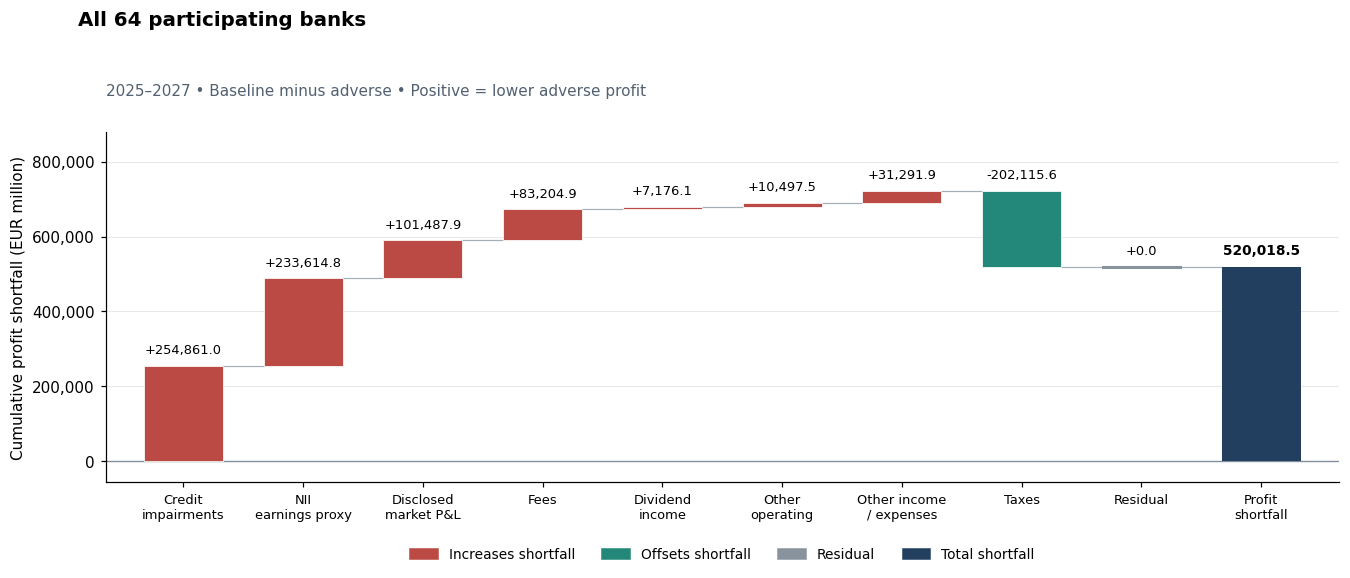

In [11]:
CHART_GROUPS = [
    ('Credit\nimpairments', ['credit']),
    ('NII\nearnings proxy', ['nii']),
    ('Disclosed\nmarket P&L', ['trading','nontrading']),
    ('Fees', ['fees']), ('Dividend\nincome', ['dividends']),
    ('Other\noperating', ['other_operating']),
    ('Other income\n/ expenses', ['other_expenses']),
    ('Taxes', ['tax']), ('Residual', ['residual']),
]
assert sorted(key for _, keys in CHART_GROUPS for key in keys) == sorted(DRIVERS)

def waterfall(row, title):
    values = np.array([sum(float(row[key]) for key in keys) for _, keys in CHART_GROUPS])
    endpoint = float(row['shortfall'])
    if abs(values.sum() - endpoint) > ABS_TOL:
        raise ValueError('Chart components do not reconcile to profit shortfall')
    levels = np.r_[0.0, values.cumsum()]
    fig, ax = plt.subplots(figsize=(12.6, 5.8))
    red, green, blue, grey = '#bb4944', '#238879', '#233f60', '#89939e'
    positions = np.arange(len(values) + 1)
    for i, value in enumerate(values):
        color = grey if i == len(values)-1 else (red if value >= 0 else green)
        ax.bar(i, abs(value), bottom=min(levels[i],levels[i+1]), width=.66,
               color=color, edgecolor='white', linewidth=.5, zorder=3)
        if abs(value) <= ABS_TOL:
            ax.plot([i-.32,i+.32], [levels[i+1],levels[i+1]], color=color, linewidth=2, zorder=4)
        ax.plot([i+.33,i+.67], [levels[i+1],levels[i+1]], color='#a5aeb7', linewidth=.8)
        # Even a tiny floating-point residual is preserved, while its display rounds to zero.
        printed = 0.0 if abs(value) < .05 else value
        ax.annotate(f'{printed:+,.1f}', (i, max(levels[i],levels[i+1])),
                    xytext=(0,6), textcoords='offset points', ha='center', va='bottom', fontsize=8.5)
    ax.bar(len(values), abs(endpoint), bottom=min(0,endpoint), width=.66, color=blue, zorder=3)
    ax.annotate(f'{endpoint:,.1f}', (len(values),max(0,endpoint)), xytext=(0,6),
                textcoords='offset points', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(0,color='#82909e',linewidth=.9)
    ax.set_xticks(positions, [label for label,_ in CHART_GROUPS] + ['Profit\nshortfall'], fontsize=8.5)
    ax.set_ylabel('Cumulative profit shortfall (EUR million)')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.grid(axis='y', color='#e5e9ec',linewidth=.7, zorder=0)
    extremes = np.r_[0, levels, endpoint]
    span = max(np.ptp(extremes),1.0)
    ax.set_ylim(extremes.min()-.08*span,extremes.max()+.22*span)
    ax.set_xlim(-.65,len(values)+.65)
    fig.suptitle('\n'.join(textwrap.wrap(title,95)), x=.075, y=.98, ha='left', fontsize=13, fontweight='bold')
    ax.set_title('2025–2027 • Baseline minus adverse • Positive = lower adverse profit', loc='left',
                 fontsize=10, fontweight='normal', color='#526171', pad=24)
    ax.legend(handles=[Patch(color=red,label='Increases shortfall'),Patch(color=green,label='Offsets shortfall'),
                       Patch(color=grey,label='Residual'),Patch(color=blue,label='Total shortfall')],
              loc='upper center', bbox_to_anchor=(.5,-.15), ncol=4, frameon=False, fontsize=9)
    fig.subplots_adjust(left=.095,right=.985,bottom=.24,top=.79)
    return fig

def bank_explanation(lei):
    row = results.loc[lei]
    text = (f'Cumulative baseline after-tax profit is EUR {row["baseline_profit"]:,.1f}m versus '
            f'EUR {row["adverse_profit"]:,.1f}m under adverse conditions. ')
    if row['shortfall'] > ABS_TOL:
        text += f'The profit shortfall is EUR {row["shortfall"]:,.1f}m. '
    elif row['shortfall'] < -ABS_TOL:
        text += f'Adverse profit exceeds baseline by EUR {-row["shortfall"]:,.1f}m (a negative shortfall). '
    else:
        text += 'The cumulative profit difference is effectively zero. '
    positive = row[COMPONENTS].astype(float).loc[lambda series: series > ABS_TOL].nlargest(3)
    negative = row[COMPONENTS].astype(float).loc[lambda series: series < -ABS_TOL].nsmallest(2)
    if len(positive):
        text += 'The largest disclosed reductions in profit are ' + '; '.join(
            f'{LABEL[key]} (EUR {value:,.1f}m)' for key,value in positive.items()) + '. '
    if len(negative):
        text += 'The largest offsets are ' + '; '.join(
            f'{LABEL[key]} (EUR {-value:,.1f}m)' for key,value in negative.items()) + '. '
    if not len(positive) and not len(negative):
        text += 'All disclosed component differences are effectively zero. '
    text += ('The unexplained residual is below EUR 10. ' if abs(row['residual']) <= ABS_TOL else
             f'The unexplained residual is EUR {row["residual"]:,.4f}m. ')
    text += ('NII is an earnings proxy; operational and CCR default losses remain inside the disclosed '
             'other-income/expense aggregate, so no standalone amounts are attributed to them.')
    return text

report_count = 0
def report_bank(lei):
    global report_count
    if lei not in results.index:
        raise KeyError('Select an LEI from results.index')
    row = results.loc[lei]
    display(HTML(f'<h3 id="bank-{lei}">{html.escape(row["bank_name"])}</h3>'
                 f'<p class="eba-note">{html.escape(row["country_name"])} · LEI {lei} · '
                 f'<a href="{html.escape(BANK_PDF_URLS[lei])}">Official EBA disclosure</a></p>'))
    yearly = annual.xs(lei, level='lei_code')['profit'].unstack('scenario').reindex(PERIODS)
    yearly.columns = ['Baseline profit','Adverse profit']
    yearly['Profit shortfall'] = yearly['Baseline profit'] - yearly['Adverse profit']
    yearly.index = [str(year) for year in YEARS]
    yearly.loc['2025–2027 cumulative'] = yearly.sum()
    show_table(yearly.rename_axis('Period').reset_index(), 'After-tax profit (EUR m)', digits=1)
    table = pd.DataFrame({
        'Driver':[LABEL[key] for key in COMPONENTS],
        'Baseline P&L (EUR m)':baseline_totals.loc[lei,COMPONENTS].to_numpy(),
        'Adverse P&L (EUR m)':adverse_totals.loc[lei,COMPONENTS].to_numpy(),
        'Shortfall contribution (EUR m)':row[COMPONENTS].to_numpy(float),
    })
    table.loc[len(table)] = [LABEL['residual'],baseline_residual.loc[lei],adverse_residual.loc[lei],row['residual']]
    table.loc[len(table)] = ['After-tax profit / total shortfall',row['baseline_profit'],row['adverse_profit'],row['shortfall']]
    table['Share of shortfall (%)'] = (100*table['Shortfall contribution (EUR m)']/row['shortfall']
                                      if abs(row['shortfall']) > ABS_TOL else np.nan)
    show_table(table, 'Cumulative signed P&L and shortfall contributions', digits=2)
    display(HTML('<p>' + html.escape(bank_explanation(lei)) + '</p>'))
    figure = waterfall(row, row['bank_name'])
    if EXPORT_RESULTS:
        OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
        figure.savefig(OUTPUT_DIR/f'{lei}_waterfall.png',bbox_inches='tight')
    display(figure)
    plt.close(figure)
    diagnostic = pd.DataFrame({
        'Supplementary NII component':['Disclosed interest income','Disclosed interest expense (signed)',
                                     'Derived NII adjustment remainder','Total NII'],
        'Shortfall contribution (EUR m)':nii_diagnostic_shortfall.loc[lei,
            ['interest_income','interest_expense','nii_adjustments_remainder','nii']].to_numpy(),
    })
    diagnostic_html = diagnostic.to_html(index=False,classes='eba-table',border=0,float_format=lambda v:f'{v:,.2f}')
    display(HTML('<details><summary>NII accounting detail (already included in NII above)</summary>'
                 + diagnostic_html + '<p class="eba-note">The derived remainder combines caps, HFT and other '
                 'template adjustments. It is not a measured IRRBB component.</p></details>'))
    if row['source_footnote']:
        display(HTML('<p class="eba-note"><strong>EBA bank-specific note:</strong> '
                     + html.escape(row['source_footnote']) + '</p>'))
    if lei == 'NHBDILHZTYCNBV5UYZ31':
        display(Markdown('The linked December 2025 revision concerns STREA only; its P&L agrees with the database.'))
    report_count += 1

display(waterfall(aggregate, 'All 64 participating banks'))
plt.close('all')

## 5. Individual bank reports

All banks are shown below in country/name order. The share column uses the net shortfall as its
denominator: positive components can exceed 100% where other components offset losses, and
negative values indicate offsets. Shares are not shown when the net shortfall is effectively zero.
Rounding may cause displayed component amounts to differ slightly from displayed totals.

In [12]:
links = [f'<li><a href="#bank-{lei}">{html.escape(row["country_code"])} — {html.escape(row["bank_name"])}</a></li>'
         for lei,row in bank_index.iterrows()]
display(HTML('<details><summary>Index of all 64 banks</summary><ul>' + ''.join(links) + '</ul></details>'))

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"3,678.7","-1,218.6","4,897.3"
2026,"3,508.3",353.1,"3,155.3"
2027,"3,304.7",288.3,"3,016.4"
2025–2027 cumulative,"10,491.7",-577.3,"11,069.0"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,959.17","-10,511.59","8,552.42",77.26
NII (earnings proxy),"25,705.97","20,859.45","4,846.52",43.78
Trading P&L (market proxy),41.01,-366.09,407.10,3.68
Non-trading FVPL revaluation,0.00,-134.41,134.41,1.21
Fees and commissions,"9,145.30","7,811.50","1,333.80",12.05
Dividend income,133.30,66.65,66.65,0.60
Other operating P&L (disclosed),137.26,158.03,-20.77,-0.19
Other income/expenses (incl. OR/CCR),"-18,249.62","-18,708.24",458.63,4.14
Taxes (signed P&L),"-4,462.39",247.41,"-4,709.80",-42.55
Unexplained residual,-0.00,-0.00,-0.00,-0.00


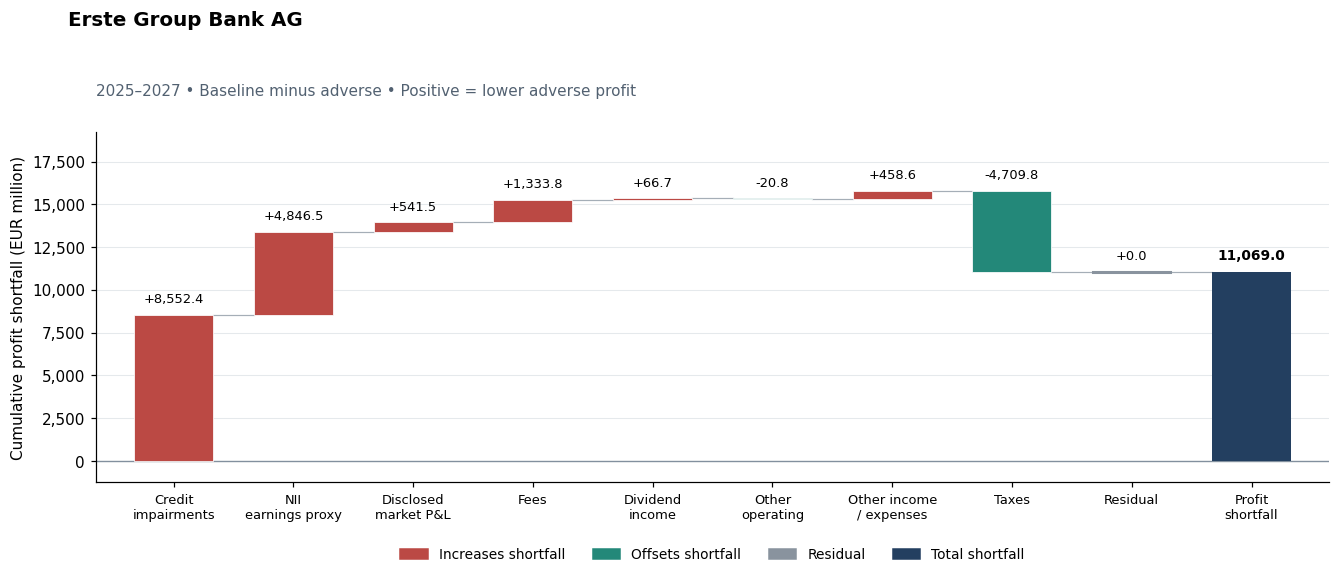

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-6,325.13"
Disclosed interest expense (signed),"9,882.04"
Derived NII adjustment remainder,"1,289.61"
Total NII,"4,846.52"


In [13]:
report_bank('PQOH26KWDF7CG10L6792')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,658.1",-305.7,"2,963.8"
2026,"2,534.0","1,224.7","1,309.3"
2027,"2,426.5",599.3,"1,827.2"
2025–2027 cumulative,"7,618.6","1,518.2","6,100.3"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,406.88","-4,167.31","2,760.42",45.25
NII (earnings proxy),"16,989.96","13,892.61","3,097.35",50.77
Trading P&L (market proxy),0.00,-324.13,324.13,5.31
Non-trading FVPL revaluation,0.00,-39.19,39.19,0.64
Fees and commissions,"7,613.12","6,012.24","1,600.88",26.24
Dividend income,92.85,46.42,46.42,0.76
Other operating P&L (disclosed),622.06,436.77,185.28,3.04
Other income/expenses (incl. OR/CCR),"-13,040.50","-13,701.59",661.09,10.84
Taxes (signed P&L),"-3,252.03",-637.60,"-2,614.43",-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


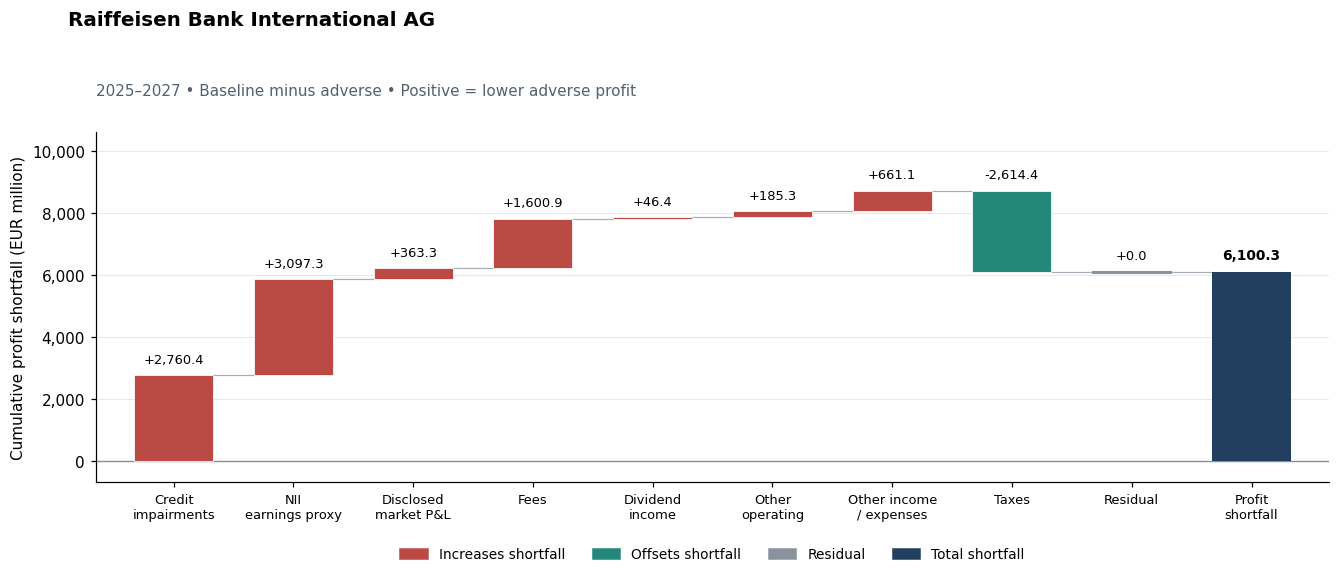

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-3,062.65"
Disclosed interest expense (signed),"5,900.58"
Derived NII adjustment remainder,259.42
Total NII,"3,097.35"


In [14]:
report_bank('9ZHRYM6F437SQJ6OUG95')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,153.5",-576.9,"1,730.4"
2026,"1,084.2",121.3,963.0
2027,880.4,8.1,872.3
2025–2027 cumulative,"3,118.2",-447.5,"3,565.7"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-745.96,"-2,325.23","1,579.27",44.29
NII (earnings proxy),"6,437.72","4,840.47","1,597.25",44.80
Trading P&L (market proxy),71.35,-432.16,503.51,14.12
Non-trading FVPL revaluation,0.00,-20.45,20.45,0.57
Fees and commissions,"1,548.39","1,204.30",344.09,9.65
Dividend income,89.57,44.79,44.79,1.26
Other operating P&L (disclosed),200.10,10.26,189.84,5.32
Other income/expenses (incl. OR/CCR),"-3,598.55","-4,290.60",692.05,19.41
Taxes (signed P&L),-884.43,521.13,"-1,405.56",-39.42
Unexplained residual,-0.00,-0.00,-0.00,-0.00


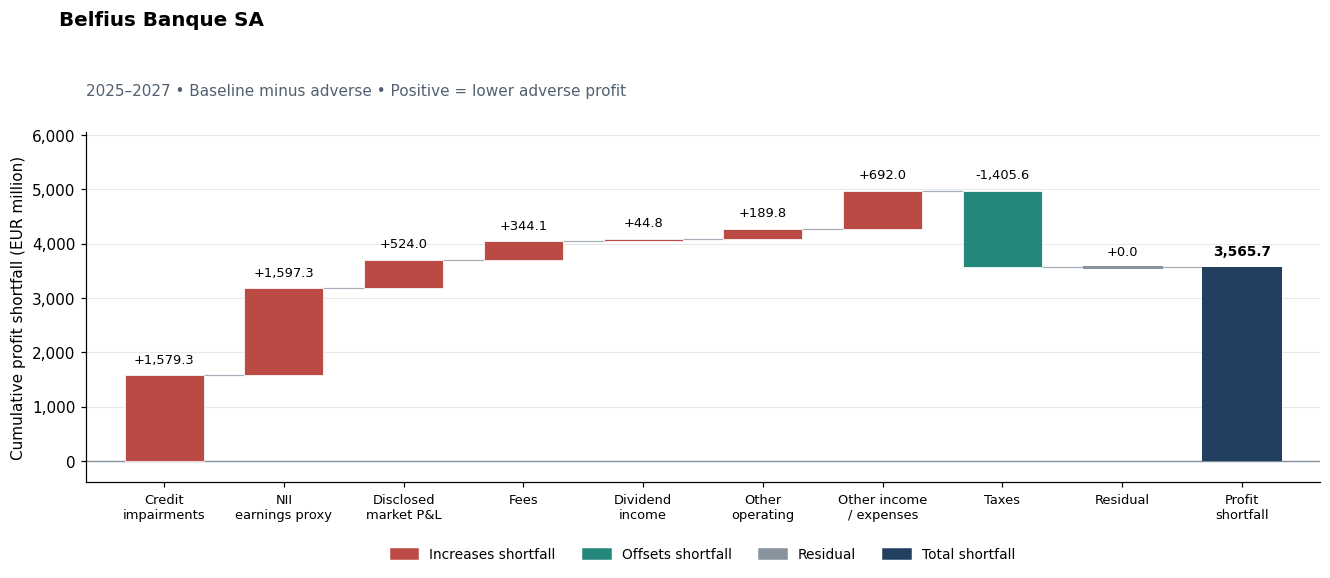

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-3,045.29"
Disclosed interest expense (signed),"4,592.62"
Derived NII adjustment remainder,49.92
Total NII,"1,597.25"


In [15]:
report_bank('A5GWLFH3KM7YV2SFQL84')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,624.5","-1,168.9","3,793.4"
2026,"2,706.6",85.4,"2,621.1"
2027,"2,640.9",457.0,"2,183.9"
2025–2027 cumulative,"7,972.0",-626.5,"8,598.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,151.12","-6,541.67","4,390.55",51.06
NII (earnings proxy),"17,677.61","14,212.19","3,465.42",40.30
Trading P&L (market proxy),787.98,259.12,528.86,6.15
Non-trading FVPL revaluation,0.00,32.61,-32.61,-0.38
Fees and commissions,"7,726.72","6,524.17","1,202.55",13.99
Dividend income,68.09,50.24,17.85,0.21
Other operating P&L (disclosed),450.03,-233.07,683.10,7.94
Other income/expenses (incl. OR/CCR),"-13,256.48","-15,198.61","1,942.13",22.59
Taxes (signed P&L),"-3,330.86",268.50,"-3,599.37",-41.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


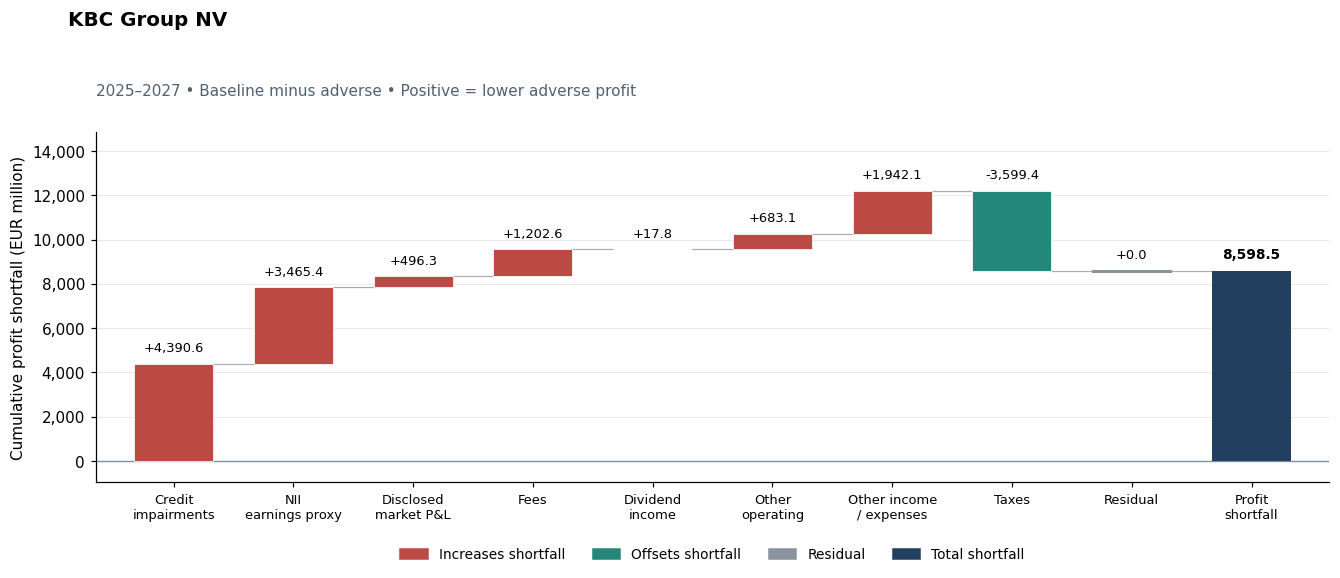

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-6,801.65"
Disclosed interest expense (signed),"10,213.82"
Derived NII adjustment remainder,53.25
Total NII,"3,465.42"


In [16]:
report_bank('213800X3Q9LSAKRUWY91')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,092.7",-721.8,"1,814.5"
2026,921.5,30.9,890.6
2027,869.5,203.1,666.4
2025–2027 cumulative,"2,883.8",-487.8,"3,371.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-800.07,"-2,615.78","1,815.71",53.85
NII (earnings proxy),"8,146.11","6,964.61","1,181.50",35.04
Trading P&L (market proxy),99.99,-953.96,"1,053.95",31.26
Non-trading FVPL revaluation,0.00,509.44,-509.44,-15.11
Fees and commissions,"1,453.57","1,114.40",339.17,10.06
Dividend income,54.44,27.22,27.22,0.81
Other operating P&L (disclosed),468.11,334.06,134.05,3.98
Other income/expenses (incl. OR/CCR),"-5,302.48","-6,076.81",774.33,22.97
Taxes (signed P&L),"-1,235.90",209.05,"-1,444.94",-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


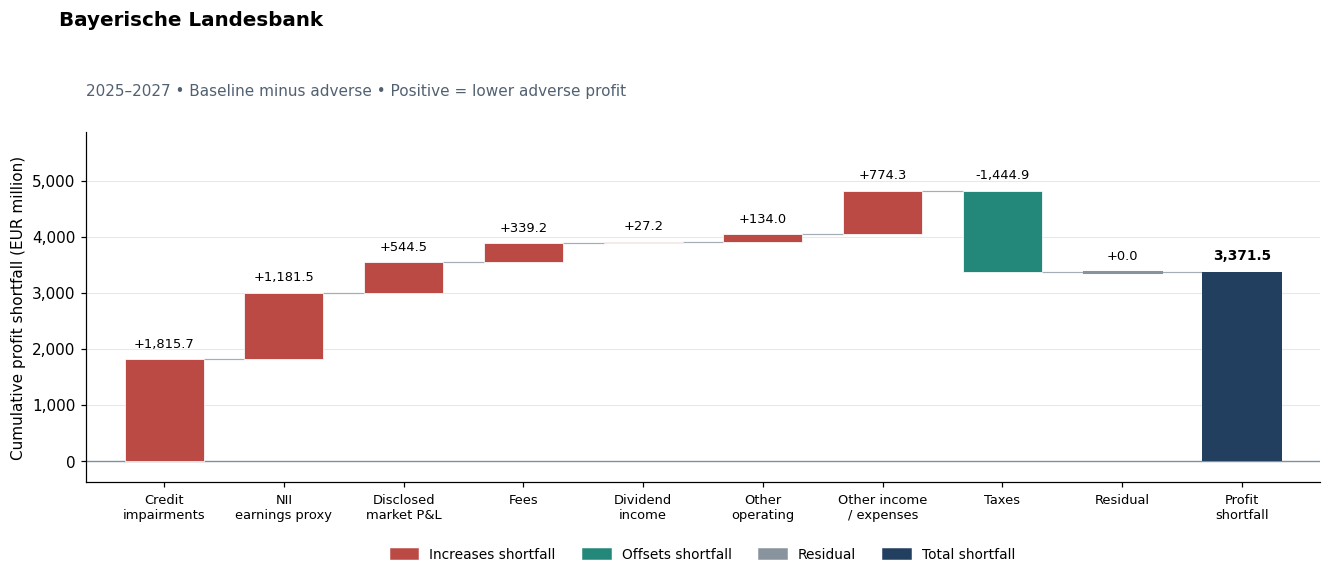

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,954.63"
Disclosed interest expense (signed),"6,136.13"
Derived NII adjustment remainder,0.00
Total NII,"1,181.50"


In [17]:
report_bank('VDYMYTQGZZ6DU0912C88')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,517.2","-2,311.0","4,828.2"
2026,"2,808.3",366.6,"2,441.7"
2027,"2,420.1",560.8,"1,859.3"
2025–2027 cumulative,"7,745.6","-1,383.7","9,129.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,915.28","-4,802.25","2,886.96",31.62
NII (earnings proxy),"20,398.61","15,882.84","4,515.76",49.46
Trading P&L (market proxy),"2,474.78",884.90,"1,589.89",17.42
Non-trading FVPL revaluation,0.00,-357.62,357.62,3.92
Fees and commissions,"10,423.67","8,551.33","1,872.34",20.51
Dividend income,138.88,69.44,69.44,0.76
Other operating P&L (disclosed),693.48,842.25,-148.78,-1.63
Other income/expenses (incl. OR/CCR),"-21,149.05","-23,047.57","1,898.52",20.80
Taxes (signed P&L),"-3,319.53",593.00,"-3,912.53",-42.86
Unexplained residual,-0.00,-0.00,-0.00,-0.00


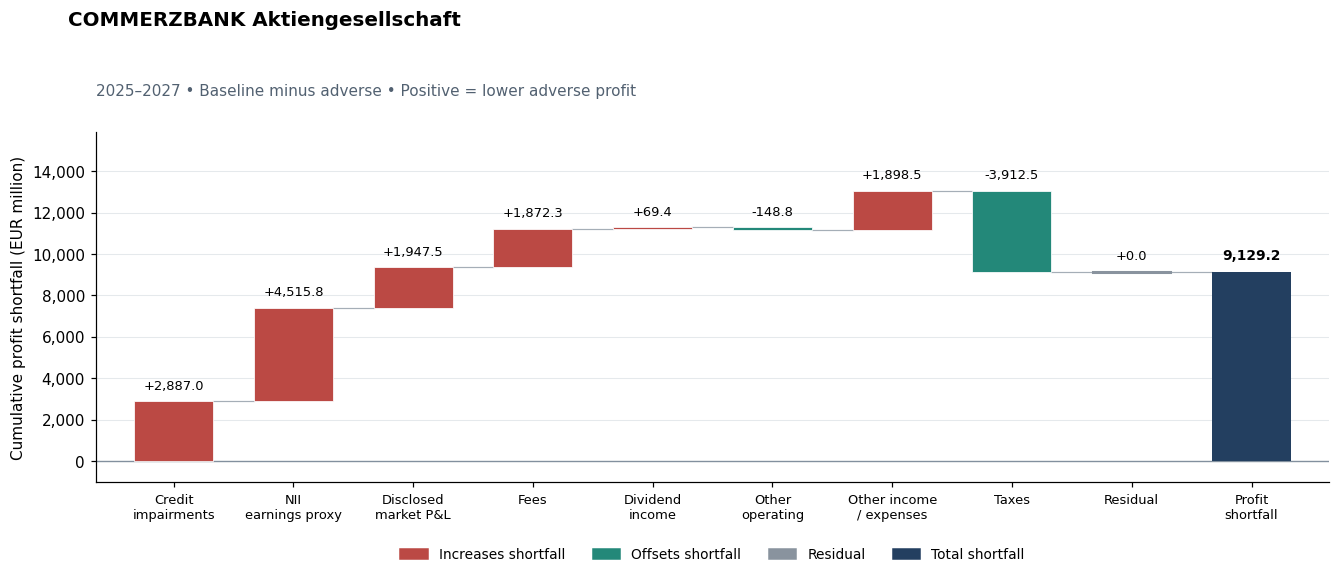

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-12,351.58"
Disclosed interest expense (signed),"16,550.16"
Derived NII adjustment remainder,317.17
Total NII,"4,515.76"


In [18]:
report_bank('851WYGNLUQLFZBSYGB56')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,32.4,-788.3,820.6
2026,31.3,-97.7,129.0
2027,23.6,-88.2,111.8
2025–2027 cumulative,87.3,-974.1,"1,061.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-7.54,-21.37,13.83,1.30
NII (earnings proxy),240.33,73.84,166.49,15.69
Trading P&L (market proxy),112.85,-101.24,214.09,20.17
Non-trading FVPL revaluation,0.00,0.00,0.00,0.00
Fees and commissions,"1,082.02",954.44,127.58,12.02
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),385.55,385.55,-0.00,-0.00
Other income/expenses (incl. OR/CCR),"-1,688.53","-2,265.34",576.81,54.34
Taxes (signed P&L),-37.41,0.00,-37.41,-3.52
Unexplained residual,0.00,-0.00,0.00,0.00


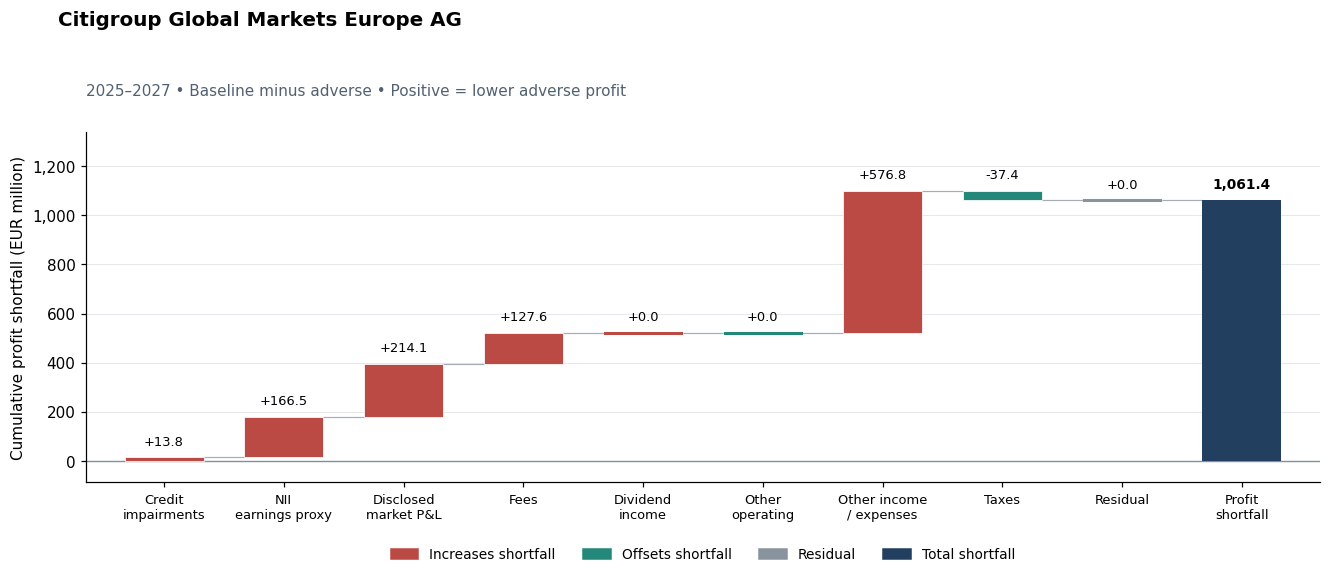

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,-464.99
Disclosed interest expense (signed),328.37
Derived NII adjustment remainder,303.11
Total NII,166.49


In [19]:
report_bank('6TJCK1B7E7UTXP528Y04')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,056.0","-1,410.7","3,466.7"
2026,"1,730.1",489.9,"1,240.2"
2027,"1,736.4",735.1,"1,001.3"
2025–2027 cumulative,"5,522.5",-185.7,"5,708.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,114.24","-3,892.75","2,778.52",48.68
NII (earnings proxy),"9,854.11","9,981.93",-127.82,-2.24
Trading P&L (market proxy),"1,424.61","-1,273.80","2,698.41",47.27
Non-trading FVPL revaluation,0.00,531.71,-531.71,-9.31
Fees and commissions,"9,436.77","7,798.77","1,638.00",28.70
Dividend income,151.20,113.40,37.80,0.66
Other operating P&L (disclosed),935.83,995.40,-59.56,-1.04
Other income/expenses (incl. OR/CCR),"-12,799.00","-14,519.96","1,720.96",30.15
Taxes (signed P&L),"-2,366.79",79.59,"-2,446.38",-42.86
Unexplained residual,-0.00,-0.00,0.00,0.00


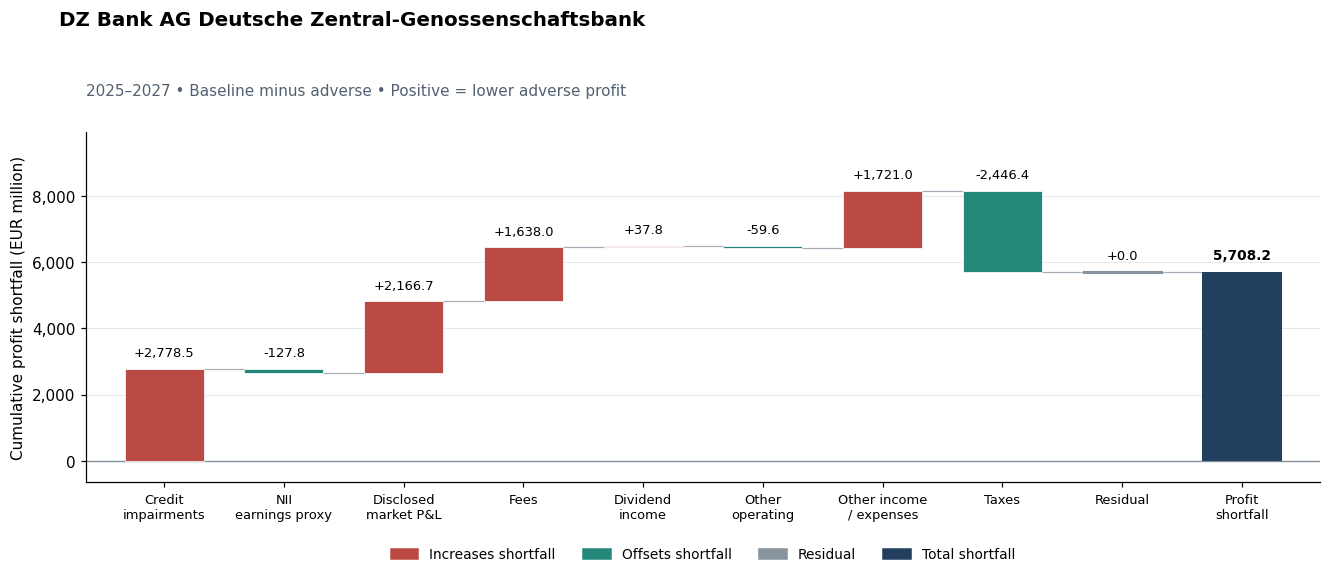

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-13,106.95"
Disclosed interest expense (signed),"12,906.86"
Derived NII adjustment remainder,72.28
Total NII,-127.82


In [20]:
report_bank('529900HNOAA1KXQJUQ27')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"4,005.0","-10,821.7","14,826.7"
2026,"5,211.1","1,488.1","3,723.1"
2027,"4,345.6","1,728.6","2,617.0"
2025–2027 cumulative,"13,561.7","-7,605.1","21,166.8"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-7,964.11","-14,142.73","6,178.62",29.19
NII (earnings proxy),"47,457.57","33,714.03","13,743.54",64.93
Trading P&L (market proxy),"13,174.38","11,060.88","2,113.50",9.98
Non-trading FVPL revaluation,0.00,-716.56,716.56,3.39
Fees and commissions,"28,469.64","24,001.49","4,468.15",21.11
Dividend income,279.03,139.52,139.52,0.66
Other operating P&L (disclosed),627.12,53.68,573.44,2.71
Other income/expenses (incl. OR/CCR),"-62,694.62","-60,336.85","-2,357.77",-11.14
Taxes (signed P&L),"-5,787.29","-1,378.55","-4,408.73",-20.83
Unexplained residual,-0.00,-0.00,0.00,0.00


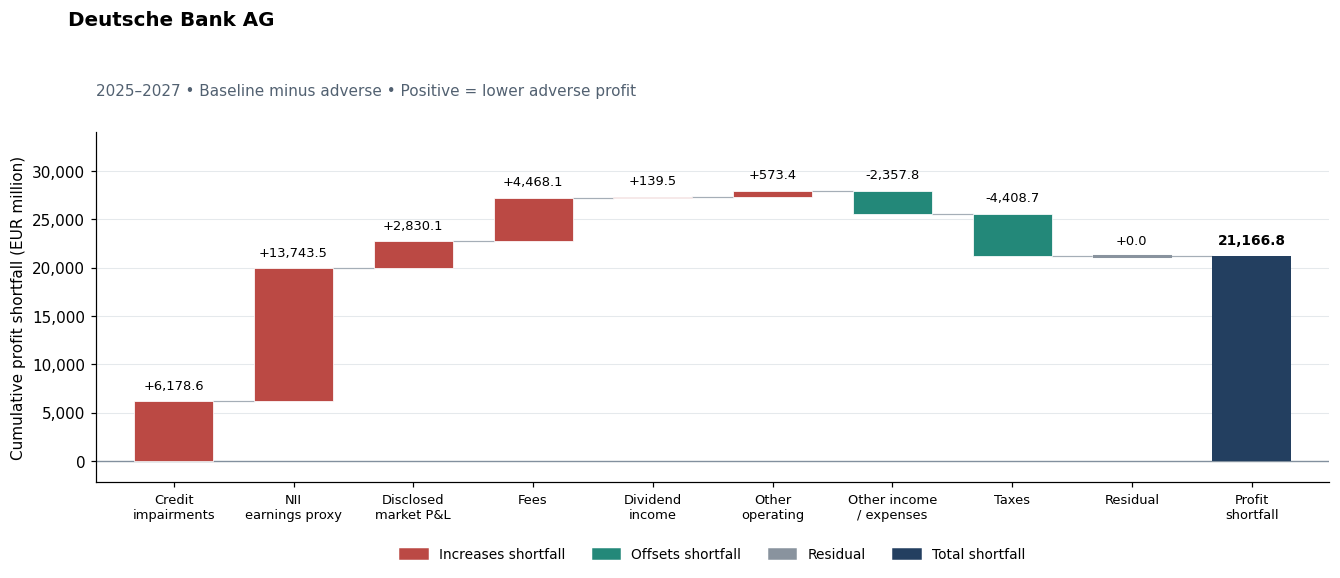

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-24,277.54"
Disclosed interest expense (signed),"37,096.55"
Derived NII adjustment remainder,924.53
Total NII,"13,743.54"


In [21]:
report_bank('7LTWFZYICNSX8D621K86')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,146.8,"-1,922.9","2,069.7"
2026,93.4,31.3,62.1
2027,87.7,33.0,54.7
2025–2027 cumulative,327.8,"-1,858.5","2,186.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-91.62,-412.70,321.08,14.69
NII (earnings proxy),-422.83,-384.16,-38.67,-1.77
Trading P&L (market proxy),"2,913.73","2,141.60",772.13,35.32
Non-trading FVPL revaluation,0.00,27.76,-27.76,-1.27
Fees and commissions,"1,114.86","1,002.73",112.14,5.13
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),0.00,0.05,-0.05,-0.00
Other income/expenses (incl. OR/CCR),"-3,045.82","-4,206.24","1,160.42",53.08
Taxes (signed P&L),-140.50,-27.58,-112.92,-5.16
Unexplained residual,-0.00,-0.00,0.00,0.00


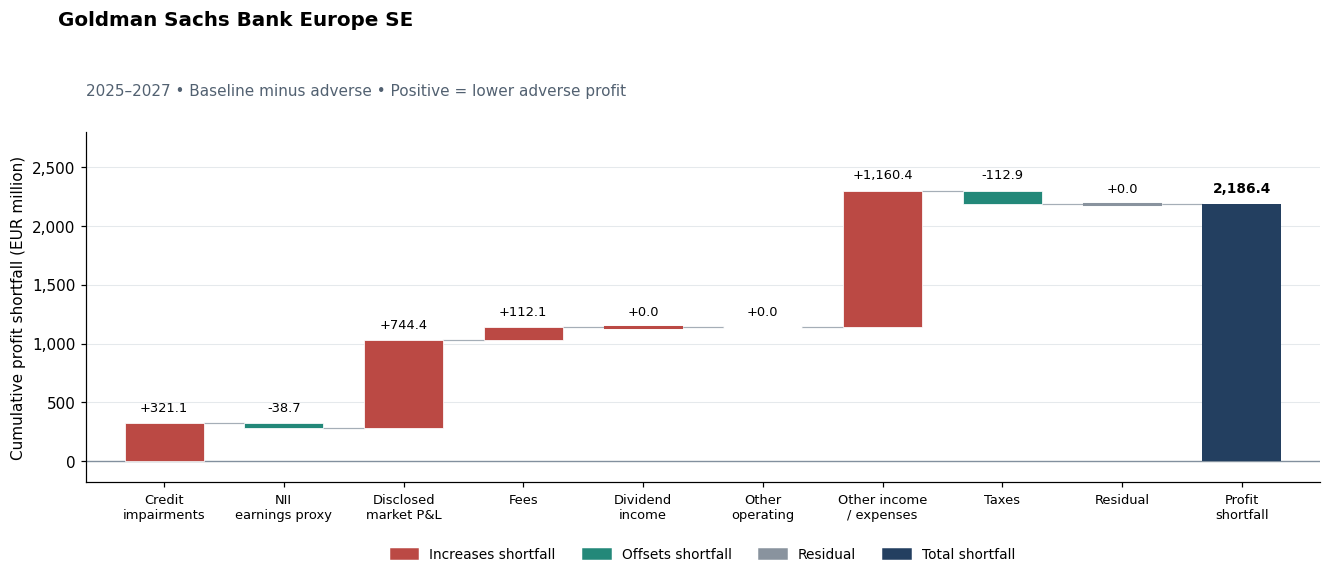

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,520.11"
Disclosed interest expense (signed),"2,351.42"
Derived NII adjustment remainder,130.02
Total NII,-38.67


In [22]:
report_bank('8IBZUGJ7JPLH368JE346')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,472.9","-2,269.6","3,742.5"
2026,"1,443.7",-127.0,"1,570.7"
2027,"1,298.3",-213.4,"1,511.8"
2025–2027 cumulative,"4,214.9","-2,610.0","6,825.0"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-5.75,-396.74,390.99,5.73
NII (earnings proxy),"4,638.17","1,377.45","3,260.72",47.78
Trading P&L (market proxy),"3,566.35","1,023.22","2,543.13",37.26
Non-trading FVPL revaluation,0.00,152.59,-152.59,-2.24
Fees and commissions,"8,329.82","6,873.54","1,456.28",21.34
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),-32.40,-33.48,1.08,0.02
Other income/expenses (incl. OR/CCR),"-10,474.86","-12,725.17","2,250.31",32.97
Taxes (signed P&L),"-1,806.40","1,118.58","-2,924.98",-42.86
Unexplained residual,0.00,0.00,0.00,0.00


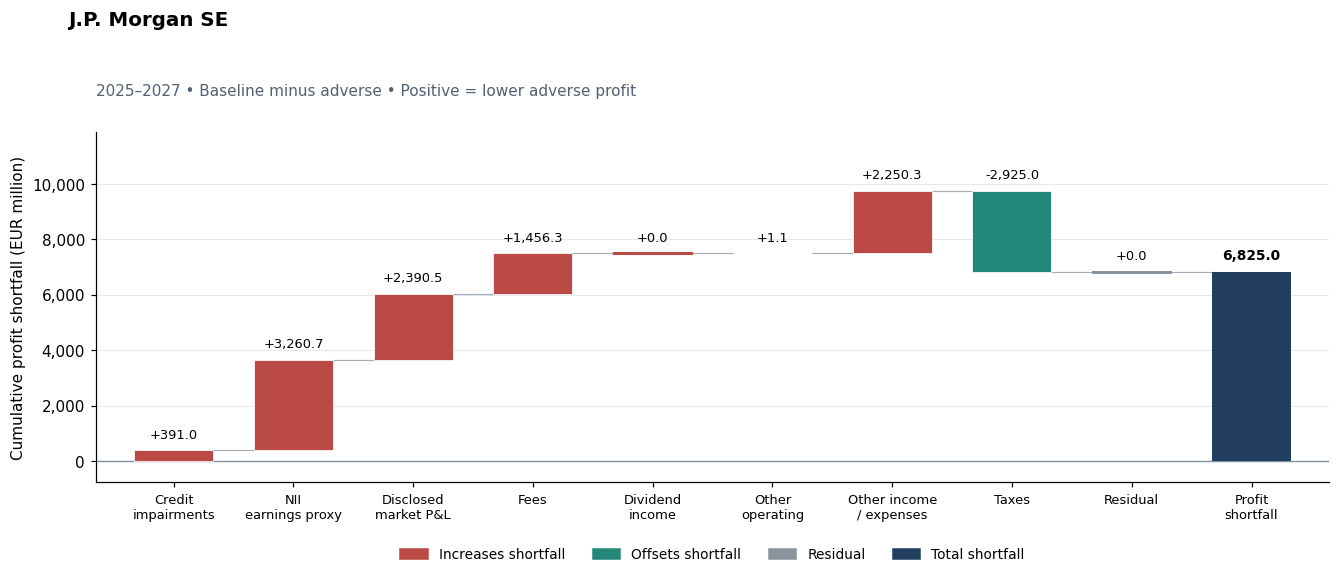

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-7,190.67"
Disclosed interest expense (signed),"9,847.30"
Derived NII adjustment remainder,604.09
Total NII,"3,260.72"


In [23]:
report_bank('549300ZK53CNGEEI6A29')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,548.4,"-1,860.9","2,409.2"
2026,142.6,-880.5,"1,023.1"
2027,110.5,-979.2,"1,089.7"
2025–2027 cumulative,801.5,"-3,720.5","4,522.0"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-287.35,"-3,050.52","2,763.17",61.10
NII (earnings proxy),"6,811.15","4,586.26","2,224.89",49.20
Trading P&L (market proxy),857.40,433.60,423.80,9.37
Non-trading FVPL revaluation,0.00,1.22,-1.22,-0.03
Fees and commissions,"1,618.33","1,258.18",360.15,7.96
Dividend income,68.68,47.63,21.05,0.47
Other operating P&L (disclosed),-62.26,-182.80,120.55,2.67
Other income/expenses (incl. OR/CCR),"-7,860.95","-8,337.11",476.17,10.53
Taxes (signed P&L),-343.50,"1,523.04","-1,866.54",-41.28
Unexplained residual,-0.00,0.00,-0.00,-0.00


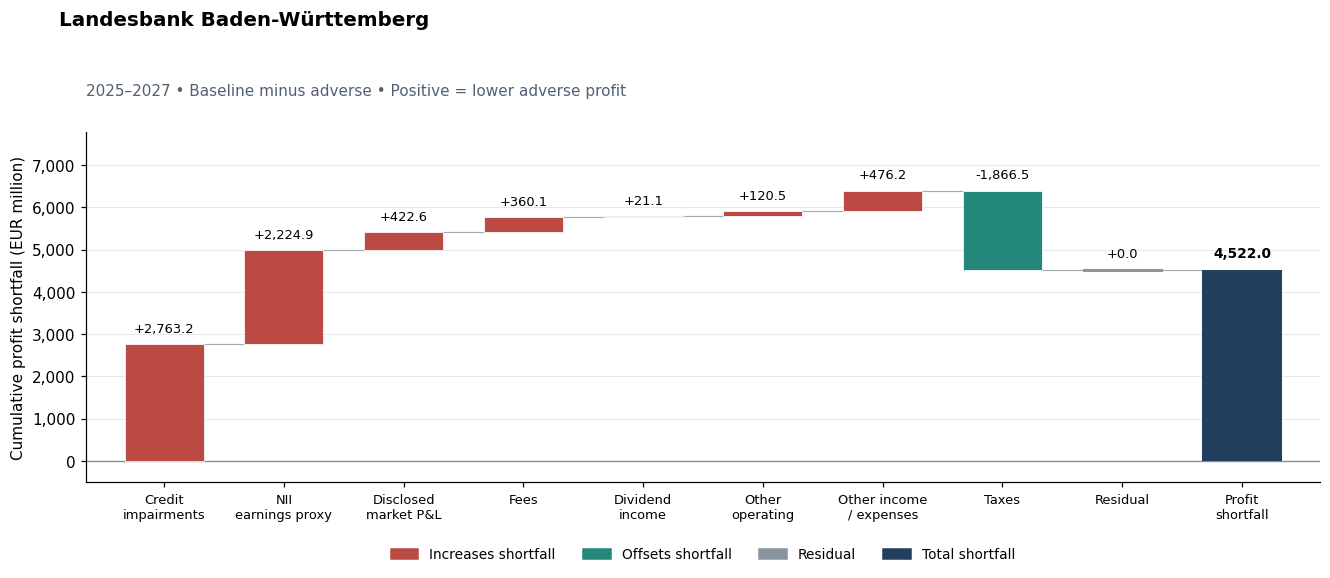

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-7,787.14"
Disclosed interest expense (signed),"10,012.03"
Derived NII adjustment remainder,-0.00
Total NII,"2,224.89"


In [24]:
report_bank('B81CK4ESI35472RHJ606')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,333.1,"-1,631.6","1,964.7"
2026,528.3,98.0,430.3
2027,395.2,90.6,304.6
2025–2027 cumulative,"1,256.6","-1,443.1","2,699.7"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-799.80,"-2,488.54","1,688.73",62.55
NII (earnings proxy),"5,465.03","5,307.53",157.50,5.83
Trading P&L (market proxy),17.83,"-1,033.29","1,051.12",38.94
Non-trading FVPL revaluation,0.00,357.30,-357.30,-13.24
Fees and commissions,"1,553.08","1,207.95",345.13,12.78
Dividend income,266.55,214.60,51.95,1.92
Other operating P&L (disclosed),403.54,368.26,35.27,1.31
Other income/expenses (incl. OR/CCR),"-5,111.08","-5,353.42",242.34,8.98
Taxes (signed P&L),-538.54,-23.47,-515.07,-19.08
Unexplained residual,-0.00,0.00,-0.00,-0.00


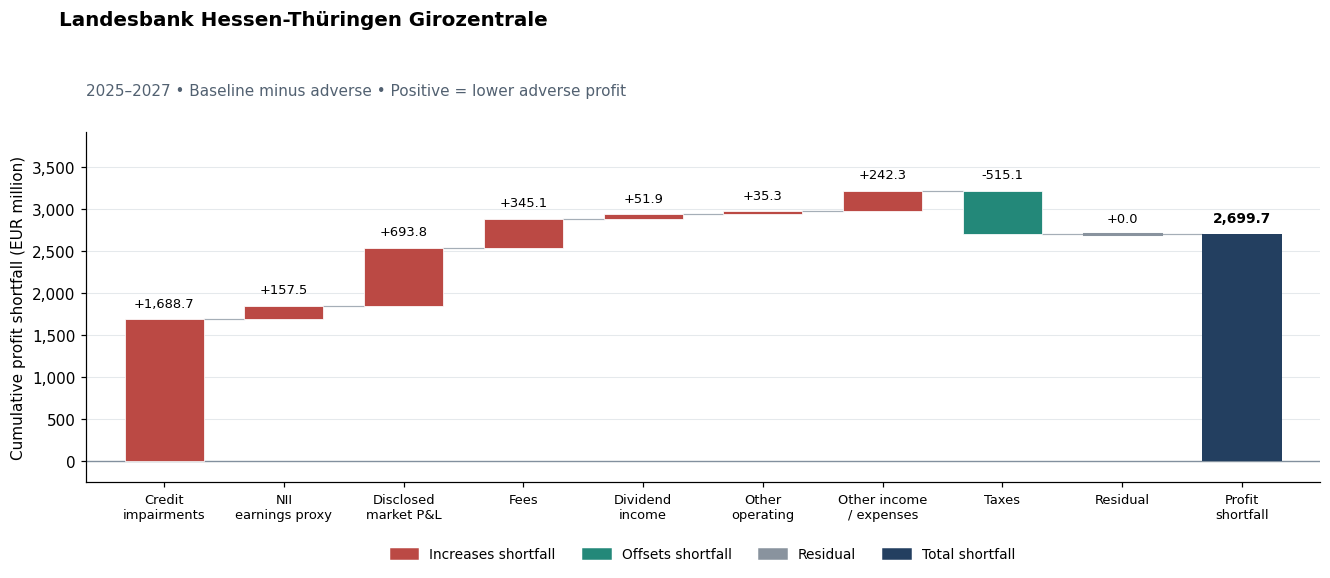

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-6,181.26"
Disclosed interest expense (signed),"6,333.51"
Derived NII adjustment remainder,5.25
Total NII,157.50


In [25]:
report_bank('DIZES5CFO5K3I5R58746')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,74.9,"-1,176.2","1,251.1"
2026,49.2,-50.6,99.8
2027,-4.3,-45.6,41.3
2025–2027 cumulative,119.8,"-1,272.4","1,392.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-17.43,-49.90,32.48,2.33
NII (earnings proxy),496.57,291.89,204.68,14.70
Trading P&L (market proxy),832.42,269.57,562.86,40.43
Non-trading FVPL revaluation,0.00,1.65,-1.65,-0.12
Fees and commissions,"1,339.53","1,025.58",313.95,22.55
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),43.68,38.64,5.04,0.36
Other income/expenses (incl. OR/CCR),"-2,522.30","-3,395.19",872.89,62.70
Taxes (signed P&L),-52.70,545.33,-598.03,-42.96
Unexplained residual,0.00,0.00,-0.00,-0.00


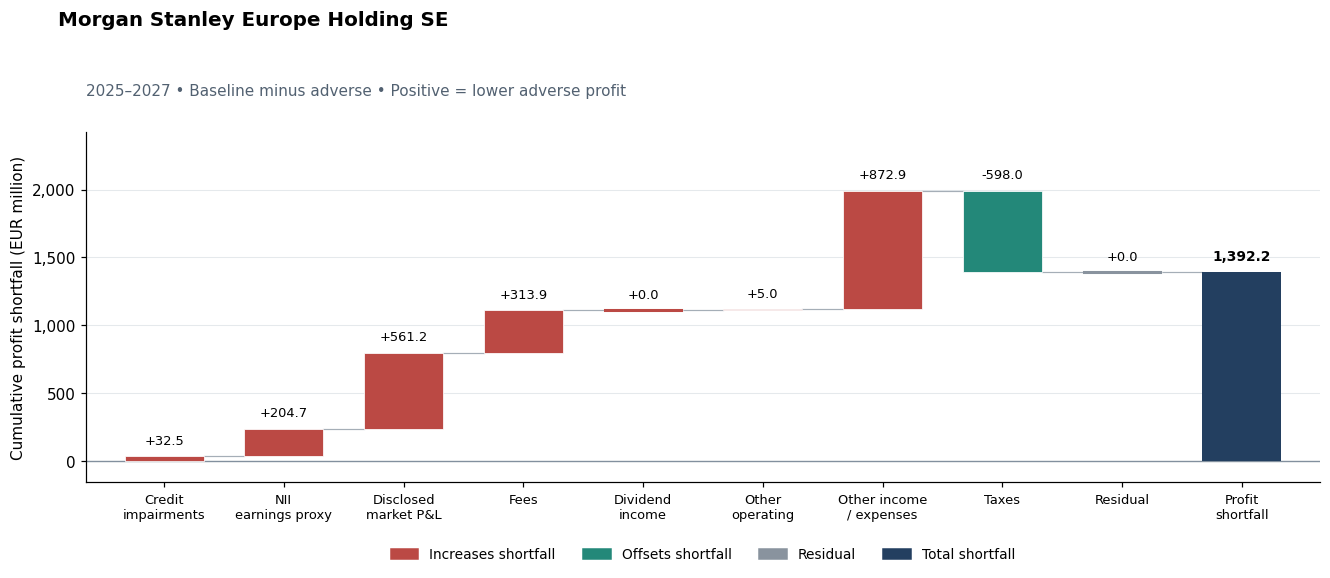

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,586.45"
Disclosed interest expense (signed),"4,050.97"
Derived NII adjustment remainder,740.16
Total NII,204.68


In [26]:
report_bank('549300C9KPZR0VZ16R05')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,336.5,-310.9,647.4
2026,473.9,-36.0,509.9
2027,463.2,-17.0,480.2
2025–2027 cumulative,"1,273.6",-363.9,"1,637.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-362.06,"-1,434.19","1,072.13",65.47
NII (earnings proxy),"4,189.66","3,387.85",801.81,48.97
Trading P&L (market proxy),-259.34,-478.02,218.68,13.35
Non-trading FVPL revaluation,0.00,476.75,-476.75,-29.12
Fees and commissions,675.58,525.45,150.13,9.17
Dividend income,81.84,40.92,40.92,2.50
Other operating P&L (disclosed),-31.02,-44.55,13.53,0.83
Other income/expenses (incl. OR/CCR),"-2,757.17","-2,994.02",236.86,14.46
Taxes (signed P&L),-263.87,155.94,-419.82,-25.64
Unexplained residual,0.00,0.00,0.00,0.00


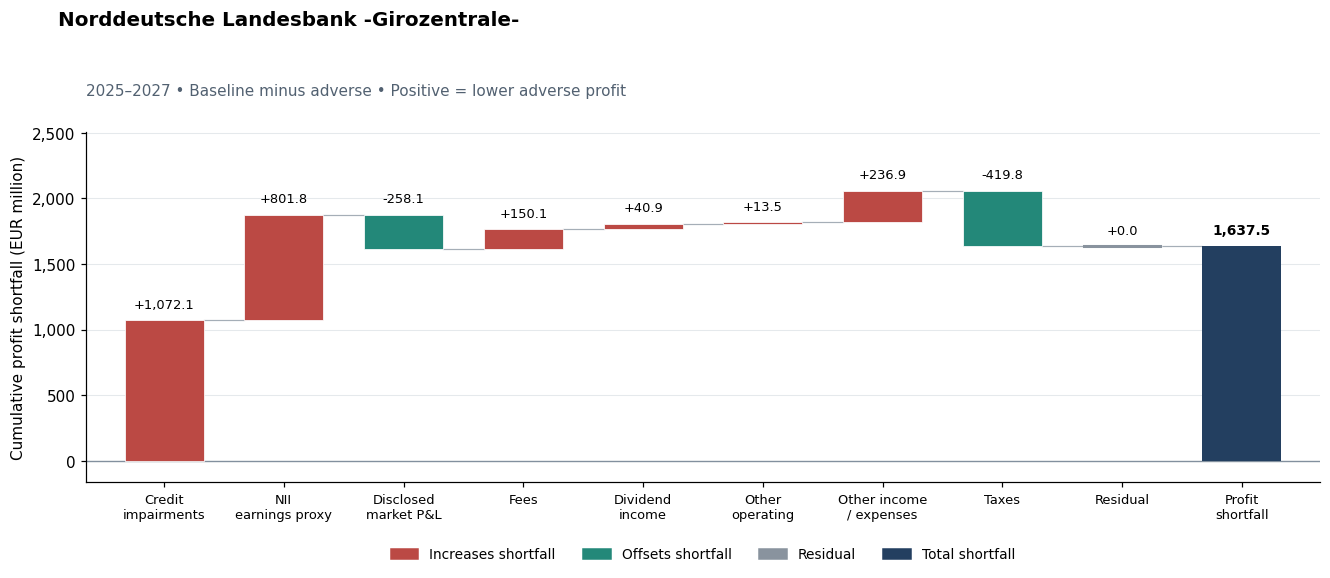

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-5,608.06"
Disclosed interest expense (signed),"6,139.38"
Derived NII adjustment remainder,270.50
Total NII,801.81


In [27]:
report_bank('DSNHHQ2B9X5N6OUJ1236')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,108.3","-2,615.0","4,723.3"
2026,"2,920.6",766.7,"2,153.9"
2027,"2,806.1",883.0,"1,923.1"
2025–2027 cumulative,"7,834.9",-965.4,"8,800.3"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,427.95","-7,324.19","4,896.23",55.64
NII (earnings proxy),"8,861.50","6,500.40","2,361.10",26.83
Trading P&L (market proxy),0.00,-15.90,15.90,0.18
Non-trading FVPL revaluation,0.00,0.00,0.00,0.00
Fees and commissions,"1,552.46","1,209.05",343.41,3.90
Dividend income,0.26,0.00,0.26,0.00
Other operating P&L (disclosed),"11,091.96","7,632.64","3,459.32",39.31
Other income/expenses (incl. OR/CCR),"-7,885.47","-9,381.07","1,495.61",16.99
Taxes (signed P&L),"-3,357.83",413.72,"-3,771.55",-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


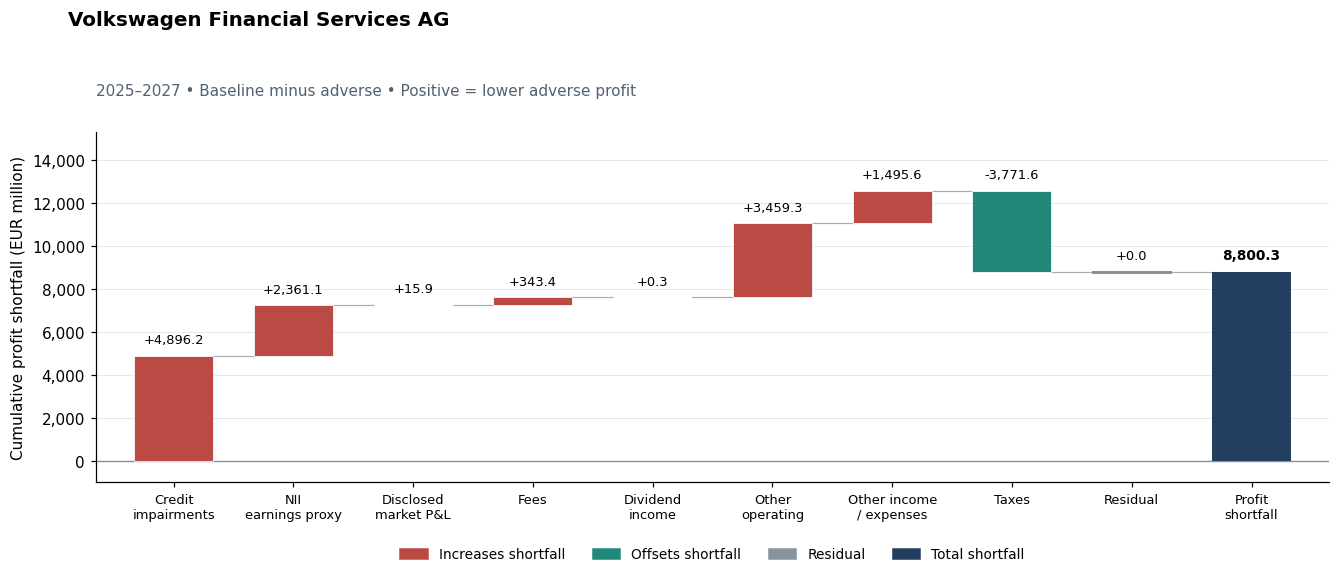

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,492.19"
Disclosed interest expense (signed),"4,422.35"
Derived NII adjustment remainder,430.94
Total NII,"2,361.10"


In [28]:
report_bank('529900SSGT49ZZSWYE62')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"3,394.9","-1,778.6","5,173.5"
2026,"2,296.1",320.4,"1,975.7"
2027,"2,092.3",428.1,"1,664.2"
2025–2027 cumulative,"7,783.3","-1,030.1","8,813.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),702.38,"-6,893.99","7,596.37",86.19
NII (earnings proxy),"13,724.03","12,323.93","1,400.10",15.89
Trading P&L (market proxy),"1,498.45",444.57,"1,053.88",11.96
Non-trading FVPL revaluation,0.00,-102.34,102.34,1.16
Fees and commissions,"5,453.96","4,197.00","1,256.97",14.26
Dividend income,164.88,123.66,41.22,0.47
Other operating P&L (disclosed),319.98,316.75,3.23,0.04
Other income/expenses (incl. OR/CCR),"-10,743.49","-11,883.39","1,139.91",12.93
Taxes (signed P&L),"-3,336.90",443.66,"-3,780.56",-42.90
Unexplained residual,0.00,0.00,-0.00,-0.00


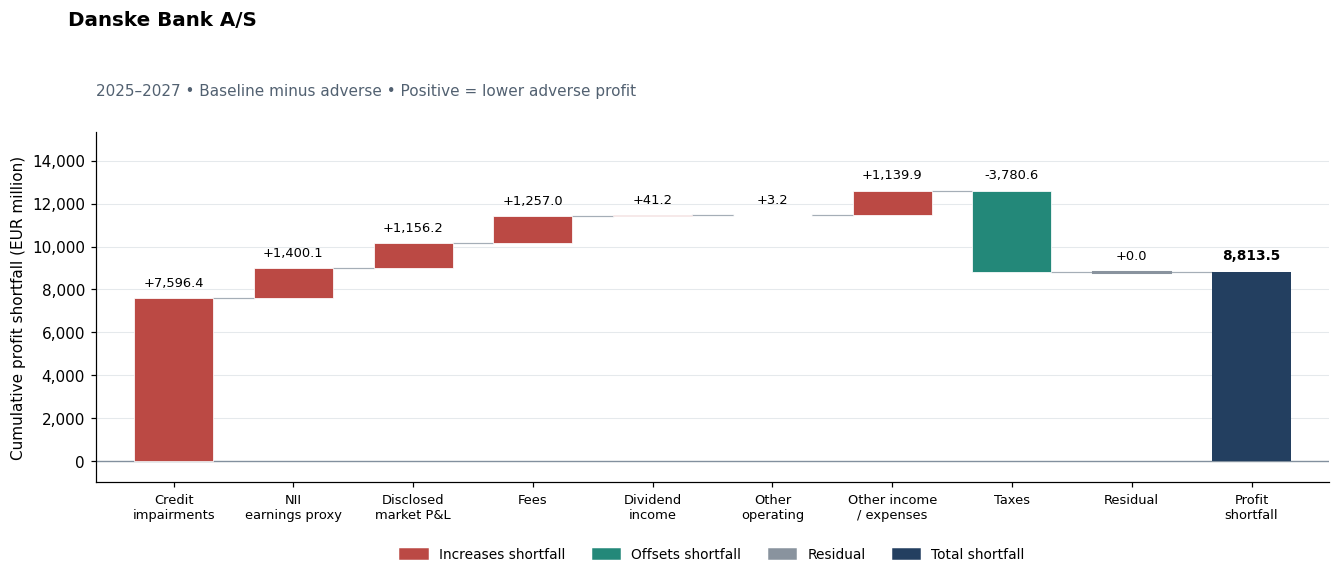

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,840.25"
Disclosed interest expense (signed),"6,240.35"
Derived NII adjustment remainder,0.00
Total NII,"1,400.10"


In [29]:
report_bank('MAES062Z21O4RZ2U7M96')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,196.3,-641.4,837.6
2026,296.3,-88.4,384.8
2027,258.2,-36.5,294.7
2025–2027 cumulative,750.7,-766.3,"1,517.0"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-835.02,"-1,991.14","1,156.12",76.21
NII (earnings proxy),"3,146.11","3,100.24",45.87,3.02
Trading P&L (market proxy),244.35,-66.70,311.04,20.50
Non-trading FVPL revaluation,0.00,-280.80,280.80,18.51
Fees and commissions,992.67,770.37,222.31,14.65
Dividend income,34.75,32.11,2.63,0.17
Other operating P&L (disclosed),300.57,274.43,26.14,1.72
Other income/expenses (incl. OR/CCR),"-2,811.02","-2,963.24",152.22,10.03
Taxes (signed P&L),-321.66,358.43,-680.10,-44.83
Unexplained residual,0.00,0.00,0.00,0.00


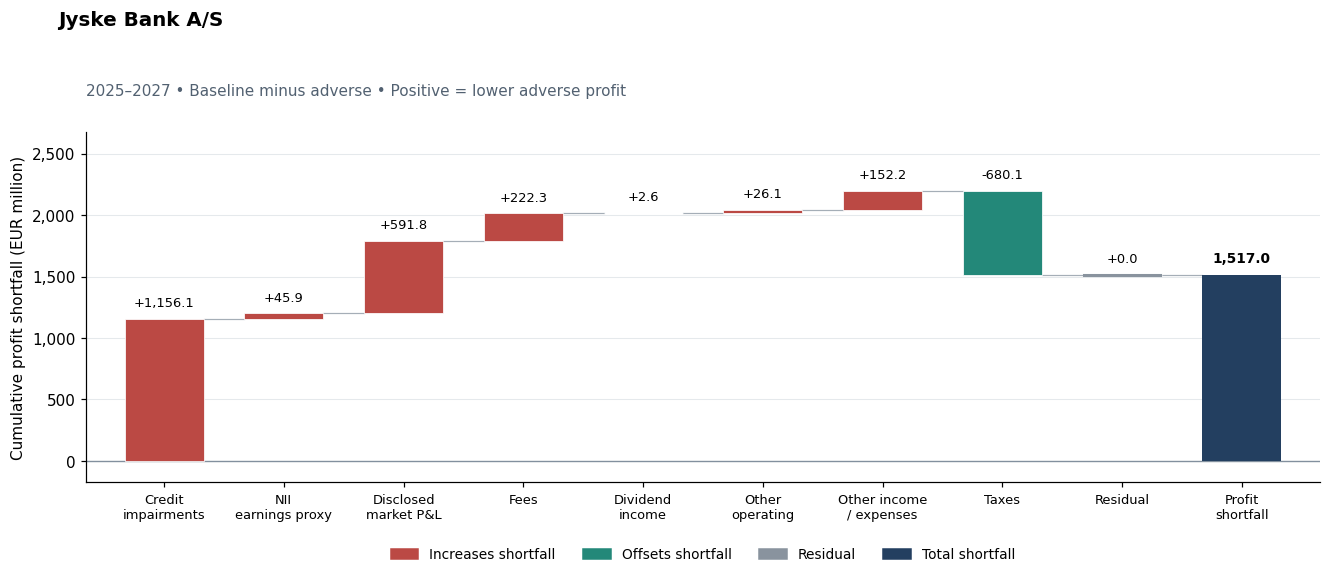

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,133.51"
Disclosed interest expense (signed),"1,179.38"
Derived NII adjustment remainder,0.00
Total NII,45.87


In [30]:
report_bank('3M5E1GQGKL17HI6CPN30')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,190.5",-965.1,"2,155.6"
2026,"1,213.1",72.2,"1,140.9"
2027,"1,177.2",473.1,704.0
2025–2027 cumulative,"3,580.7",-419.8,"4,000.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-533.79,"-3,629.07","3,095.28",77.37
NII (earnings proxy),"5,916.41","5,366.67",549.74,13.74
Trading P&L (market proxy),"1,219.24",92.19,"1,127.04",28.17
Non-trading FVPL revaluation,0.00,-800.29,800.29,20.00
Fees and commissions,110.57,86.00,24.57,0.61
Dividend income,212.73,159.55,53.18,1.33
Other operating P&L (disclosed),731.29,731.29,0.00,0.00
Other income/expenses (incl. OR/CCR),"-2,838.14","-2,903.04",64.90,1.62
Taxes (signed P&L),"-1,237.59",476.91,"-1,714.50",-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


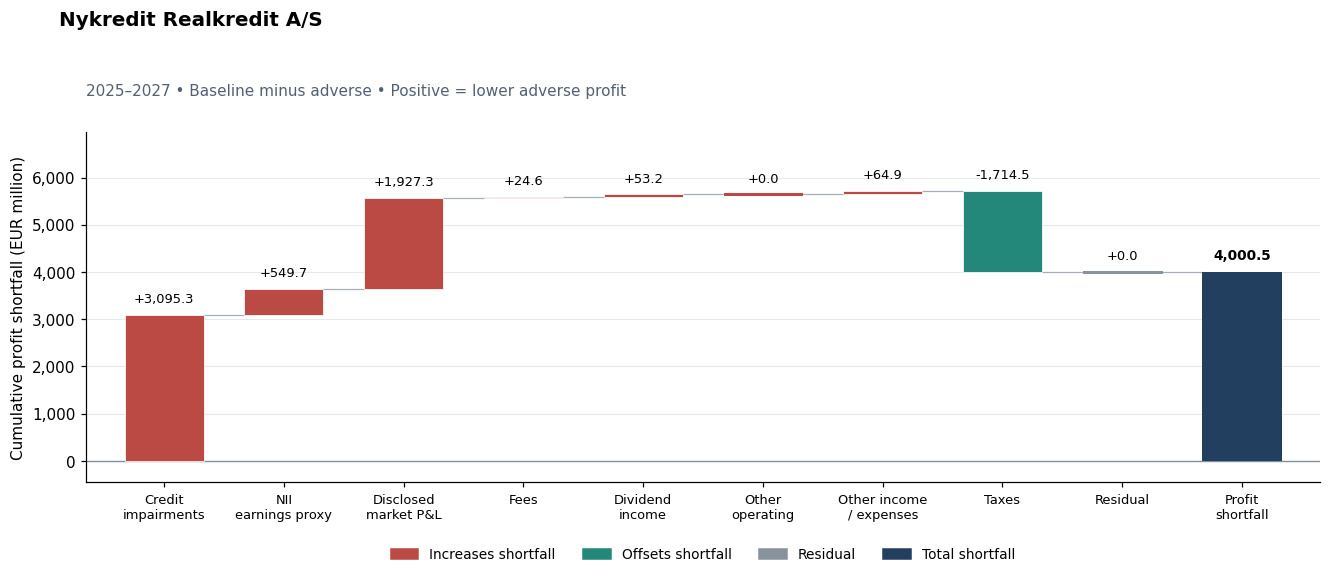

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,-824.66
Disclosed interest expense (signed),"1,226.06"
Derived NII adjustment remainder,148.33
Total NII,549.74


In [31]:
report_bank('LIU16F6VZJSD6UKHD557')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"7,051.6","-2,697.2","9,748.9"
2026,"8,484.2","1,145.5","7,338.7"
2027,"7,550.5","1,453.4","6,097.1"
2025–2027 cumulative,"23,086.3",-98.3,"23,184.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-22,707.54","-35,594.37","12,886.83",55.58
NII (earnings proxy),"78,154.17","65,472.54","12,681.63",54.70
Trading P&L (market proxy),"4,153.28",-910.59,"5,063.87",21.84
Non-trading FVPL revaluation,0.00,-749.86,749.86,3.23
Fees and commissions,"22,412.34","17,678.19","4,734.14",20.42
Dividend income,358.92,179.46,179.46,0.77
Other operating P&L (disclosed),"-5,091.31","-3,885.04","-1,206.28",-5.20
Other income/expenses (incl. OR/CCR),"-44,299.46","-42,330.80","-1,968.65",-8.49
Taxes (signed P&L),"-9,894.12",42.14,"-9,936.26",-42.86
Unexplained residual,-0.00,-0.00,-0.00,-0.00


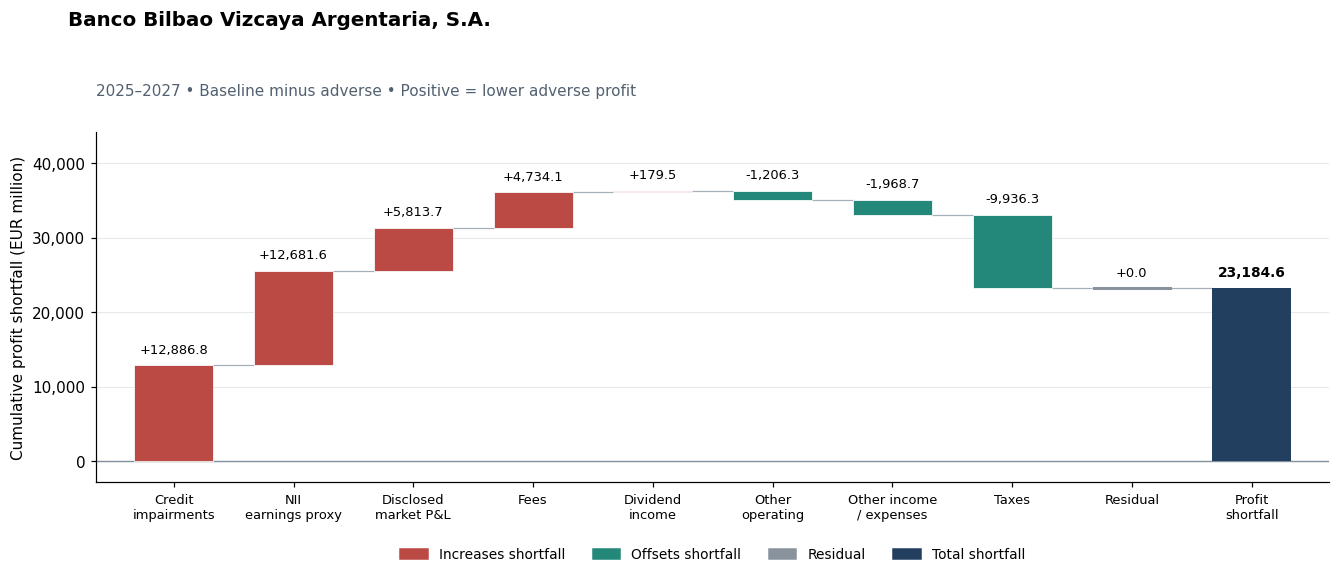

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,599.34"
Disclosed interest expense (signed),"15,372.71"
Derived NII adjustment remainder,"1,908.26"
Total NII,"12,681.63"


In [32]:
report_bank('K8MS7FD7N5Z2WQ51AZ71')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"16,550.1","-3,501.8","20,051.9"
2026,"19,685.7","7,866.9","11,818.8"
2027,"17,937.4","6,404.0","11,533.5"
2025–2027 cumulative,"54,173.3","10,769.0","43,404.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-25,014.18","-44,851.58","19,837.40",45.70
NII (earnings proxy),"157,004.90","119,368.10","37,636.80",86.71
Trading P&L (market proxy),"7,094.40","3,874.28","3,220.12",7.42
Non-trading FVPL revaluation,0.00,"-1,761.35","1,761.35",4.06
Fees and commissions,"37,621.76","30,299.12","7,322.64",16.87
Dividend income,"2,114.86","1,602.54",512.32,1.18
Other operating P&L (disclosed),"-2,480.79","-1,527.04",-953.75,-2.20
Other income/expenses (incl. OR/CCR),"-98,910.01","-91,579.15","-7,330.87",-16.89
Taxes (signed P&L),"-23,257.68","-4,655.88","-18,601.80",-42.86
Unexplained residual,0.00,0.00,-0.00,-0.00


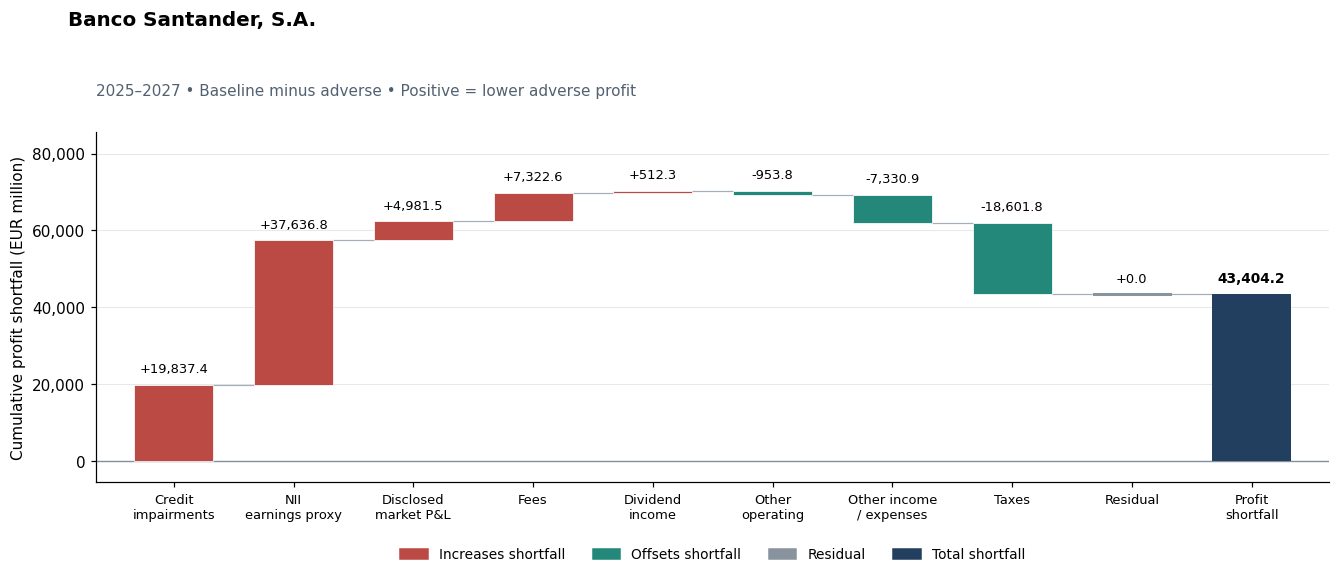

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-21,921.61"
Disclosed interest expense (signed),"49,763.15"
Derived NII adjustment remainder,"9,795.25"
Total NII,"37,636.80"


In [33]:
report_bank('5493006QMFDDMYWIAM13')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,748.4",-972.6,"2,721.1"
2026,"1,823.9",684.6,"1,139.3"
2027,"1,740.9",794.3,946.5
2025–2027 cumulative,"5,313.2",506.3,"4,806.9"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,755.56","-4,493.49","2,737.93",56.96
NII (earnings proxy),"14,744.16","12,383.18","2,360.97",49.12
Trading P&L (market proxy),139.94,-43.36,183.30,3.81
Non-trading FVPL revaluation,0.00,-49.27,49.27,1.02
Fees and commissions,"3,836.62","3,049.60",787.02,16.37
Dividend income,9.58,9.58,0.00,0.00
Other operating P&L (disclosed),-98.00,-134.62,36.62,0.76
Other income/expenses (incl. OR/CCR),"-9,467.45","-10,143.73",676.28,14.07
Taxes (signed P&L),"-2,096.06",-71.59,"-2,024.47",-42.12
Unexplained residual,-0.00,-0.00,-0.00,-0.00


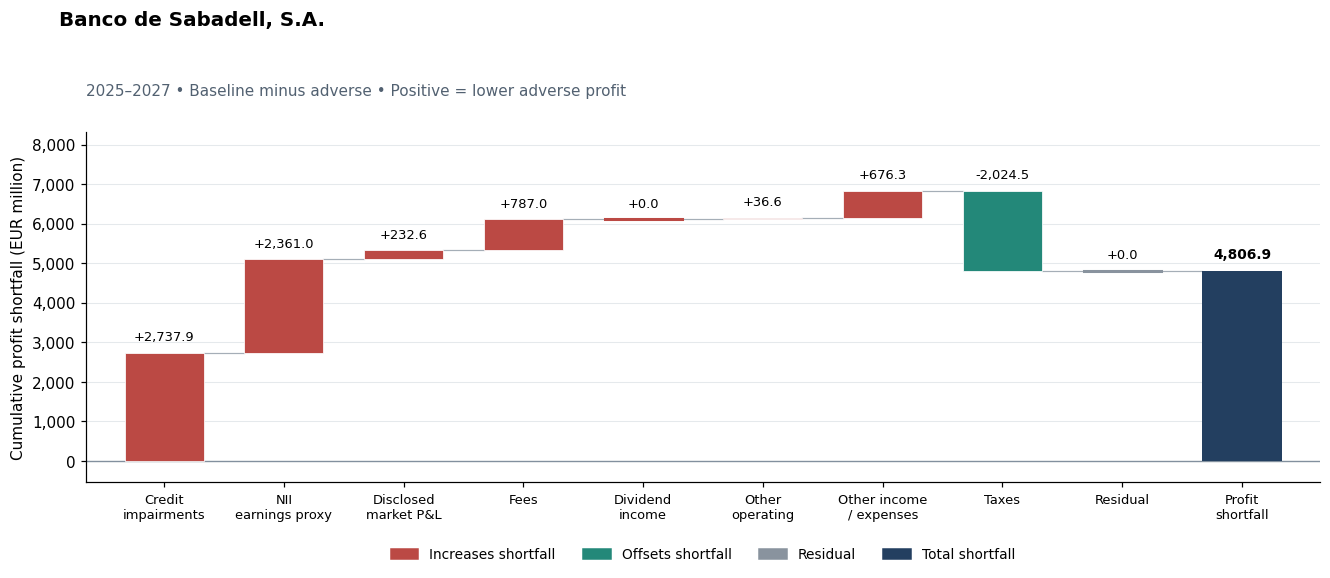

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,661.48"
Disclosed interest expense (signed),"7,022.45"
Derived NII adjustment remainder,0.00
Total NII,"2,360.97"


In [34]:
report_bank('SI5RG2M0WQQLZCXKRM20')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,898.2,-576.8,"1,475.0"
2026,"1,398.3",443.7,954.6
2027,"1,339.7",635.9,703.9
2025–2027 cumulative,"3,636.2",502.8,"3,133.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,185.64","-2,936.10","1,750.45",55.86
NII (earnings proxy),"7,900.93","6,227.14","1,673.79",53.42
Trading P&L (market proxy),37.57,-1.31,38.88,1.24
Non-trading FVPL revaluation,0.00,-74.25,74.25,2.37
Fees and commissions,"2,104.57","1,709.60",394.97,12.61
Dividend income,45.30,22.65,22.65,0.72
Other operating P&L (disclosed),-220.27,-152.29,-67.98,-2.17
Other income/expenses (incl. OR/CCR),"-3,499.48","-3,812.85",313.37,10.00
Taxes (signed P&L),"-1,546.76",-479.84,"-1,066.92",-34.05
Unexplained residual,-0.00,0.00,-0.00,-0.00


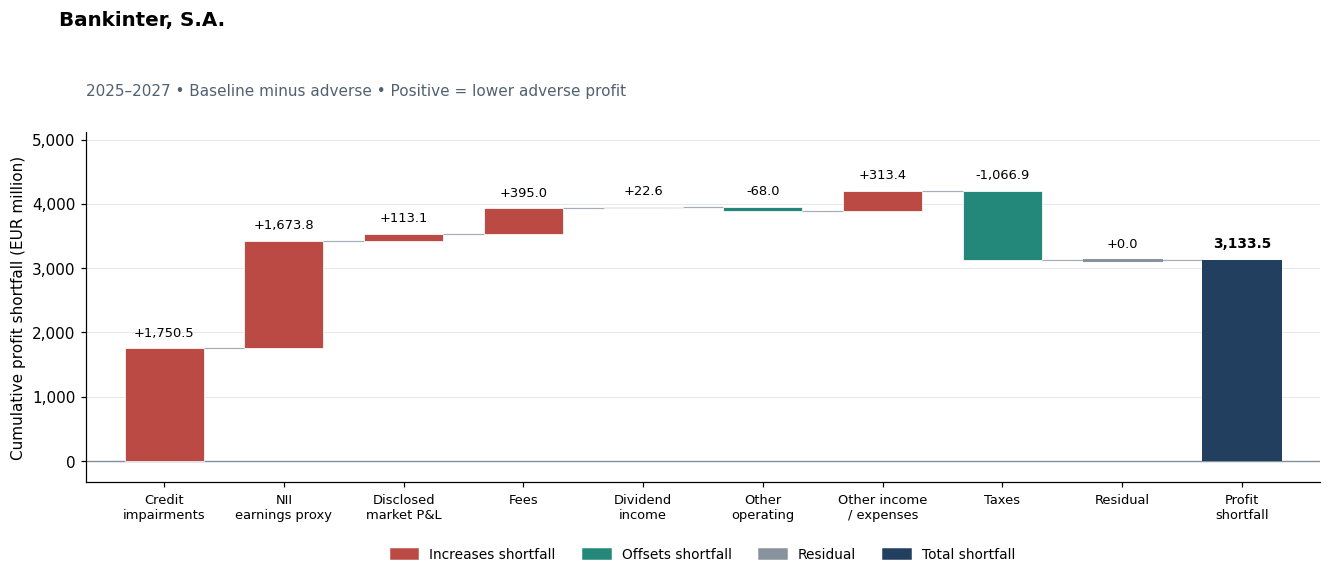

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,676.99"
Disclosed interest expense (signed),"4,210.46"
Derived NII adjustment remainder,140.31
Total NII,"1,673.79"


In [35]:
report_bank('VWMYAEQSTOPNV0SUGU82')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"5,472.3","-1,316.8","6,789.1"
2026,"4,869.5","2,164.0","2,705.4"
2027,"4,568.4","2,589.4","1,978.9"
2025–2027 cumulative,"14,910.2","3,436.7","11,473.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-3,720.51","-10,222.60","6,502.09",56.67
NII (earnings proxy),"31,849.86","26,689.17","5,160.69",44.98
Trading P&L (market proxy),234.51,-332.01,566.53,4.94
Non-trading FVPL revaluation,0.00,-29.47,29.47,0.26
Fees and commissions,"11,920.69","10,160.67","1,760.02",15.34
Dividend income,158.17,123.25,34.92,0.30
Other operating P&L (disclosed),"-2,572.96","-2,589.52",16.56,0.14
Other income/expenses (incl. OR/CCR),"-18,323.38","-20,225.13","1,901.74",16.58
Taxes (signed P&L),"-4,636.22",-137.69,"-4,498.54",-39.21
Unexplained residual,0.00,-0.00,0.00,0.00


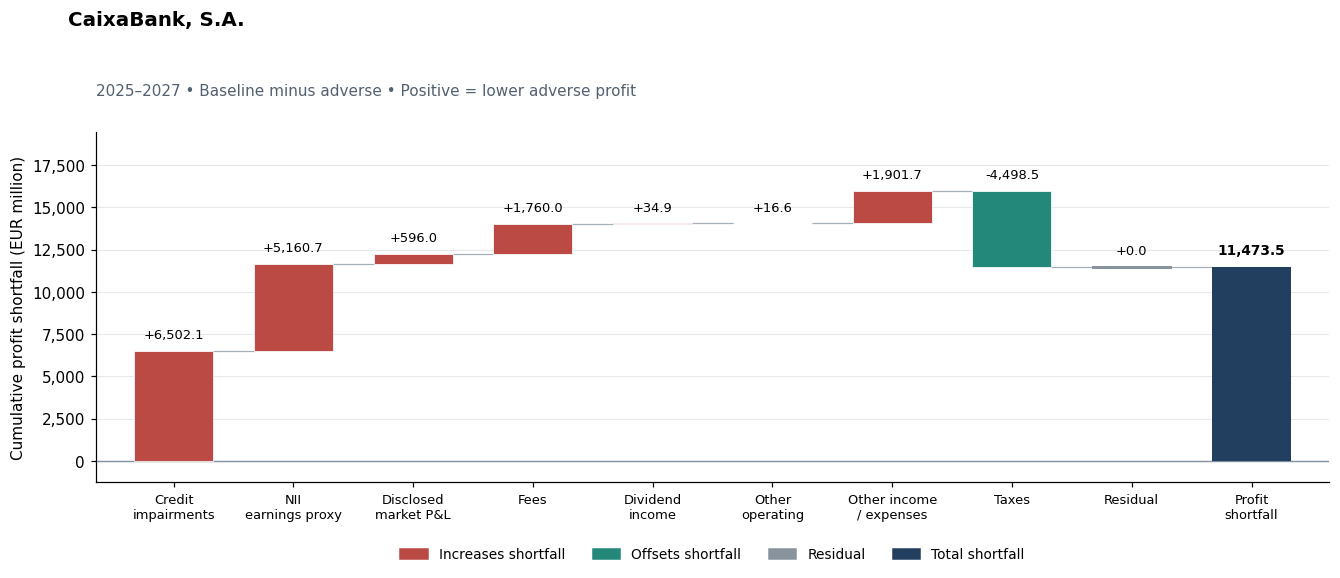

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-13,134.03"
Disclosed interest expense (signed),"18,294.72"
Derived NII adjustment remainder,0.00
Total NII,"5,160.69"


In [36]:
report_bank('7CUNS533WID6K7DGFI87')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,544.9,-105.0,649.9
2026,709.5,260.4,449.1
2027,702.1,290.6,411.5
2025–2027 cumulative,"1,956.5",445.9,"1,510.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-746.68,"-1,384.66",637.98,42.23
NII (earnings proxy),"4,980.64","4,069.01",911.63,60.35
Trading P&L (market proxy),18.87,-7.66,26.52,1.76
Non-trading FVPL revaluation,0.00,-1.06,1.06,0.07
Fees and commissions,"1,433.28","1,126.70",306.58,20.30
Dividend income,44.55,23.35,21.21,1.40
Other operating P&L (disclosed),-259.34,-256.70,-2.63,-0.17
Other income/expenses (incl. OR/CCR),"-2,804.77","-2,998.84",194.07,12.85
Taxes (signed P&L),-710.06,-124.20,-585.86,-38.78
Unexplained residual,0.00,0.00,-0.00,-0.00


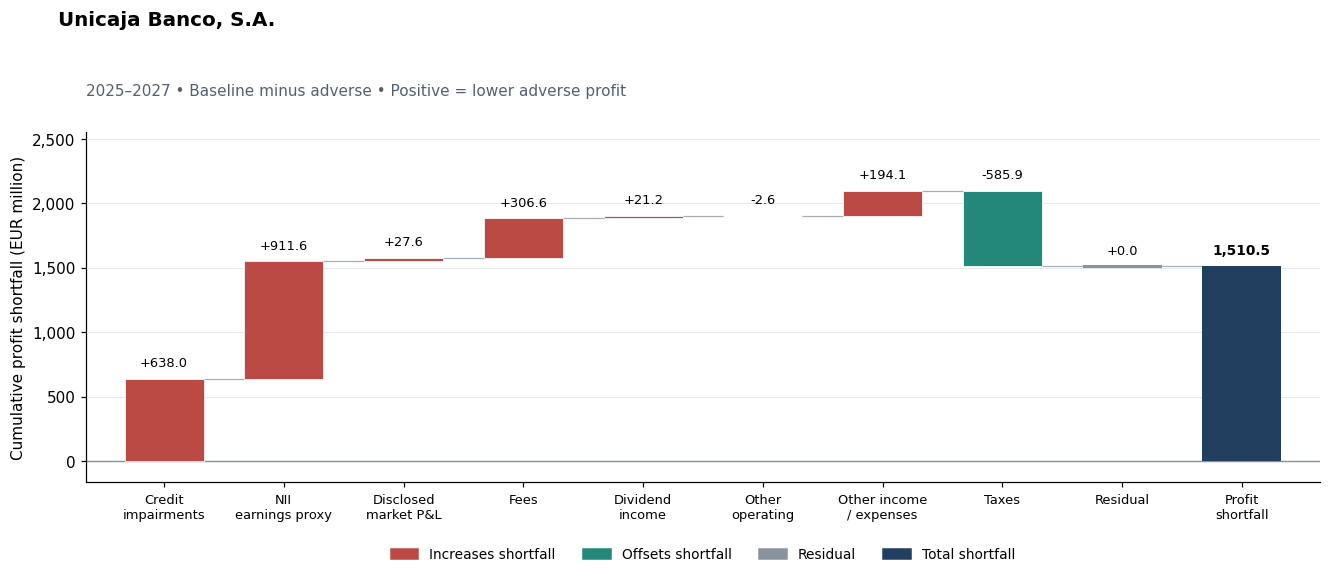

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,090.99"
Disclosed interest expense (signed),"2,945.48"
Derived NII adjustment remainder,57.13
Total NII,911.63


In [37]:
report_bank('5493007SJLLCTM6J6M37')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"3,500.4","-2,508.1","6,008.5"
2026,"3,786.9","1,251.2","2,535.6"
2027,"3,694.2","1,304.8","2,389.4"
2025–2027 cumulative,"10,981.5",48.0,"10,933.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,307.96","-4,890.13","2,582.17",23.62
NII (earnings proxy),"21,481.39","18,764.20","2,717.19",24.85
Trading P&L (market proxy),"4,592.12",479.44,"4,112.68",37.62
Non-trading FVPL revaluation,0.00,-367.58,367.58,3.36
Fees and commissions,"8,042.60","6,280.27","1,762.33",16.12
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),104.31,-817.74,922.05,8.43
Other income/expenses (incl. OR/CCR),"-16,224.59","-19,466.07","3,241.47",29.65
Taxes (signed P&L),"-4,706.36",65.58,"-4,771.94",-43.65
Unexplained residual,-0.00,-0.00,-0.00,-0.00


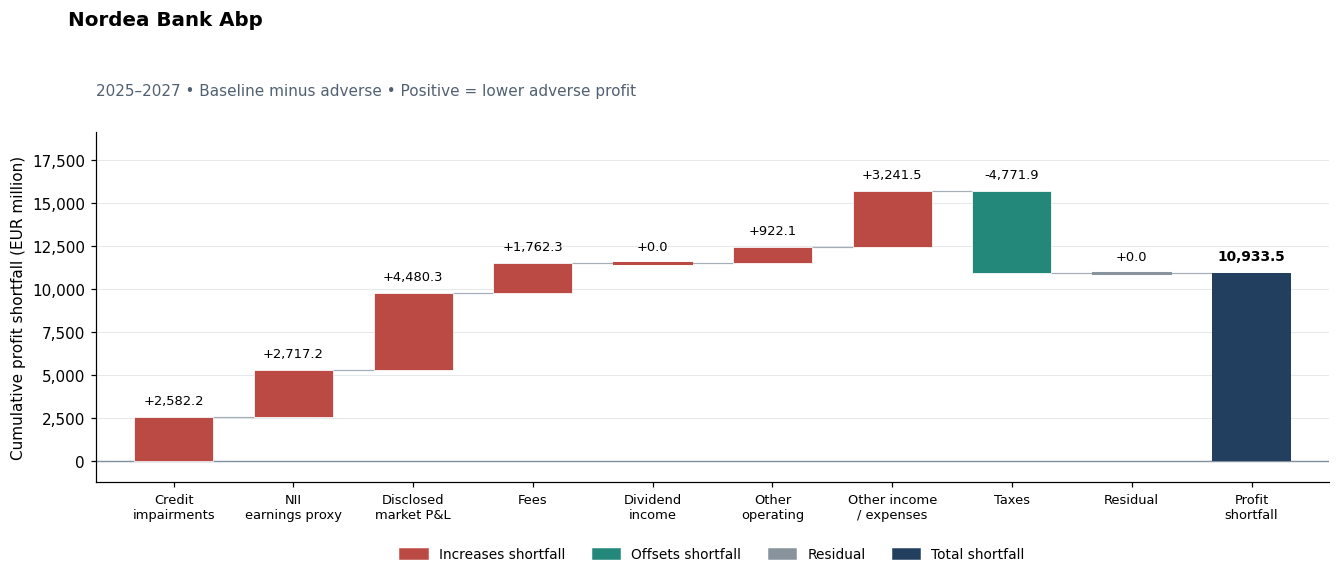

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-9,342.34"
Disclosed interest expense (signed),"11,854.10"
Derived NII adjustment remainder,205.42
Total NII,"2,717.19"


In [38]:
report_bank('529900ODI3047E2LIV03')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,848.4,-914.2,"1,762.7"
2026,"1,021.5",194.8,826.7
2027,769.1,76.1,692.9
2025–2027 cumulative,"2,639.0",-643.3,"3,282.3"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,309.10","-4,282.16","2,973.06",90.58
NII (earnings proxy),"7,871.17","7,779.59",91.58,2.79
Trading P&L (market proxy),160.30,-288.24,448.54,13.67
Non-trading FVPL revaluation,0.00,272.43,-272.43,-8.30
Fees and commissions,"1,561.44","1,156.51",404.93,12.34
Dividend income,495.90,247.95,247.95,7.55
Other operating P&L (disclosed),223.19,-117.36,340.55,10.38
Other income/expenses (incl. OR/CCR),"-5,232.85","-5,397.30",164.45,5.01
Taxes (signed P&L),"-1,131.02",-14.66,"-1,116.35",-34.01
Unexplained residual,0.00,0.00,-0.00,-0.00


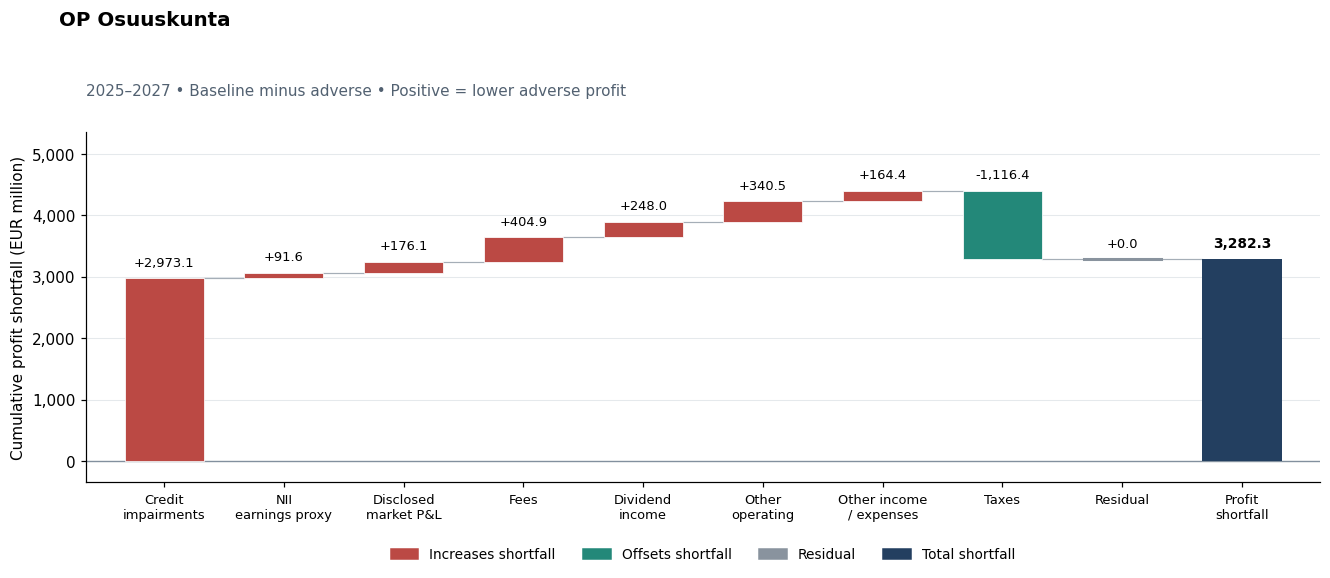

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,065.24"
Disclosed interest expense (signed),"4,156.82"
Derived NII adjustment remainder,0.00
Total NII,91.58


In [39]:
report_bank('7437003B5WFBOIEFY714')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"12,458.3","-9,698.3","22,156.6"
2026,"13,477.4","4,964.9","8,512.6"
2027,"13,525.7","7,953.6","5,572.1"
2025–2027 cumulative,"39,461.5","3,220.2","36,241.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-9,855.40","-27,648.61","17,793.21",49.10
NII (earnings proxy),"78,964.91","63,366.50","15,598.41",43.04
Trading P&L (market proxy),"15,080.60","-12,902.53","27,983.14",77.21
Non-trading FVPL revaluation,0.00,"16,529.00","-16,529.00",-45.61
Fees and commissions,"35,503.13","27,707.78","7,795.35",21.51
Dividend income,"9,897.35","6,441.65","3,455.69",9.54
Other operating P&L (disclosed),"15,094.79","13,771.54","1,323.25",3.65
Other income/expenses (incl. OR/CCR),"-90,256.90","-84,007.49","-6,249.41",-17.24
Taxes (signed P&L),"-14,967.03",-37.62,"-14,929.41",-41.19
Unexplained residual,-0.00,0.00,-0.00,-0.00


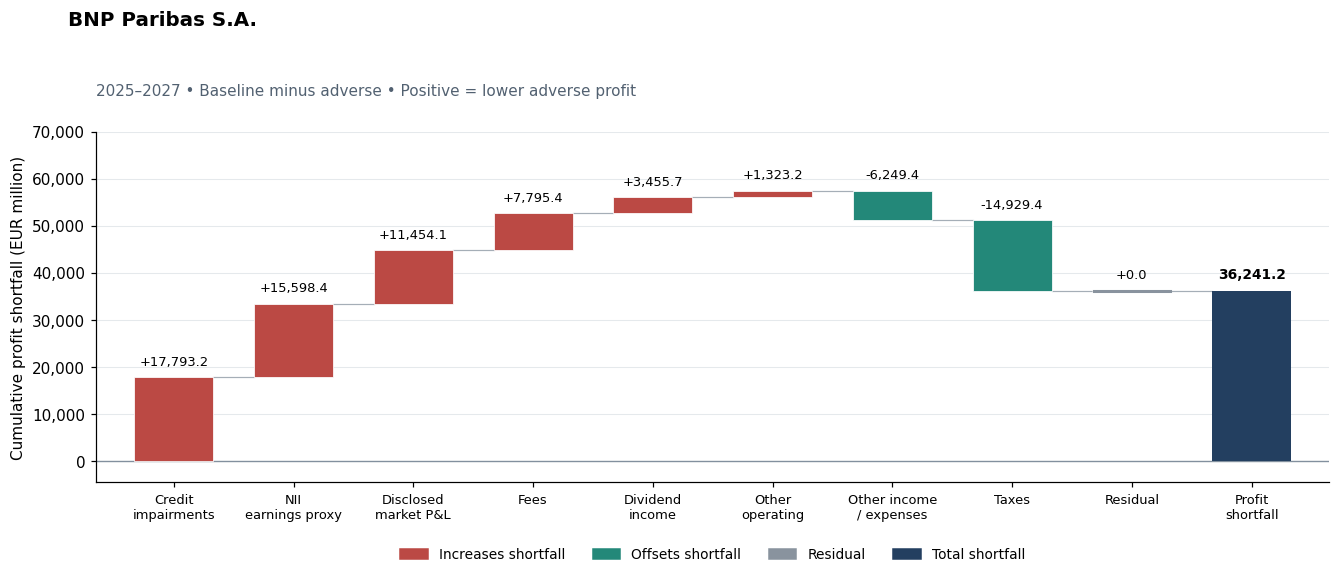

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-53,118.37"
Disclosed interest expense (signed),"65,471.24"
Derived NII adjustment remainder,"3,245.54"
Total NII,"15,598.41"


In [40]:
report_bank('R0MUWSFPU8MPRO8K5P83')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,-364.7,"-2,341.2","1,976.4"
2026,-350.9,-425.8,74.9
2027,-340.1,-378.1,38.0
2025–2027 cumulative,"-1,055.7","-3,145.0","2,089.3"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-2.00,-3.76,1.77,0.08
NII (earnings proxy),-424.21,-396.26,-27.96,-1.34
Trading P&L (market proxy),"1,660.22",508.25,"1,151.97",55.14
Non-trading FVPL revaluation,0.00,-17.09,17.09,0.82
Fees and commissions,343.79,267.39,76.40,3.66
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),"-1,283.76","-1,283.76",0.00,0.00
Other income/expenses (incl. OR/CCR),"-1,349.71","-2,219.78",870.07,41.64
Taxes (signed P&L),0.00,0.00,0.00,0.00
Unexplained residual,-0.00,-0.00,0.00,0.00


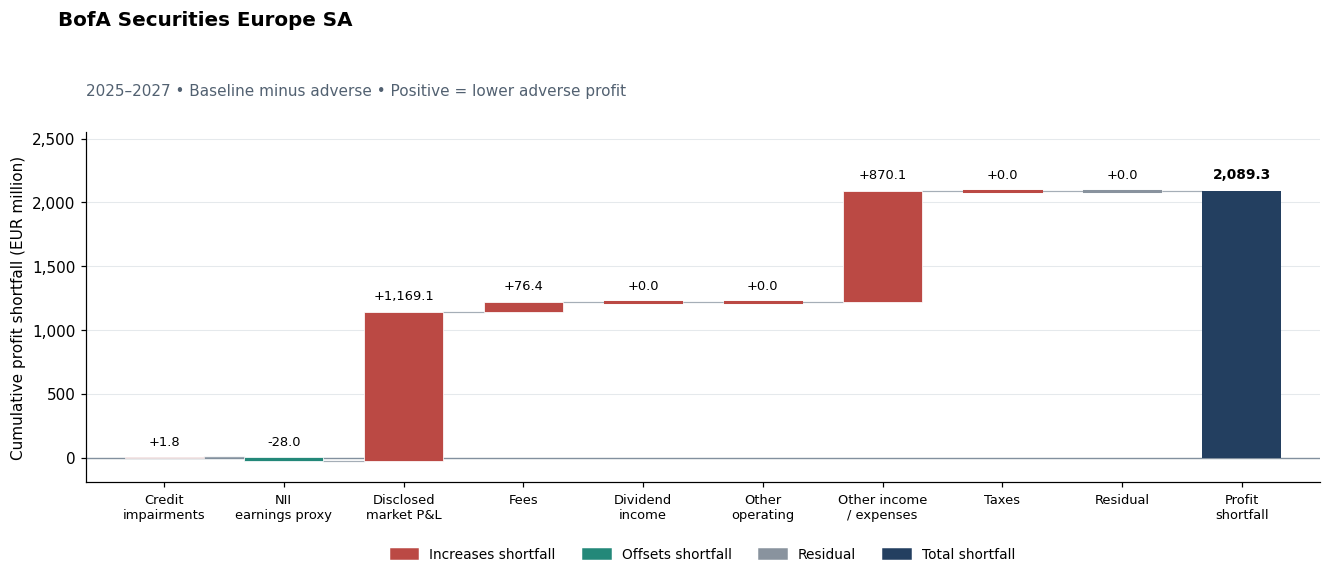

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,197.41"
Disclosed interest expense (signed),"1,165.46"
Derived NII adjustment remainder,3.99
Total NII,-27.96


In [41]:
report_bank('549300FH0WJAPEHTIQ77')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"3,990.4","-7,148.0","11,138.3"
2026,"3,594.5","-1,377.0","4,971.6"
2027,"2,820.4","-1,242.4","4,062.8"
2025–2027 cumulative,"10,405.3","-9,767.4","20,172.7"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-6,659.89","-17,238.17","10,578.28",52.44
NII (earnings proxy),"28,659.33","19,938.55","8,720.78",43.23
Trading P&L (market proxy),"1,757.42","-1,314.35","3,071.77",15.23
Non-trading FVPL revaluation,0.00,"-1,882.67","1,882.67",9.33
Fees and commissions,"18,701.76","16,831.58","1,870.18",9.27
Dividend income,264.90,264.90,0.00,0.00
Other operating P&L (disclosed),"3,071.26","2,865.63",205.63,1.02
Other income/expenses (incl. OR/CCR),"-32,478.98","-33,418.97",939.99,4.66
Taxes (signed P&L),"-2,910.54","4,186.05","-7,096.58",-35.18
Unexplained residual,-0.00,-0.00,0.00,0.00


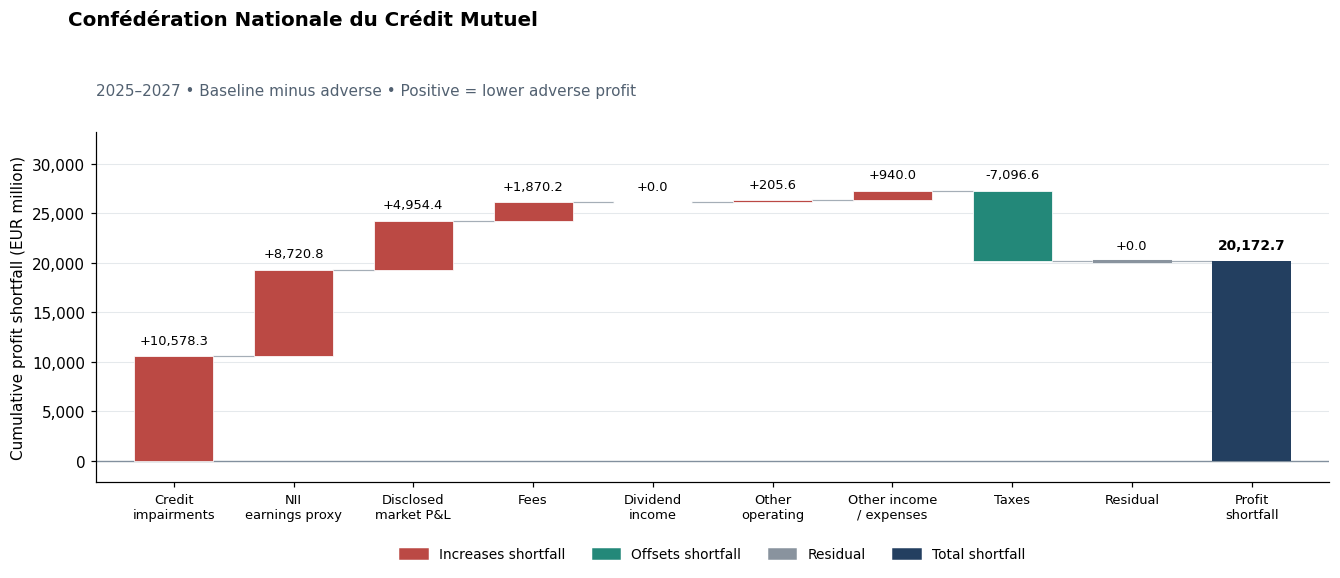

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-25,187.71"
Disclosed interest expense (signed),"33,870.36"
Derived NII adjustment remainder,38.12
Total NII,"8,720.78"


In [42]:
report_bank('9695000CG7B84NLR5984')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"3,979.9","-8,465.8","12,445.8"
2026,"3,225.5",-574.4,"3,799.9"
2027,"2,689.5",-493.1,"3,182.6"
2025–2027 cumulative,"9,894.9","-9,533.4","19,428.3"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-3,581.76","-13,397.19","9,815.43",50.52
NII (earnings proxy),"25,257.29","15,401.56","9,855.73",50.73
Trading P&L (market proxy),"6,109.35","1,122.03","4,987.32",25.67
Non-trading FVPL revaluation,0.00,-785.26,785.26,4.04
Fees and commissions,"36,416.38","32,128.35","4,288.03",22.07
Dividend income,675.19,337.59,337.59,1.74
Other operating P&L (disclosed),"1,890.62","2,115.67",-225.05,-1.16
Other income/expenses (incl. OR/CCR),"-52,953.41","-50,675.36","-2,278.04",-11.73
Taxes (signed P&L),"-3,918.76","4,219.20","-8,137.96",-41.89
Unexplained residual,-0.00,0.00,-0.00,-0.00


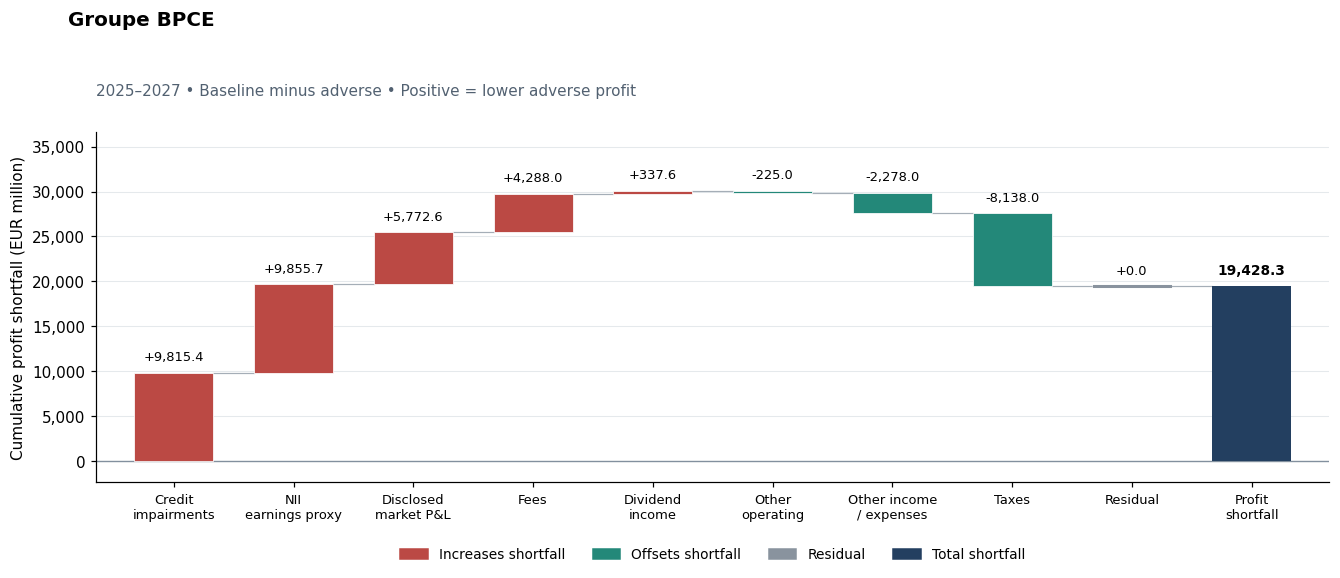

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-38,318.19"
Disclosed interest expense (signed),"48,173.92"
Derived NII adjustment remainder,0.00
Total NII,"9,855.73"


In [43]:
report_bank('FR9695005MSX1OYEMGDF')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"11,237.9","-10,457.7","21,695.6"
2026,"7,672.3","-4,184.4","11,856.8"
2027,"7,234.9",321.8,"6,913.1"
2025–2027 cumulative,"26,145.1","-14,320.4","40,465.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-4,672.88","-22,099.90","17,427.03",43.07
NII (earnings proxy),"53,340.63","32,116.07","21,224.57",52.45
Trading P&L (market proxy),"6,916.22",-804.47,"7,720.69",19.08
Non-trading FVPL revaluation,0.00,"-4,135.96","4,135.96",10.22
Fees and commissions,"52,170.54","45,631.04","6,539.50",16.16
Dividend income,381.24,190.62,190.62,0.47
Other operating P&L (disclosed),"6,733.92","6,375.91",358.01,0.88
Other income/expenses (incl. OR/CCR),"-79,195.17","-79,183.27",-11.90,-0.03
Taxes (signed P&L),"-9,529.38","7,589.59","-17,118.97",-42.31
Unexplained residual,0.00,0.00,-0.00,-0.00


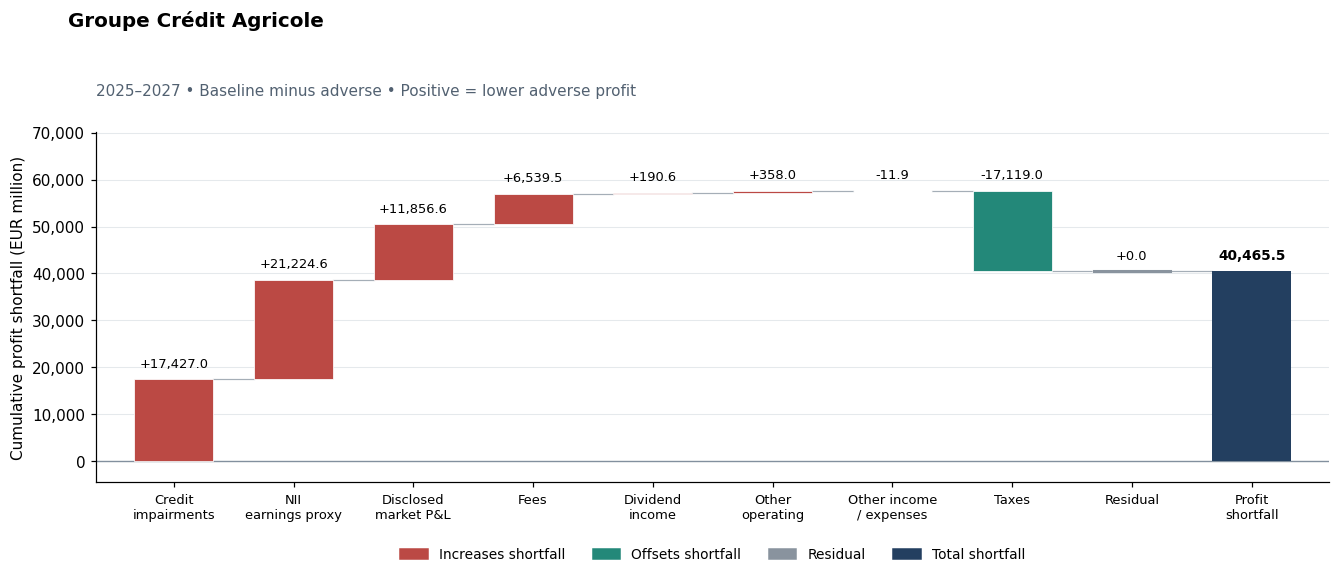

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-62,922.52"
Disclosed interest expense (signed),"82,848.03"
Derived NII adjustment remainder,"1,299.06"
Total NII,"21,224.57"


In [44]:
report_bank('FR969500TJ5KRTCJQWXH')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,342.1,"-1,887.7","2,229.8"
2026,299.7,-345.5,645.2
2027,212.6,-336.5,549.0
2025–2027 cumulative,854.4,"-2,569.7","3,424.1"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-239.91,"-1,060.48",820.57,23.96
NII (earnings proxy),"3,383.21","2,437.19",946.02,27.63
Trading P&L (market proxy),"1,191.41",-549.80,"1,741.21",50.85
Non-trading FVPL revaluation,0.00,"1,223.21","-1,223.21",-35.72
Fees and commissions,"3,303.75","2,568.41",735.34,21.48
Dividend income,75.90,96.95,-21.05,-0.61
Other operating P&L (disclosed),560.09,523.22,36.86,1.08
Other income/expenses (incl. OR/CCR),"-6,986.11","-7,808.40",822.29,24.01
Taxes (signed P&L),-433.97,0.00,-433.97,-12.67
Unexplained residual,-0.00,-0.00,0.00,0.00


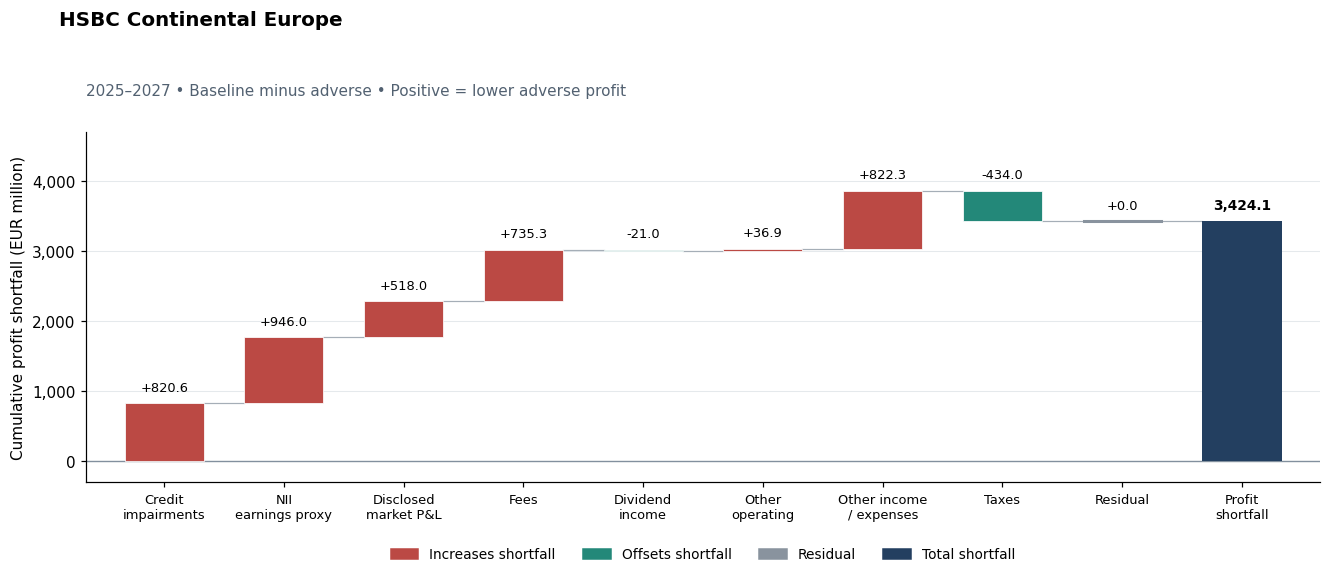

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-7,519.05"
Disclosed interest expense (signed),"8,465.07"
Derived NII adjustment remainder,0.00
Total NII,946.02


In [45]:
report_bank('F0HUI1NY1AZMJMD8LP67')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,446.4","-1,677.7","3,124.1"
2026,"1,129.6",-632.0,"1,761.7"
2027,809.5,"-1,147.7","1,957.2"
2025–2027 cumulative,"3,385.6","-3,457.4","6,843.0"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,159.64","-3,017.23","1,857.59",27.15
NII (earnings proxy),"7,417.18","4,388.17","3,029.02",44.26
Trading P&L (market proxy),-85.43,-493.68,408.26,5.97
Non-trading FVPL revaluation,0.00,357.38,-357.38,-5.22
Fees and commissions,"6,942.70","6,167.43",775.27,11.33
Dividend income,18.83,14.12,4.71,0.07
Other operating P&L (disclosed),409.10,347.27,61.83,0.90
Other income/expenses (incl. OR/CCR),"-8,993.95","-11,220.84","2,226.90",32.54
Taxes (signed P&L),"-1,163.22",0.00,"-1,163.22",-17.00
Unexplained residual,-0.00,0.00,-0.00,-0.00


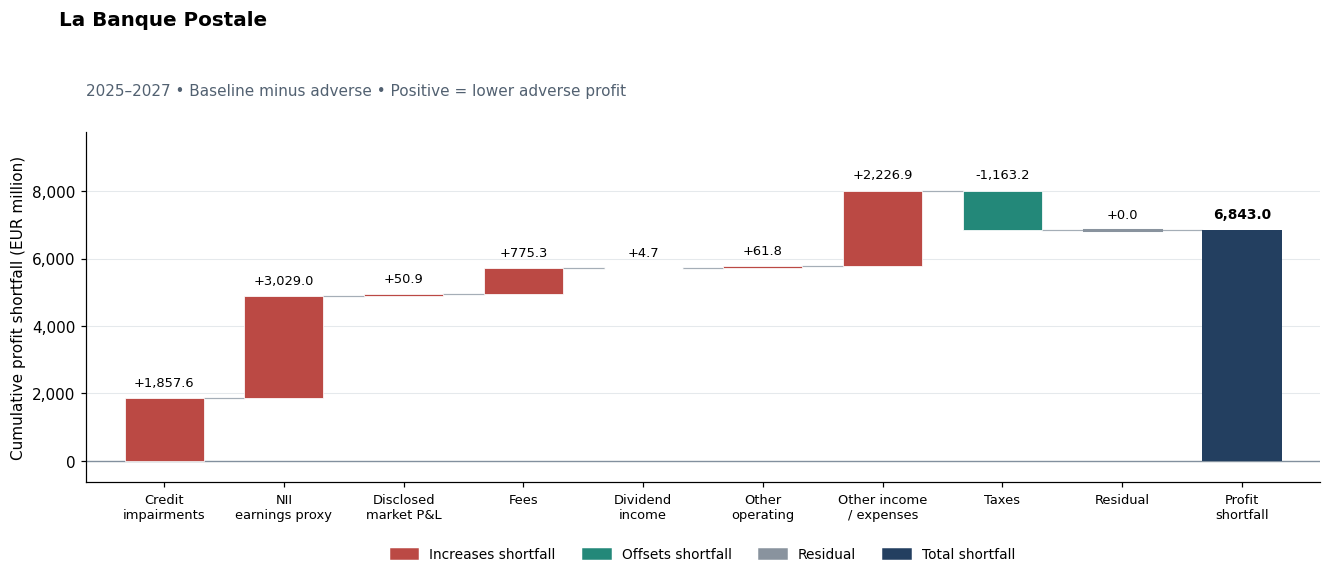

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-6,230.32"
Disclosed interest expense (signed),"8,500.87"
Derived NII adjustment remainder,758.47
Total NII,"3,029.02"


In [46]:
report_bank('96950066U5XAAIRCPA78')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"5,873.3","-8,940.1","14,813.5"
2026,"5,766.2","1,048.9","4,717.3"
2027,"5,217.8","1,225.0","3,992.8"
2025–2027 cumulative,"16,857.3","-6,666.3","23,523.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,867.75","-10,007.77","7,140.02",30.35
NII (earnings proxy),"35,603.16","23,240.92","12,362.24",52.55
Trading P&L (market proxy),"13,261.37","5,780.19","7,481.19",31.80
Non-trading FVPL revaluation,0.00,"-1,569.85","1,569.85",6.67
Fees and commissions,"21,000.28","16,408.26","4,592.02",19.52
Dividend income,253.09,168.73,84.36,0.36
Other operating P&L (disclosed),"10,887.29","9,712.54","1,174.75",4.99
Other income/expenses (incl. OR/CCR),"-53,871.07","-52,487.10","-1,383.96",-5.88
Taxes (signed P&L),"-7,409.08","2,087.83","-9,496.91",-40.37
Unexplained residual,0.00,-0.00,0.00,0.00


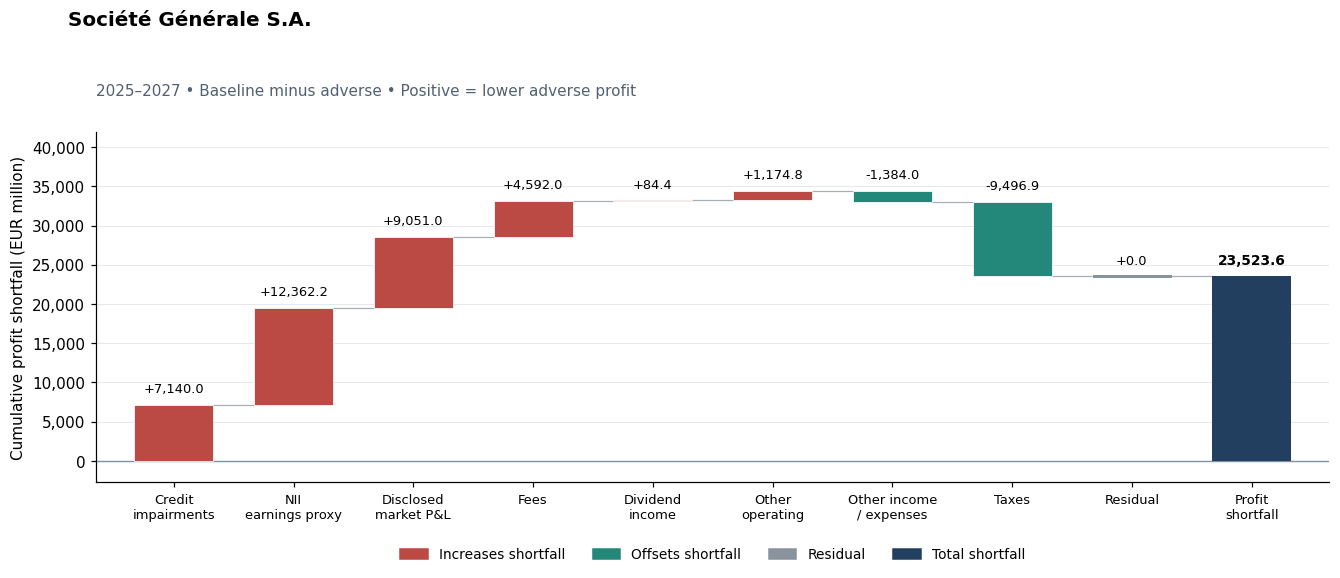

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-22,018.14"
Disclosed interest expense (signed),"33,686.13"
Derived NII adjustment remainder,694.24
Total NII,"12,362.24"


In [47]:
report_bank('O2RNE8IBXP4R0TD8PU41')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,659.0,-367.9,"1,026.9"
2026,787.3,266.7,520.6
2027,802.4,372.3,430.1
2025–2027 cumulative,"2,248.7",271.1,"1,977.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-812.94,"-1,955.82","1,142.87",57.79
NII (earnings proxy),"5,329.45","4,591.96",737.49,37.29
Trading P&L (market proxy),126.59,-59.32,185.91,9.40
Non-trading FVPL revaluation,0.00,-115.69,115.69,5.85
Fees and commissions,"1,257.32","1,020.61",236.71,11.97
Dividend income,17.69,8.85,8.85,0.45
Other operating P&L (disclosed),122.02,113.54,8.48,0.43
Other income/expenses (incl. OR/CCR),"-2,831.01","-3,220.13",389.12,19.68
Taxes (signed P&L),-960.45,-112.92,-847.54,-42.86
Unexplained residual,0.00,0.00,0.00,0.00


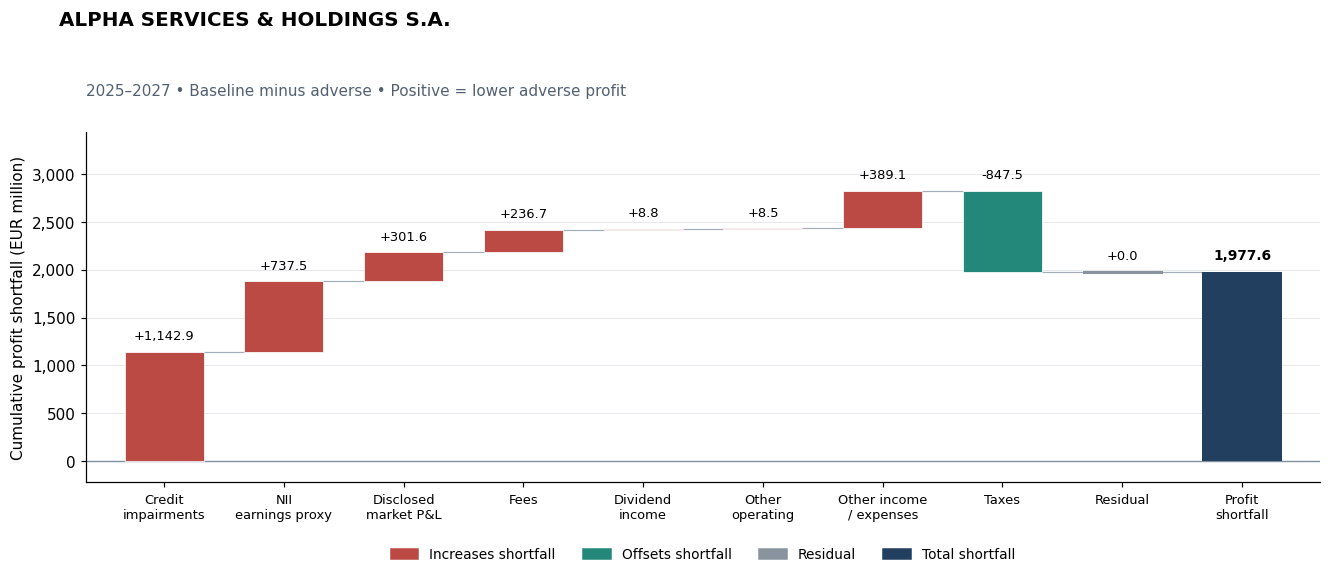

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,477.94"
Disclosed interest expense (signed),"2,120.37"
Derived NII adjustment remainder,95.06
Total NII,737.49


In [48]:
report_bank('5299009N55YRQC69CN08')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,070.8",58.3,"1,012.5"
2026,"1,006.5",490.1,516.4
2027,953.0,532.5,420.6
2025–2027 cumulative,"3,030.3","1,080.9","1,949.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-418.03,"-1,778.26","1,360.23",69.78
NII (earnings proxy),"6,685.17","5,857.57",827.60,42.45
Trading P&L (market proxy),0.00,-49.21,49.21,2.52
Non-trading FVPL revaluation,0.00,-19.95,19.95,1.02
Fees and commissions,"1,204.88",957.90,246.99,12.67
Dividend income,9.51,4.75,4.75,0.24
Other operating P&L (disclosed),-20.10,93.12,-113.21,-5.81
Other income/expenses (incl. OR/CCR),"-3,132.44","-3,521.76",389.32,19.97
Taxes (signed P&L),"-1,298.70",-463.25,-835.45,-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


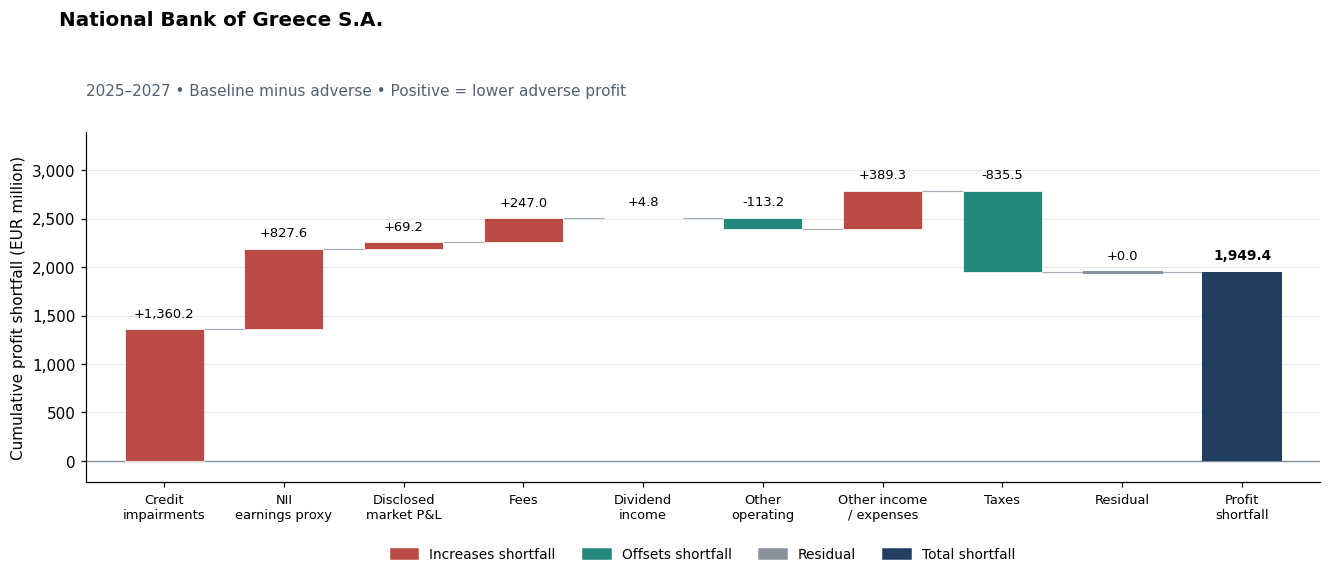

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,416.20"
Disclosed interest expense (signed),"2,243.81"
Derived NII adjustment remainder,0.00
Total NII,827.60


In [49]:
report_bank('5UMCZOEYKCVFAW8ZLO05')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,113.6",-39.0,"1,152.6"
2026,"1,039.0",163.5,875.5
2027,"1,033.3",486.7,546.6
2025–2027 cumulative,"3,185.9",611.2,"2,574.7"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-614.78,"-1,836.56","1,221.78",47.45
NII (earnings proxy),"6,392.45","5,584.16",808.29,31.39
Trading P&L (market proxy),32.75,-0.40,33.15,1.29
Non-trading FVPL revaluation,0.00,-78.58,78.58,3.05
Fees and commissions,"1,555.22","1,291.72",263.51,10.23
Dividend income,11.11,5.56,5.56,0.22
Other operating P&L (disclosed),18.81,-442.09,460.90,17.90
Other income/expenses (incl. OR/CCR),"-2,852.65","-3,655.29",802.64,31.17
Taxes (signed P&L),"-1,357.03",-257.32,"-1,099.71",-42.71
Unexplained residual,-0.00,-0.00,0.00,0.00


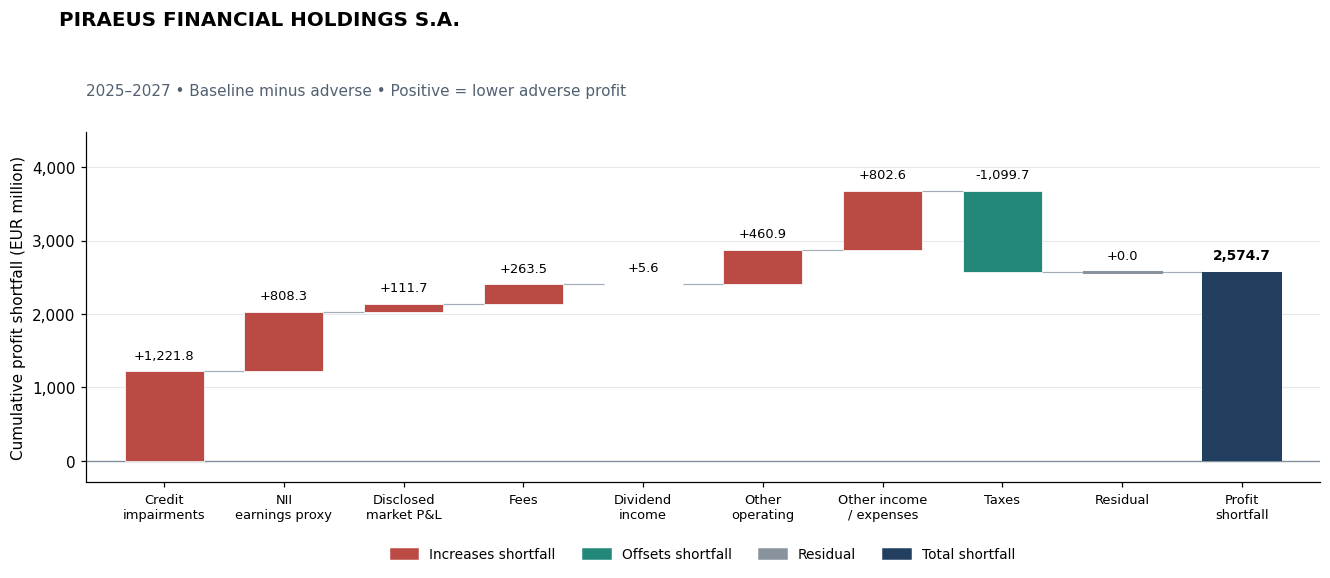

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,607.23"
Disclosed interest expense (signed),"2,415.52"
Derived NII adjustment remainder,0.00
Total NII,808.29


In [50]:
report_bank('M6AD1Y1KW32H8THQ6F76')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,330.4",-559.8,"2,890.2"
2026,"1,952.5",562.8,"1,389.8"
2027,"1,886.2",665.4,"1,220.8"
2025–2027 cumulative,"6,169.1",668.3,"5,500.8"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-688.26,"-4,207.05","3,518.80",63.97
NII (earnings proxy),"12,608.03","10,213.68","2,394.35",43.53
Trading P&L (market proxy),0.00,-6.50,6.50,0.12
Non-trading FVPL revaluation,0.00,-107.23,107.23,1.95
Fees and commissions,"5,965.30","4,789.34","1,175.96",21.38
Dividend income,148.54,74.27,74.27,1.35
Other operating P&L (disclosed),151.26,141.45,9.81,0.18
Other income/expenses (incl. OR/CCR),"-9,432.01","-10,003.36",571.34,10.39
Taxes (signed P&L),"-2,583.78",-226.31,"-2,357.47",-42.86
Unexplained residual,-0.00,-0.00,-0.00,-0.00


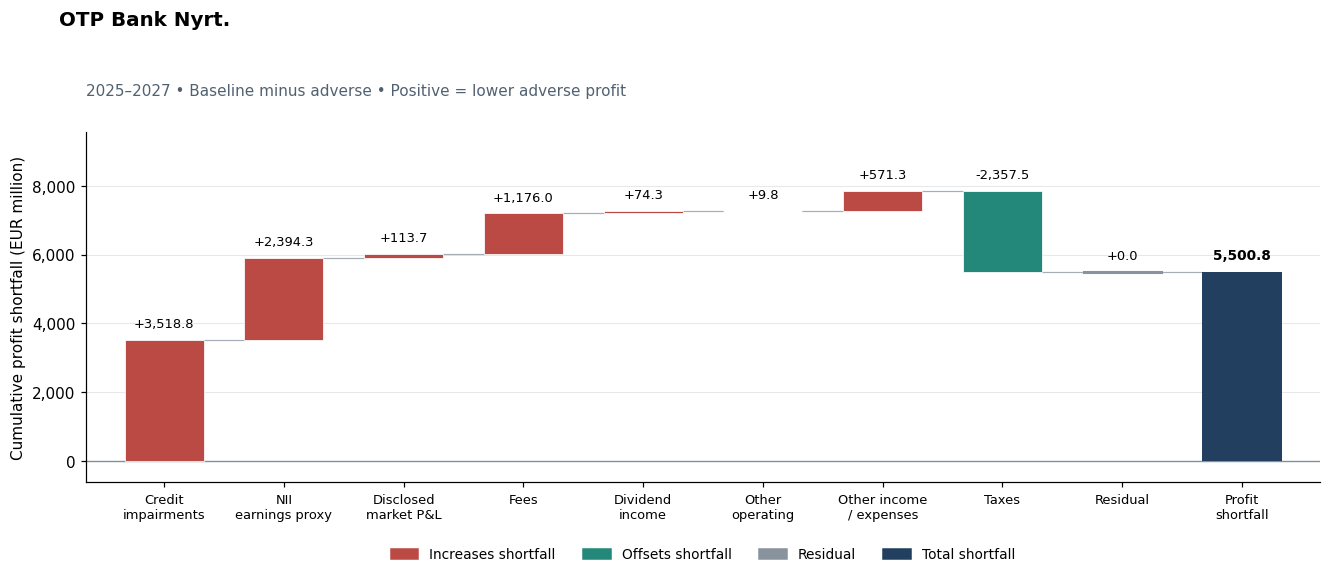

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,-199.90
Disclosed interest expense (signed),"2,594.25"
Derived NII adjustment remainder,-0.00
Total NII,"2,394.35"


In [51]:
report_bank('529900W3MOO00A18X956')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,181.0",-376.3,"2,557.3"
2026,"1,681.7",-30.8,"1,712.5"
2027,"1,436.2",146.2,"1,290.0"
2025–2027 cumulative,"5,299.0",-260.9,"5,559.8"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-547.15,"-4,564.33","4,017.18",72.25
NII (earnings proxy),"10,848.56","9,757.22","1,091.34",19.63
Trading P&L (market proxy),414.71,-14.31,429.02,7.72
Non-trading FVPL revaluation,0.00,-237.27,237.27,4.27
Fees and commissions,"1,784.75","1,388.14",396.61,7.13
Dividend income,3.94,1.97,1.97,0.04
Other operating P&L (disclosed),134.55,117.39,17.15,0.31
Other income/expenses (incl. OR/CCR),"-6,550.89","-6,687.89",137.00,2.46
Taxes (signed P&L),-789.49,-21.78,-767.72,-13.81
Unexplained residual,-0.00,-0.00,-0.00,-0.00


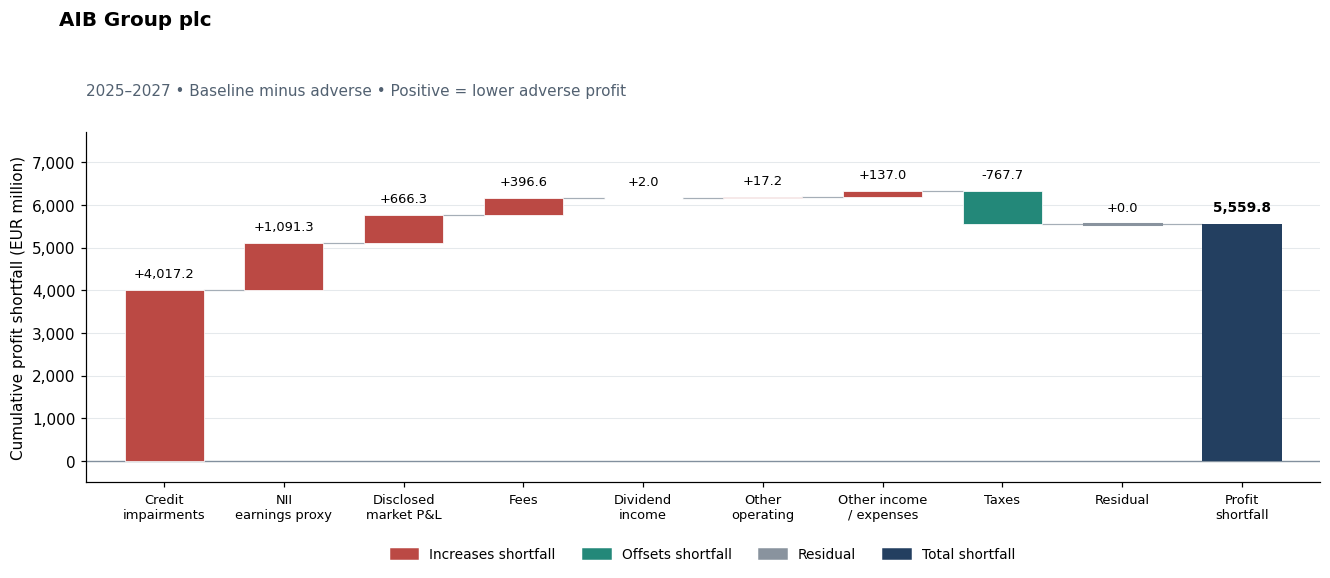

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-3,622.33"
Disclosed interest expense (signed),"4,713.66"
Derived NII adjustment remainder,-0.00
Total NII,"1,091.34"


In [52]:
report_bank('635400AKJBGNS5WNQL34')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,439.8,"-1,308.3","1,748.1"
2026,403.0,-20.4,423.4
2027,344.0,117.1,226.9
2025–2027 cumulative,"1,186.8","-1,211.6","2,398.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-522.14,"-2,072.34","1,550.20",64.63
NII (earnings proxy),"2,056.83","2,355.99",-299.16,-12.47
Trading P&L (market proxy),49.01,-126.21,175.22,7.31
Non-trading FVPL revaluation,0.00,-218.48,218.48,9.11
Fees and commissions,"1,210.03",909.02,301.01,12.55
Dividend income,39.60,19.80,19.80,0.83
Other operating P&L (disclosed),"1,528.77",841.92,686.85,28.64
Other income/expenses (incl. OR/CCR),"-2,666.67","-2,871.12",204.45,8.52
Taxes (signed P&L),-508.63,-50.19,-458.44,-19.11
Unexplained residual,-0.00,-0.00,0.00,0.00


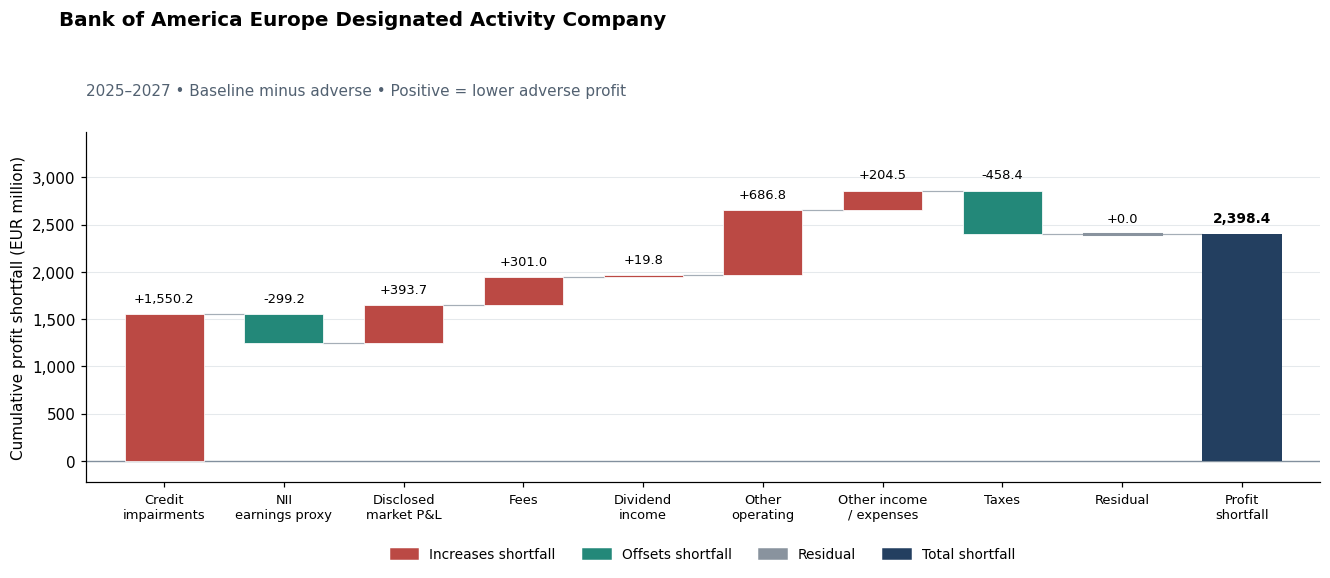

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,640.20"
Disclosed interest expense (signed),"2,299.92"
Derived NII adjustment remainder,41.13
Total NII,-299.16


In [53]:
report_bank('EQYXK86SF381Q21S3020')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,804.7",-468.3,"2,273.0"
2026,"1,670.5",329.7,"1,340.8"
2027,"1,493.0",559.2,933.8
2025–2027 cumulative,"4,968.2",420.6,"4,547.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-785.76,"-3,779.97","2,994.21",65.84
NII (earnings proxy),"11,686.10","10,195.82","1,490.29",32.77
Trading P&L (market proxy),106.20,-226.20,332.40,7.31
Non-trading FVPL revaluation,0.00,21.48,-21.48,-0.47
Fees and commissions,"1,488.93","1,150.92",338.00,7.43
Dividend income,108.48,54.24,54.24,1.19
Other operating P&L (disclosed),181.99,242.23,-60.24,-1.32
Other income/expenses (incl. OR/CCR),"-6,877.56","-7,180.70",303.14,6.67
Taxes (signed P&L),-940.15,-57.17,-882.97,-19.42
Unexplained residual,-0.00,-0.00,-0.00,-0.00


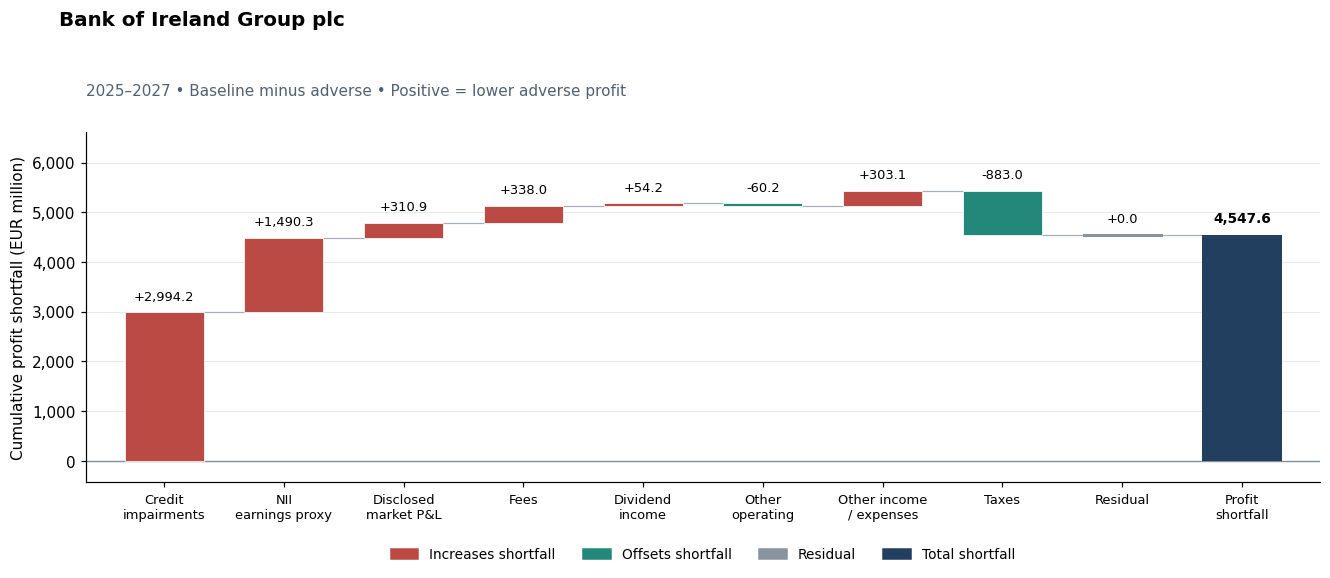

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,103.60"
Disclosed interest expense (signed),"5,593.89"
Derived NII adjustment remainder,-0.00
Total NII,"1,490.29"


In [54]:
report_bank('635400C8EK6DRI12LJ39')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,286.4,"-1,662.0","1,948.4"
2026,508.4,11.4,496.9
2027,453.8,24.0,429.9
2025–2027 cumulative,"1,248.6","-1,626.6","2,875.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-652.15,"-1,380.81",728.66,25.34
NII (earnings proxy),"2,922.10","1,355.47","1,566.63",54.49
Trading P&L (market proxy),478.35,286.86,191.49,6.66
Non-trading FVPL revaluation,0.00,-22.27,22.27,0.77
Fees and commissions,"2,973.53","2,412.96",560.57,19.50
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),-130.50,-180.75,50.25,1.75
Other income/expenses (incl. OR/CCR),"-3,807.58","-4,082.86",275.28,9.57
Taxes (signed P&L),-535.12,-15.18,-519.94,-18.08
Unexplained residual,-0.00,-0.00,0.00,0.00


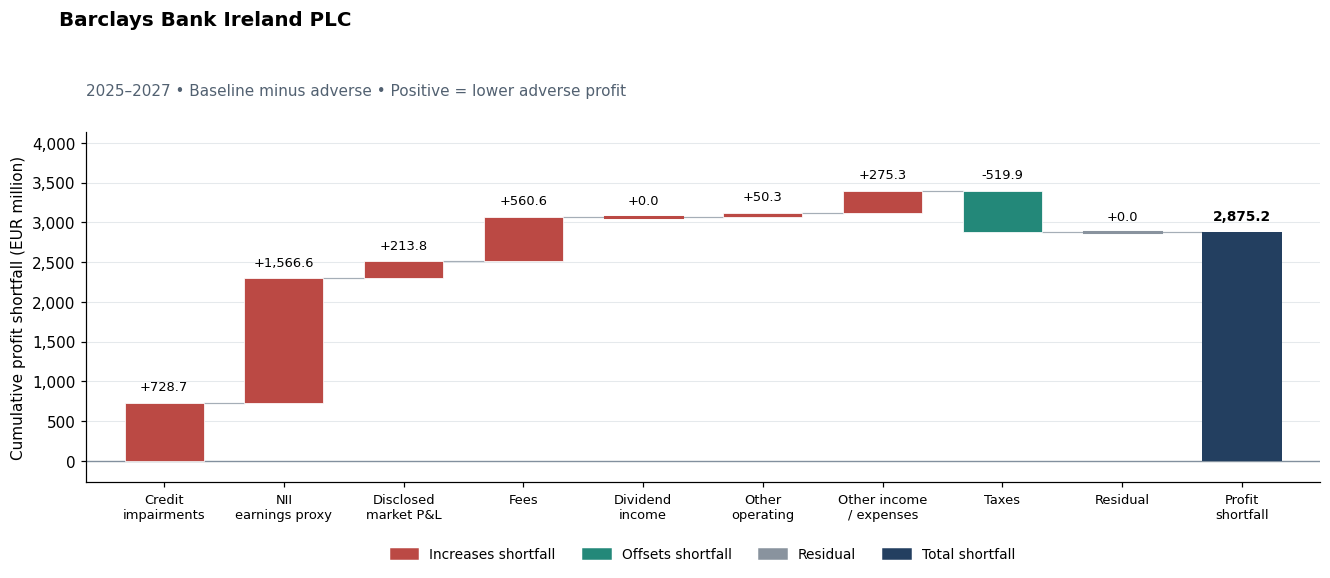

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,632.62"
Disclosed interest expense (signed),"3,089.94"
Derived NII adjustment remainder,109.31
Total NII,"1,566.63"


In [55]:
report_bank('2G5BKIC2CB69PRJH1W31')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,321.0",-440.6,"1,761.6"
2026,"1,163.8",600.7,563.1
2027,"1,076.1",762.0,314.2
2025–2027 cumulative,"3,561.0",922.1,"2,638.9"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-284.00,"-1,441.54","1,157.53",43.86
NII (earnings proxy),"7,110.32","6,776.36",333.96,12.66
Trading P&L (market proxy),"1,109.86",164.92,944.94,35.81
Non-trading FVPL revaluation,0.00,-77.95,77.95,2.95
Fees and commissions,"3,904.72","3,227.45",677.26,25.67
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),"2,783.99","2,874.63",-90.64,-3.43
Other income/expenses (incl. OR/CCR),"-9,537.81","-9,936.87",399.06,15.12
Taxes (signed P&L),"-1,526.12",-664.92,-861.20,-32.64
Unexplained residual,-0.00,0.00,-0.00,-0.00


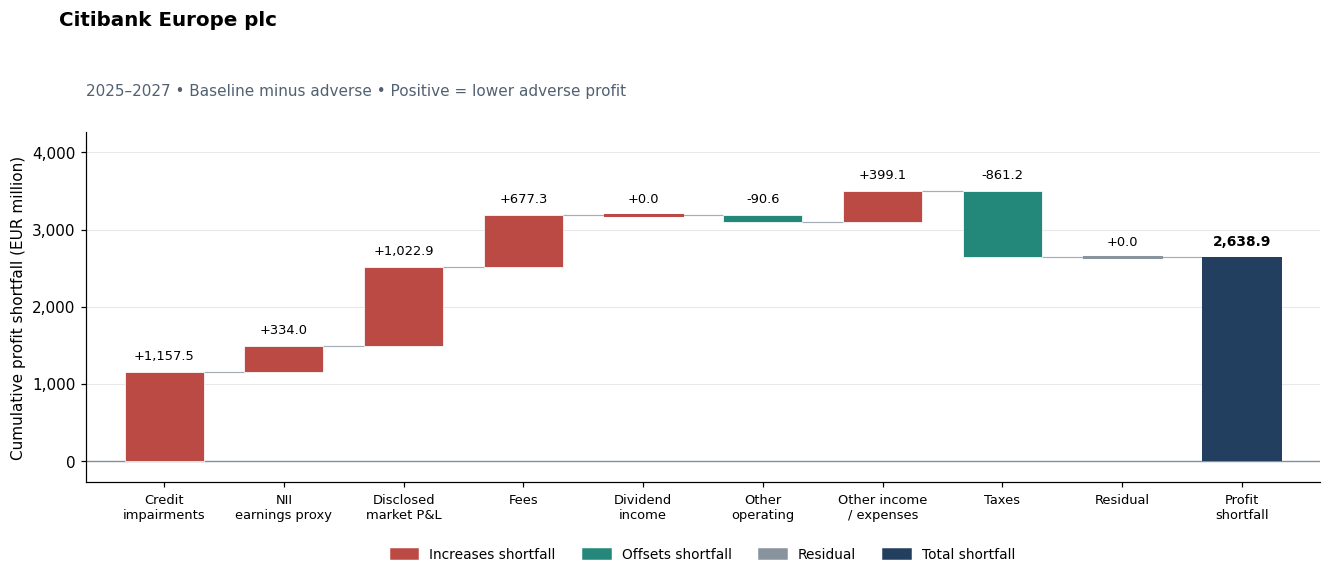

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-3,536.37"
Disclosed interest expense (signed),"3,870.33"
Derived NII adjustment remainder,-0.00
Total NII,333.96


In [56]:
report_bank('N1FBEDJ5J41VKZLO2475')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,814.0,-489.7,"1,303.7"
2026,"1,060.6",145.2,915.4
2027,"1,049.6",50.8,998.8
2025–2027 cumulative,"2,924.3",-293.6,"3,217.9"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,193.55","-3,655.97","2,462.43",76.52
NII (earnings proxy),"7,039.66","6,016.95","1,022.71",31.78
Trading P&L (market proxy),100.24,30.17,70.07,2.18
Non-trading FVPL revaluation,0.00,-97.81,97.81,3.04
Fees and commissions,"4,131.35","3,775.61",355.75,11.06
Dividend income,68.17,46.83,21.33,0.66
Other operating P&L (disclosed),661.92,603.04,58.88,1.83
Other income/expenses (incl. OR/CCR),"-6,854.46","-7,209.30",354.84,11.03
Taxes (signed P&L),"-1,029.07",196.84,"-1,225.91",-38.10
Unexplained residual,-0.00,-0.00,-0.00,-0.00


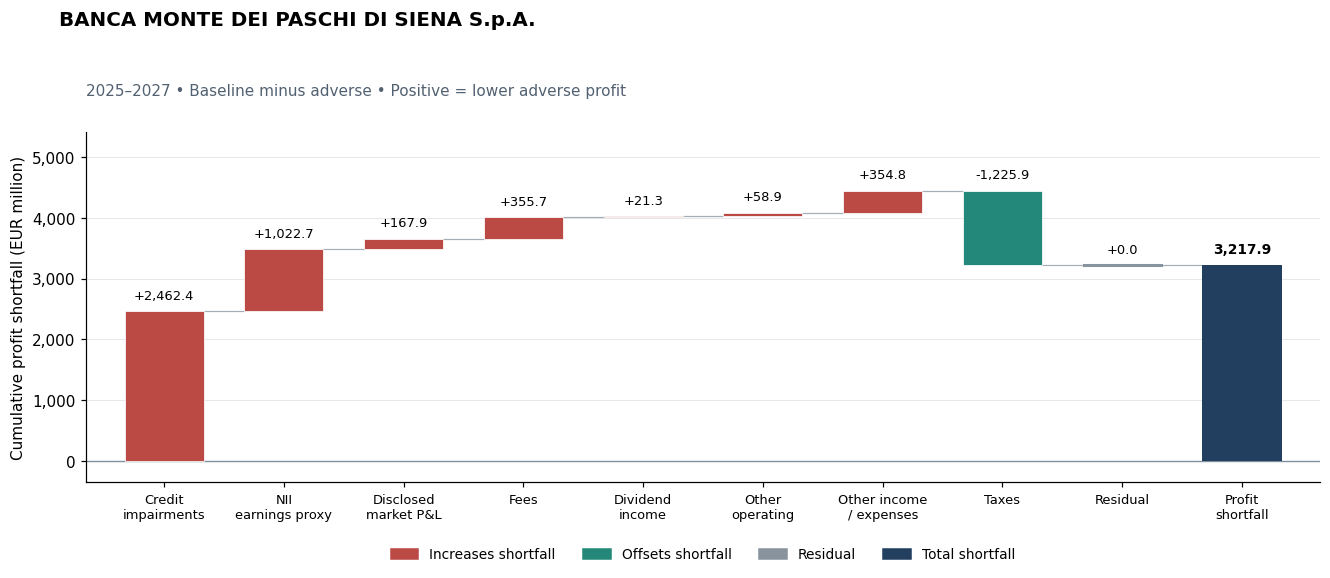

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,693.70"
Disclosed interest expense (signed),"3,716.41"
Derived NII adjustment remainder,0.00
Total NII,"1,022.71"


In [57]:
report_bank('J4CP7MHCXR8DAQMKIL78')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,647.2",105.6,"1,541.6"
2026,"1,587.3",541.8,"1,045.5"
2027,"1,507.6",558.7,948.9
2025–2027 cumulative,"4,742.2","1,206.1","3,536.1"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,531.47","-3,596.89","2,065.43",58.41
NII (earnings proxy),"11,104.26","9,506.14","1,598.12",45.19
Trading P&L (market proxy),0.00,-248.66,248.66,7.03
Non-trading FVPL revaluation,0.00,-20.78,20.78,0.59
Fees and commissions,"5,822.65","5,395.03",427.61,12.09
Dividend income,105.37,62.73,42.64,1.21
Other operating P&L (disclosed),991.22,698.59,292.62,8.28
Other income/expenses (incl. OR/CCR),"-9,717.79","-10,073.48",355.69,10.06
Taxes (signed P&L),"-2,032.04",-516.58,"-1,515.46",-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


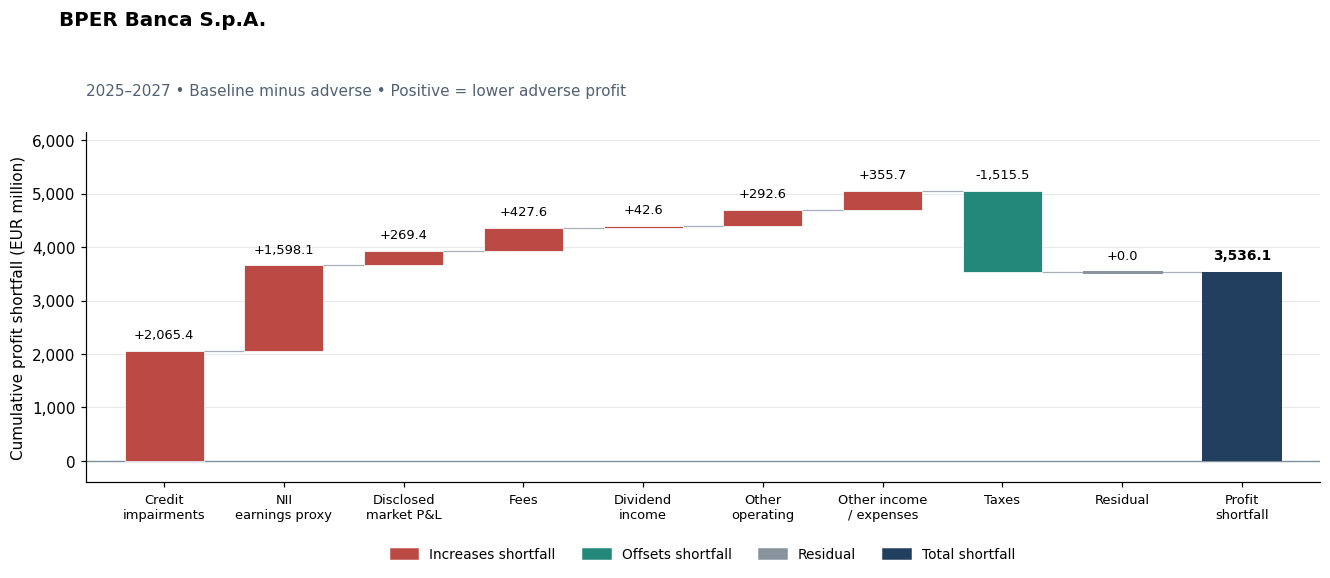

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,760.61"
Disclosed interest expense (signed),"4,052.70"
Derived NII adjustment remainder,306.03
Total NII,"1,598.12"


In [58]:
report_bank('N747OI7JINV7RUUH6190')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,532.2",-366.8,"1,898.9"
2026,"1,547.9",959.8,588.1
2027,"1,465.6",970.0,495.5
2025–2027 cumulative,"4,545.6","1,563.1","2,982.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,316.82","-3,486.44","2,169.62",72.74
NII (earnings proxy),"9,628.21","9,290.57",337.64,11.32
Trading P&L (market proxy),-55.35,-247.78,192.43,6.45
Non-trading FVPL revaluation,0.00,-507.98,507.98,17.03
Fees and commissions,"5,547.87","5,017.37",530.50,17.79
Dividend income,194.41,135.93,58.49,1.96
Other operating P&L (disclosed),914.11,914.21,-0.10,-0.00
Other income/expenses (incl. OR/CCR),"-8,531.76","-8,959.93",428.16,14.36
Taxes (signed P&L),"-1,835.05",-592.88,"-1,242.17",-41.65
Unexplained residual,-0.00,0.00,-0.00,-0.00


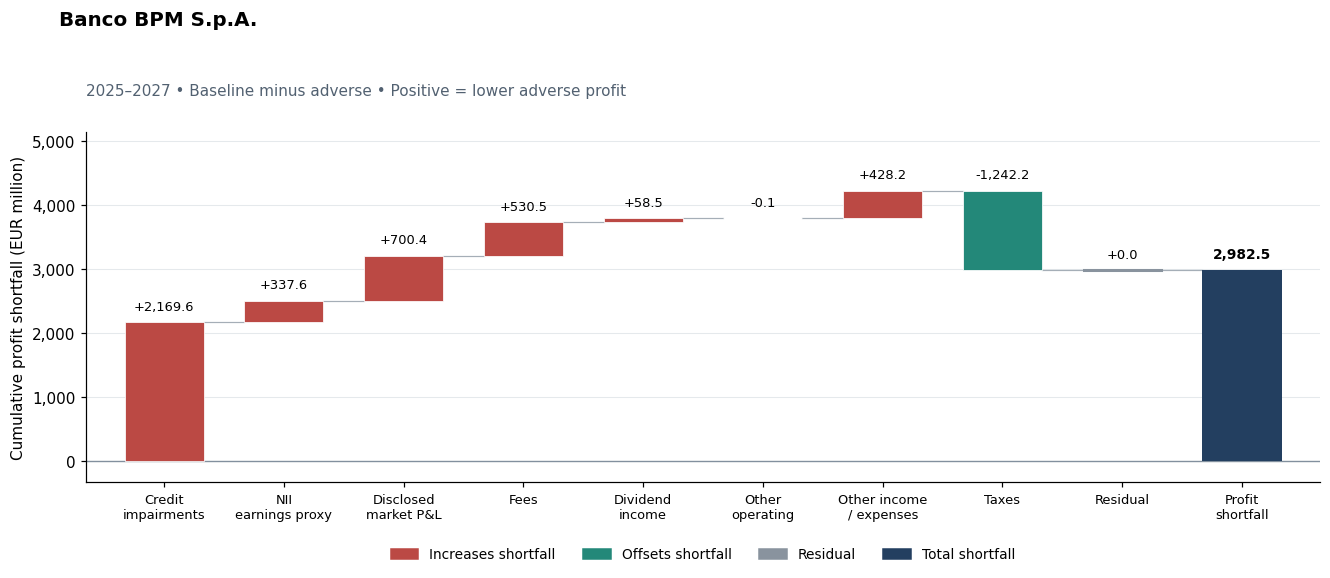

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-4,382.46"
Disclosed interest expense (signed),"4,720.10"
Derived NII adjustment remainder,0.00
Total NII,337.64


In [59]:
report_bank('815600E4E6DCD2D25E30')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,495.1",-510.4,"2,005.5"
2026,"1,395.6",320.1,"1,075.5"
2027,"1,351.7",439.5,912.2
2025–2027 cumulative,"4,242.4",249.2,"3,993.2"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,234.44","-4,215.83","2,981.38",74.66
NII (earnings proxy),"12,641.04","11,735.67",905.37,22.67
Trading P&L (market proxy),24.77,-128.71,153.48,3.84
Non-trading FVPL revaluation,0.00,-386.55,386.55,9.68
Fees and commissions,"3,890.52","3,415.79",474.73,11.89
Dividend income,75.02,37.51,37.51,0.94
Other operating P&L (disclosed),"1,170.65","1,167.86",2.78,0.07
Other income/expenses (incl. OR/CCR),"-10,510.19","-11,273.00",762.81,19.10
Taxes (signed P&L),"-1,814.91",-103.52,"-1,711.38",-42.86
Unexplained residual,-0.00,-0.00,0.00,0.00


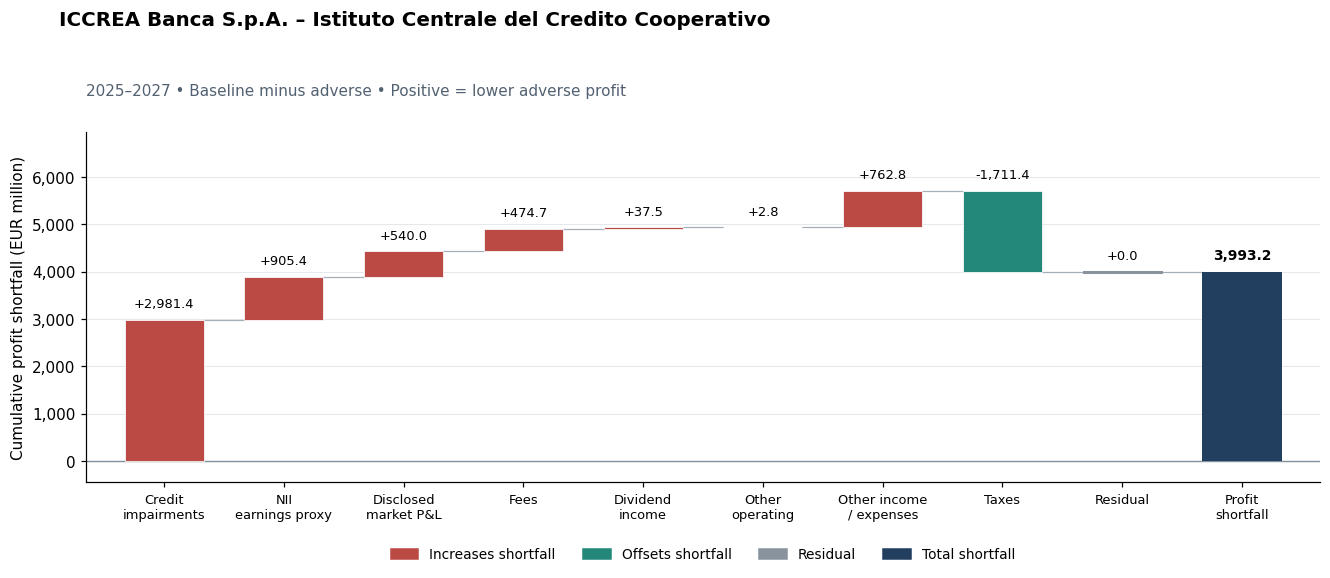

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-3,534.02"
Disclosed interest expense (signed),"4,439.38"
Derived NII adjustment remainder,-0.00
Total NII,905.37


In [60]:
report_bank('NNVPP80YIZGEY2314M97')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"8,997.4",223.8,"8,773.6"
2026,"8,709.4","4,265.8","4,443.6"
2027,"8,363.4","4,949.0","3,414.4"
2025–2027 cumulative,"26,070.1","9,438.5","16,631.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,842.85","-10,063.47","7,220.62",43.42
NII (earnings proxy),"47,329.10","38,940.62","8,388.48",50.44
Trading P&L (market proxy),0.00,339.36,-339.36,-2.04
Non-trading FVPL revaluation,0.00,"-1,643.23","1,643.23",9.88
Fees and commissions,"26,664.79","24,242.72","2,422.07",14.56
Dividend income,843.91,632.93,210.98,1.27
Other operating P&L (disclosed),"3,889.02","3,703.29",185.73,1.12
Other income/expenses (incl. OR/CCR),"-38,640.93","-42,668.60","4,027.67",24.22
Taxes (signed P&L),"-11,172.91","-4,045.09","-7,127.82",-42.86
Unexplained residual,-0.00,-0.00,-0.00,-0.00


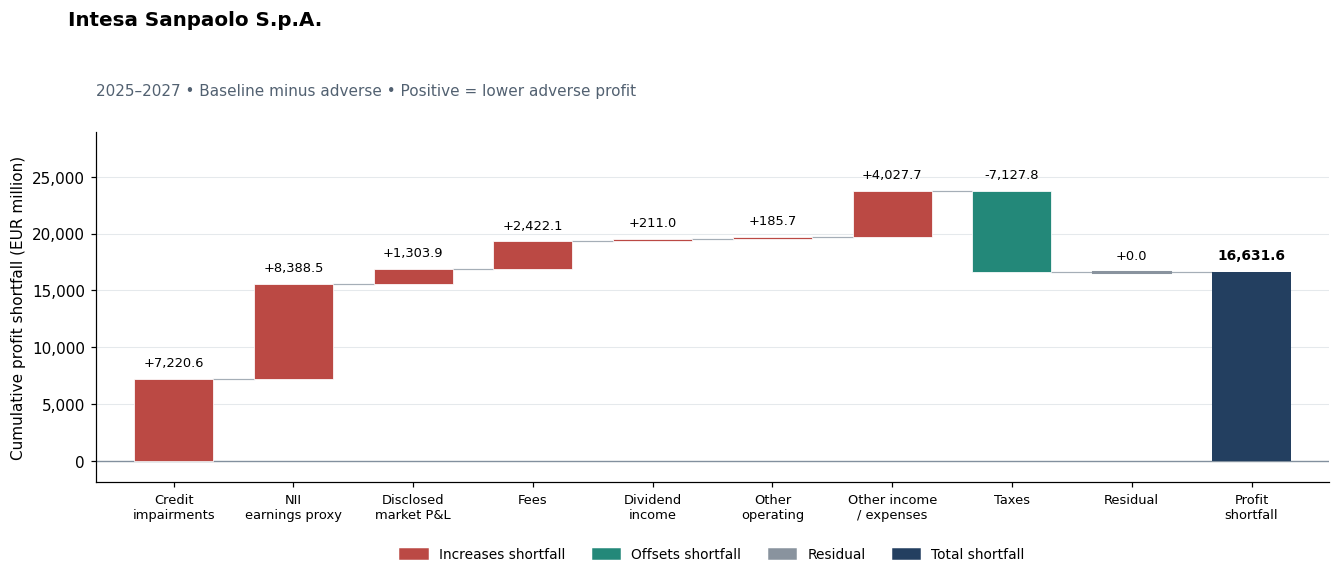

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-19,408.58"
Disclosed interest expense (signed),"27,797.06"
Derived NII adjustment remainder,0.00
Total NII,"8,388.48"


In [61]:
report_bank('2W8N8UU78PMDQKZENC08')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"10,120.7",576.4,"9,544.3"
2026,"9,333.9","5,244.2","4,089.7"
2027,"9,272.6","5,989.7","3,282.9"
2025–2027 cumulative,"28,727.2","11,810.3","16,916.9"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,493.81","-9,193.61","6,699.80",39.60
NII (earnings proxy),"45,694.32","38,513.27","7,181.04",42.45
Trading P&L (market proxy),"4,390.57",-526.01,"4,916.58",29.06
Non-trading FVPL revaluation,0.00,"1,054.30","-1,054.30",-6.23
Fees and commissions,"20,879.01","18,316.92","2,562.09",15.15
Dividend income,"1,264.64","1,028.95",235.69,1.39
Other operating P&L (disclosed),"2,370.30","1,851.74",518.56,3.07
Other income/expenses (incl. OR/CCR),"-31,975.04","-34,722.24","2,747.20",16.24
Taxes (signed P&L),"-11,402.83","-4,513.01","-6,889.82",-40.73
Unexplained residual,0.00,-0.00,0.00,0.00


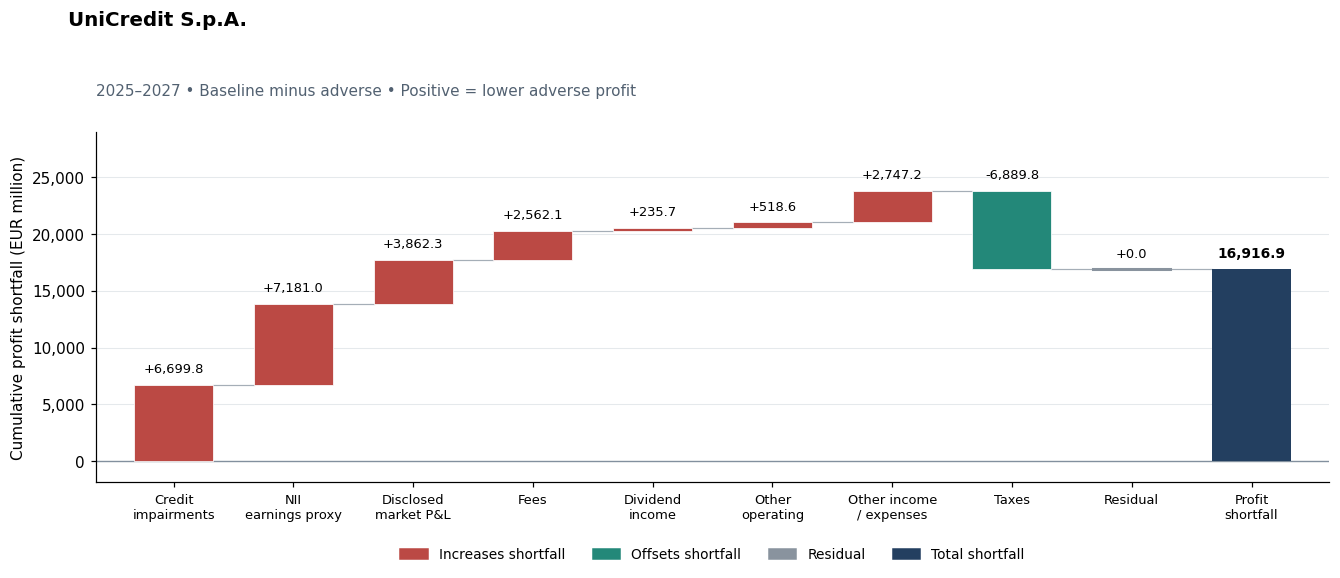

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-19,440.87"
Disclosed interest expense (signed),"26,621.92"
Derived NII adjustment remainder,0.00
Total NII,"7,181.04"


In [62]:
report_bank('549300TRUWO2CD2G5692')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,905.0","-2,356.8","4,261.8"
2026,"2,001.7",-6.3,"2,008.0"
2027,"1,830.7",263.9,"1,566.8"
2025–2027 cumulative,"5,737.5","-2,099.1","7,836.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,718.91","-6,121.29","4,402.38",56.18
NII (earnings proxy),"20,168.71","17,726.89","2,441.82",31.16
Trading P&L (market proxy),772.03,351.76,420.27,5.36
Non-trading FVPL revaluation,0.00,-543.09,543.09,6.93
Fees and commissions,"5,579.26","4,395.00","1,184.26",15.11
Dividend income,28.49,14.25,14.25,0.18
Other operating P&L (disclosed),356.27,-281.91,638.18,8.14
Other income/expenses (incl. OR/CCR),"-17,007.42","-18,540.35","1,532.93",19.56
Taxes (signed P&L),"-2,440.91",899.62,"-3,340.53",-42.63
Unexplained residual,-0.00,-0.00,-0.00,-0.00


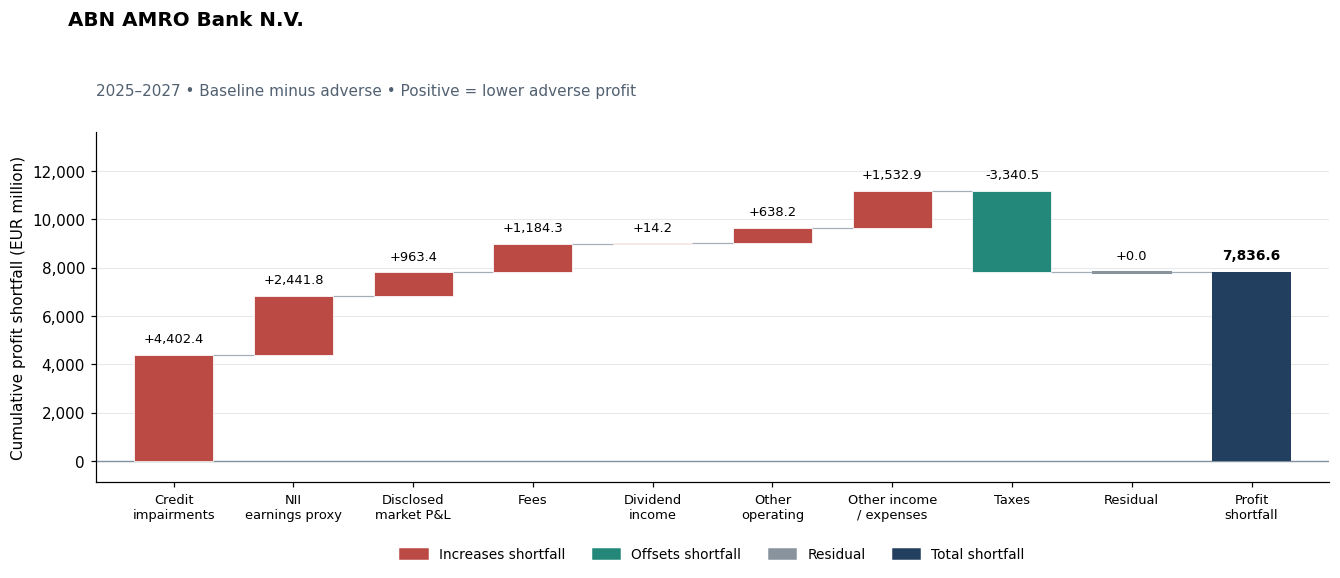

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-9,360.54"
Disclosed interest expense (signed),"11,768.79"
Derived NII adjustment remainder,33.57
Total NII,"2,441.82"


In [63]:
report_bank('BFXS5XCH7N0Y05NIXW11')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"5,318.5","-3,612.6","8,931.1"
2026,"5,383.0","1,502.3","3,880.7"
2027,"5,233.6","2,045.8","3,187.8"
2025–2027 cumulative,"15,935.1",-64.6,"15,999.7"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-2,991.11","-11,797.38","8,806.27",55.04
NII (earnings proxy),"40,958.09","35,836.09","5,122.00",32.01
Trading P&L (market proxy),"1,638.99",-330.76,"1,969.75",12.31
Non-trading FVPL revaluation,0.00,"-1,106.51","1,106.51",6.92
Fees and commissions,"6,469.80","4,816.49","1,653.30",10.33
Dividend income,76.01,38.01,38.01,0.24
Other operating P&L (disclosed),"1,889.07","1,226.23",662.83,4.14
Other income/expenses (incl. OR/CCR),"-25,629.73","-29,022.44","3,392.71",21.20
Taxes (signed P&L),"-6,476.01",275.69,"-6,751.70",-42.20
Unexplained residual,0.00,0.00,-0.00,-0.00


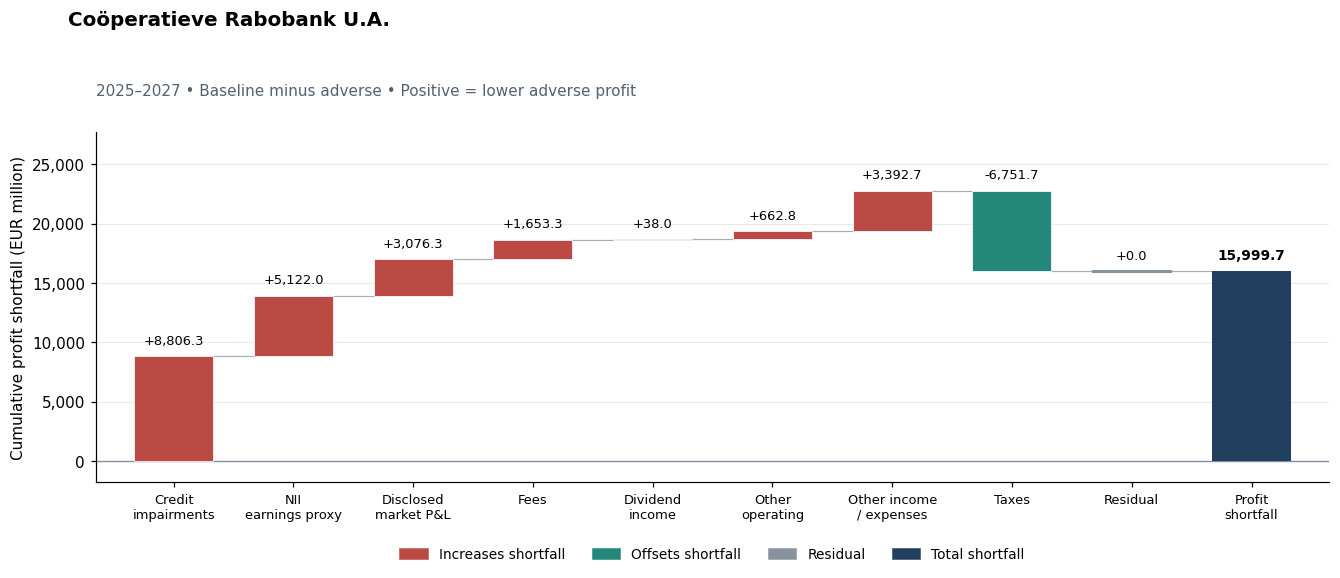

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-9,332.36"
Disclosed interest expense (signed),"13,361.19"
Derived NII adjustment remainder,"1,093.17"
Total NII,"5,122.00"


In [64]:
report_bank('DG3RU1DBUFHT4ZF9WN62')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"6,303.3","-3,846.5","10,149.8"
2026,"6,324.9","2,053.7","4,271.2"
2027,"6,049.1","2,483.5","3,565.6"
2025–2027 cumulative,"18,677.3",690.7,"17,986.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-3,102.72","-10,850.12","7,747.40",43.07
NII (earnings proxy),"50,634.85","41,750.07","8,884.78",49.40
Trading P&L (market proxy),"5,612.49",778.57,"4,833.92",26.88
Non-trading FVPL revaluation,0.00,-286.78,286.78,1.59
Fees and commissions,"11,152.99","8,345.86","2,807.13",15.61
Dividend income,401.68,270.63,131.06,0.73
Other operating P&L (disclosed),370.60,925.29,-554.69,-3.08
Other income/expenses (incl. OR/CCR),"-38,387.98","-39,890.00","1,502.02",8.35
Taxes (signed P&L),"-8,004.58",-352.80,"-7,651.78",-42.54
Unexplained residual,-0.00,-0.00,-0.00,-0.00


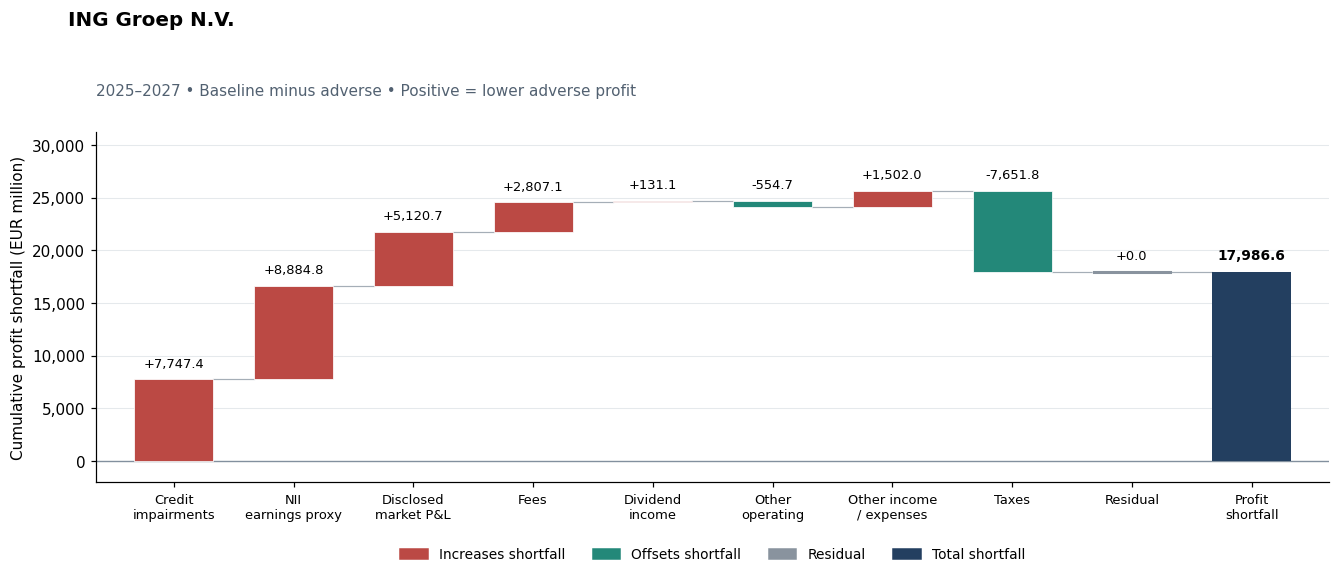

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-23,475.53"
Disclosed interest expense (signed),"30,874.22"
Derived NII adjustment remainder,"1,486.09"
Total NII,"8,884.78"


In [65]:
report_bank('549300NYKK9MWM7GGW15')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,416.9",311.5,"2,105.4"
2026,"2,873.6","1,885.3",988.3
2027,"2,950.1","1,950.5",999.6
2025–2027 cumulative,"8,240.6","4,147.2","4,093.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-578.25,"-3,339.21","2,760.96",67.45
NII (earnings proxy),"16,644.51","16,099.21",545.29,13.32
Trading P&L (market proxy),"1,176.50",-7.44,"1,183.93",28.92
Non-trading FVPL revaluation,0.00,-71.69,71.69,1.75
Fees and commissions,"2,898.32","2,254.25",644.07,15.73
Dividend income,438.71,341.22,97.49,2.38
Other operating P&L (disclosed),90.32,-52.51,142.83,3.49
Other income/expenses (incl. OR/CCR),"-8,897.79","-9,299.20",401.41,9.81
Taxes (signed P&L),"-3,531.69","-1,777.39","-1,754.30",-42.86
Unexplained residual,-0.00,-0.00,-0.00,-0.00


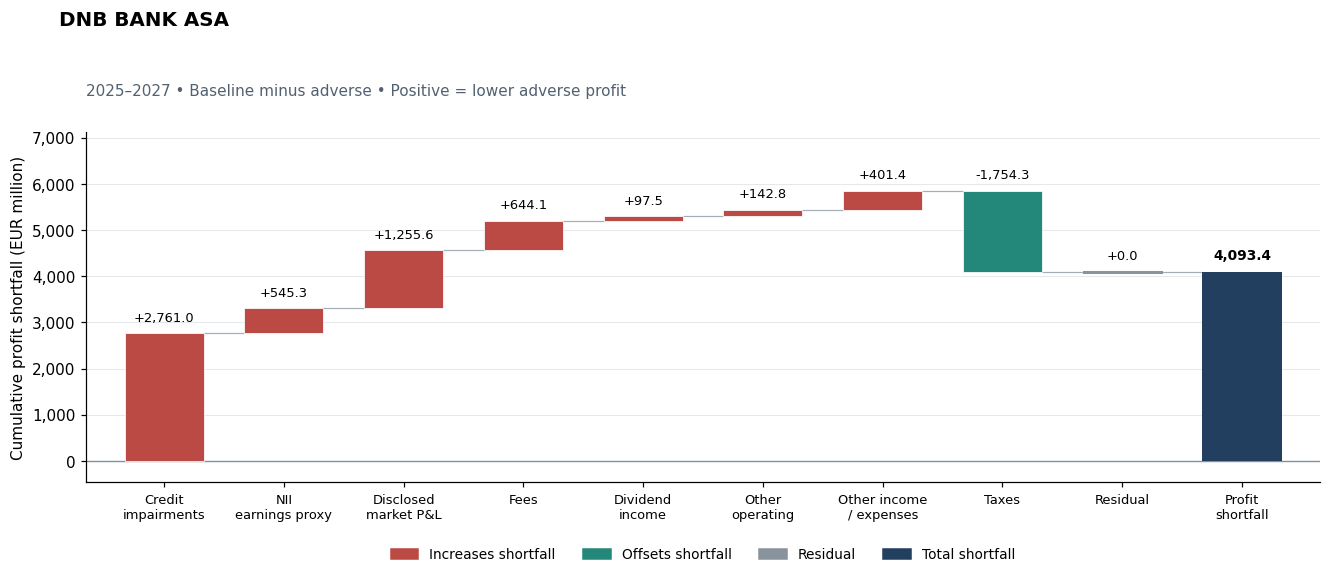

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-13,564.07"
Disclosed interest expense (signed),"9,299.08"
Derived NII adjustment remainder,"4,810.29"
Total NII,545.29


In [66]:
report_bank('549300GKFG0RYRRQ1414')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,919.1,-5.5,924.7
2026,"1,401.0",995.6,405.5
2027,"1,455.7","1,034.1",421.6
2025–2027 cumulative,"3,775.8","2,024.1","1,751.7"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-735.95,"-1,505.97",770.02,43.96
NII (earnings proxy),"9,303.90","8,332.30",971.60,55.47
Trading P&L (market proxy),56.97,-4.35,61.32,3.50
Non-trading FVPL revaluation,0.00,-38.70,38.70,2.21
Fees and commissions,"1,960.70","1,574.61",386.09,22.04
Dividend income,21.05,15.79,5.26,0.30
Other operating P&L (disclosed),28.77,26.11,2.66,0.15
Other income/expenses (incl. OR/CCR),"-5,241.40","-5,505.78",264.38,15.09
Taxes (signed P&L),"-1,618.21",-869.86,-748.35,-42.72
Unexplained residual,-0.00,-0.00,-0.00,-0.00


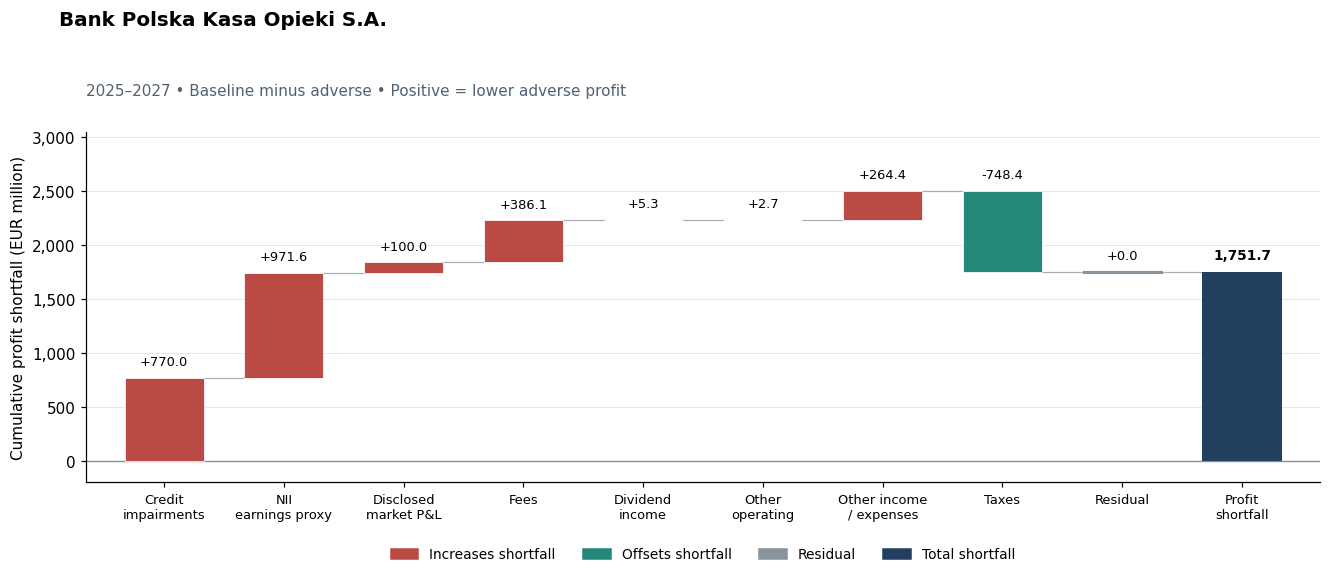

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,-416.36
Disclosed interest expense (signed),909.87
Derived NII adjustment remainder,478.09
Total NII,971.60


In [67]:
report_bank('5493000LKS7B3UTF7H35')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,109.2",786.3,"1,322.8"
2026,"2,422.3","1,193.1","1,229.2"
2027,"2,656.5","1,474.2","1,182.3"
2025–2027 cumulative,"7,188.0","3,453.7","3,734.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-845.72,"-2,041.62","1,195.89",32.02
NII (earnings proxy),"17,201.19","14,441.05","2,760.14",73.91
Trading P&L (market proxy),0.00,-67.88,67.88,1.82
Non-trading FVPL revaluation,0.00,-7.71,7.71,0.21
Fees and commissions,"3,662.98","3,027.56",635.43,17.02
Dividend income,10.10,7.58,2.53,0.07
Other operating P&L (disclosed),473.73,384.88,88.85,2.38
Other income/expenses (incl. OR/CCR),"-10,233.65","-10,810.04",576.38,15.43
Taxes (signed P&L),"-3,080.59","-1,480.14","-1,600.44",-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


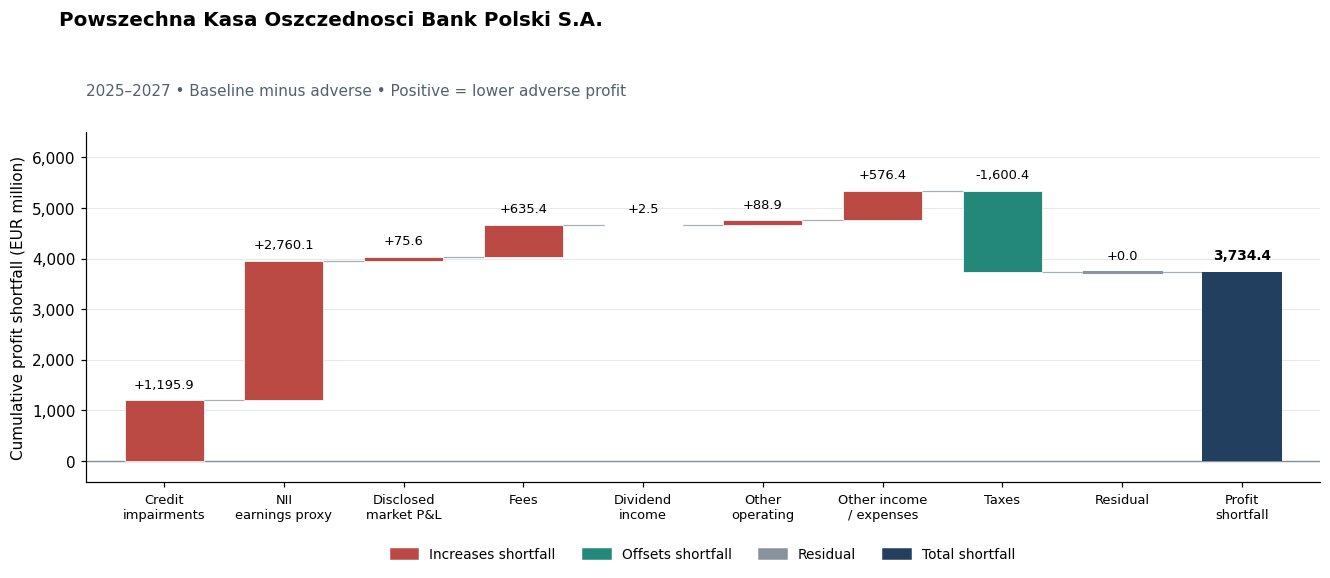

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,559.57"
Disclosed interest expense (signed),"3,102.76"
Derived NII adjustment remainder,"1,216.94"
Total NII,"2,760.14"


In [68]:
report_bank('P4GTT6GF1W40CVIMFR43')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,235.1",-165.8,"1,400.8"
2026,"1,438.6",695.1,743.4
2027,"1,474.8",868.8,606.0
2025–2027 cumulative,"4,148.4","1,398.1","2,750.3"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-842.93,"-2,692.65","1,849.71",67.26
NII (earnings proxy),"9,400.50","7,787.60","1,612.90",58.64
Trading P&L (market proxy),-5.59,-584.29,578.70,21.04
Non-trading FVPL revaluation,0.00,467.04,-467.04,-16.98
Fees and commissions,"2,411.34","2,043.82",367.51,13.36
Dividend income,3.05,1.52,1.52,0.06
Other operating P&L (disclosed),-129.17,162.34,-291.51,-10.60
Other income/expenses (incl. OR/CCR),"-5,083.65","-5,343.38",259.73,9.44
Taxes (signed P&L),"-1,605.14",-443.88,"-1,161.26",-42.22
Unexplained residual,-0.00,-0.00,-0.00,-0.00


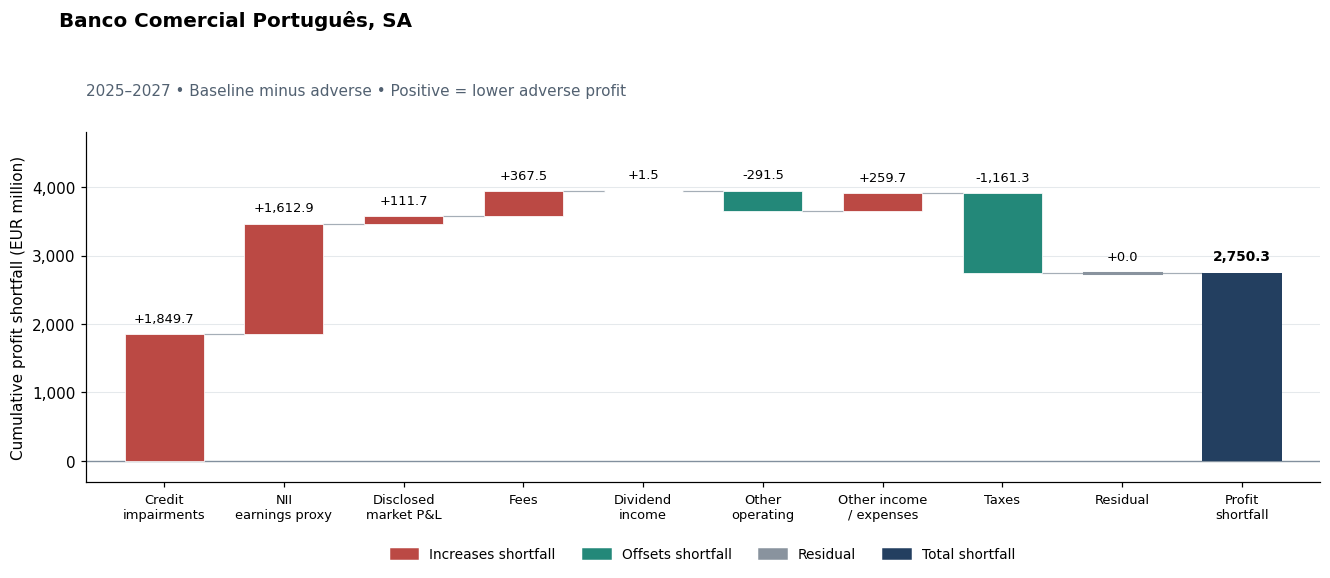

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,893.10"
Disclosed interest expense (signed),"3,293.59"
Derived NII adjustment remainder,212.41
Total NII,"1,612.90"


In [69]:
report_bank('JU1U6S0DG9YLT7N8ZV32')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,832.3",231.9,"1,600.4"
2026,"1,324.1",681.6,642.5
2027,"1,289.5",821.0,468.5
2025–2027 cumulative,"4,445.9","1,734.5","2,711.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-165.87,"-2,143.33","1,977.45",72.93
NII (earnings proxy),"7,593.98","6,928.26",665.72,24.55
Trading P&L (market proxy),107.37,-141.02,248.39,9.16
Non-trading FVPL revaluation,0.00,-251.93,251.93,9.29
Fees and commissions,"1,753.60","1,397.01",356.60,13.15
Dividend income,1.19,0.60,0.60,0.02
Other operating P&L (disclosed),275.50,152.45,123.05,4.54
Other income/expenses (incl. OR/CCR),"-3,273.08","-3,509.08",236.00,8.70
Taxes (signed P&L),"-1,846.78",-698.43,"-1,148.35",-42.35
Unexplained residual,-0.00,-0.00,0.00,0.00


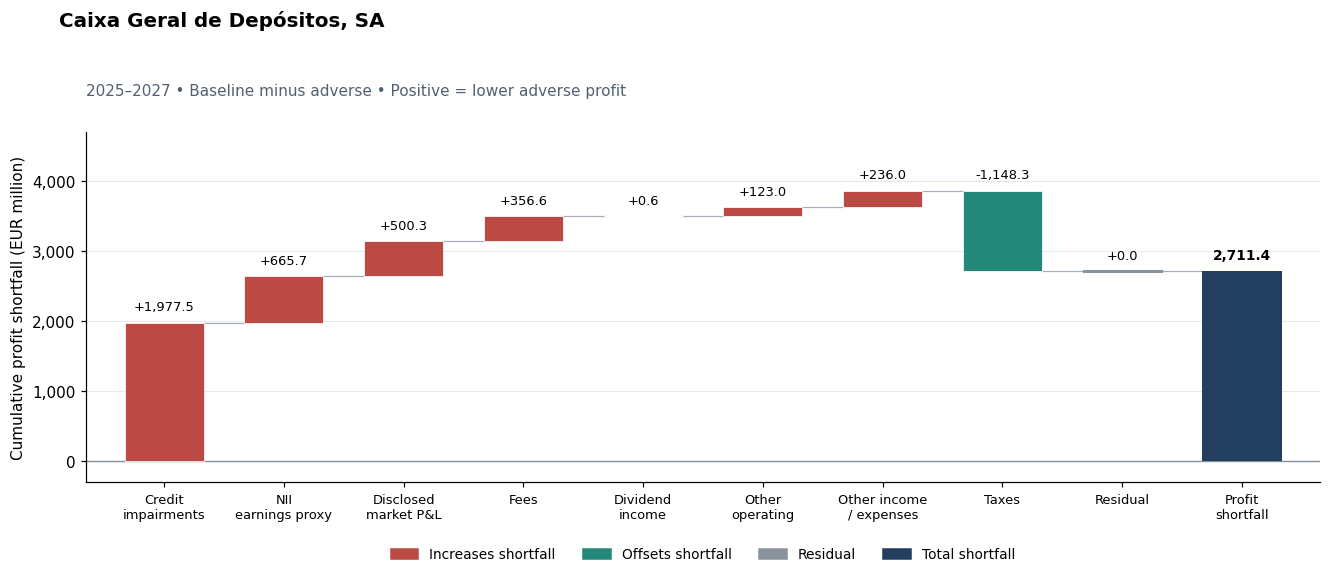

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-2,631.95"
Disclosed interest expense (signed),"3,297.67"
Derived NII adjustment remainder,0.00
Total NII,665.72


In [70]:
report_bank('TO822O0VT80V06K0FH57')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,580.5,-24.8,605.3
2026,533.4,-24.4,557.7
2027,413.1,106.8,306.3
2025–2027 cumulative,"1,527.0",57.6,"1,469.4"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-437.43,"-1,365.31",927.88,63.15
NII (earnings proxy),"4,518.75","3,882.95",635.80,43.27
Trading P&L (market proxy),75.07,-37.71,112.78,7.68
Non-trading FVPL revaluation,0.00,-121.26,121.26,8.25
Fees and commissions,853.03,686.00,167.03,11.37
Dividend income,9.45,4.59,4.86,0.33
Other operating P&L (disclosed),202.17,183.23,18.94,1.29
Other income/expenses (incl. OR/CCR),"-3,039.65","-3,150.21",110.55,7.52
Taxes (signed P&L),-654.42,-24.69,-629.73,-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


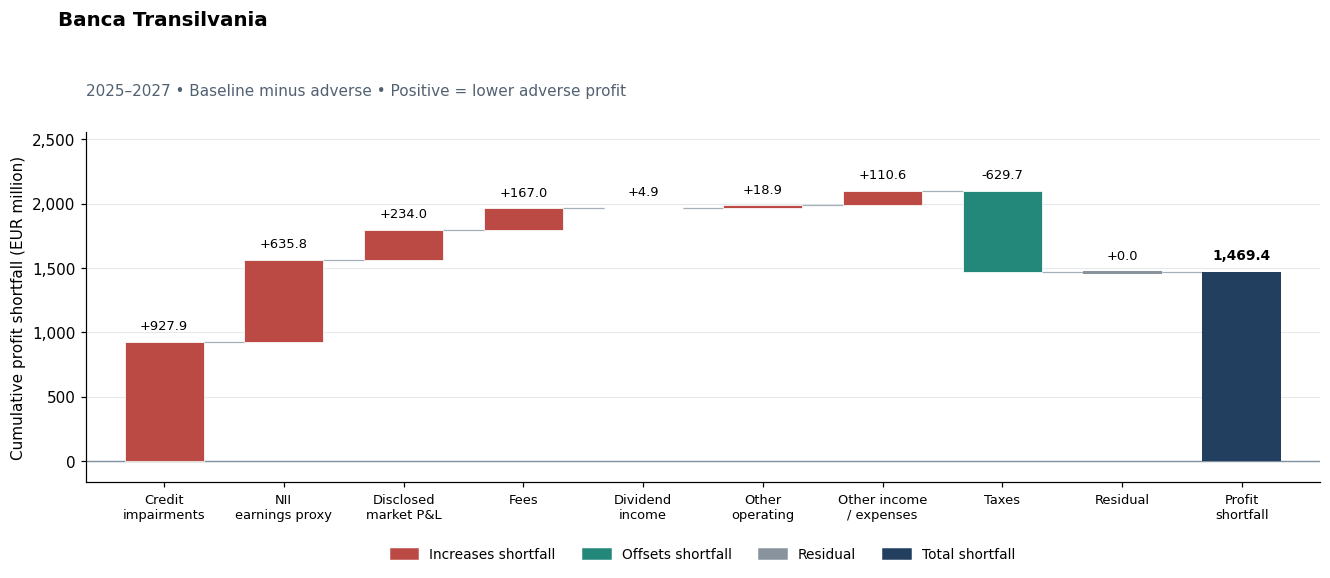

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,-810.97
Disclosed interest expense (signed),"1,186.55"
Derived NII adjustment remainder,260.21
Total NII,635.80


In [71]:
report_bank('549300RG3H390KEL8896')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,168.5,58.7,109.8
2026,142.9,81.9,61.0
2027,130.3,67.2,63.2
2025–2027 cumulative,441.7,207.7,233.9


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-53.24,-252.30,199.05,85.09
NII (earnings proxy),"1,842.28","1,750.31",91.97,39.32
Trading P&L (market proxy),0.00,0.00,-0.00,-0.00
Non-trading FVPL revaluation,0.00,-3.11,3.11,1.33
Fees and commissions,-287.05,-287.05,0.00,0.00
Dividend income,0.19,0.09,0.09,0.04
Other operating P&L (disclosed),-45.15,-31.15,-14.00,-5.98
Other income/expenses (incl. OR/CCR),-826.06,-880.01,53.95,23.06
Taxes (signed P&L),-189.29,-89.04,-100.25,-42.86
Unexplained residual,-0.00,0.00,-0.00,-0.00


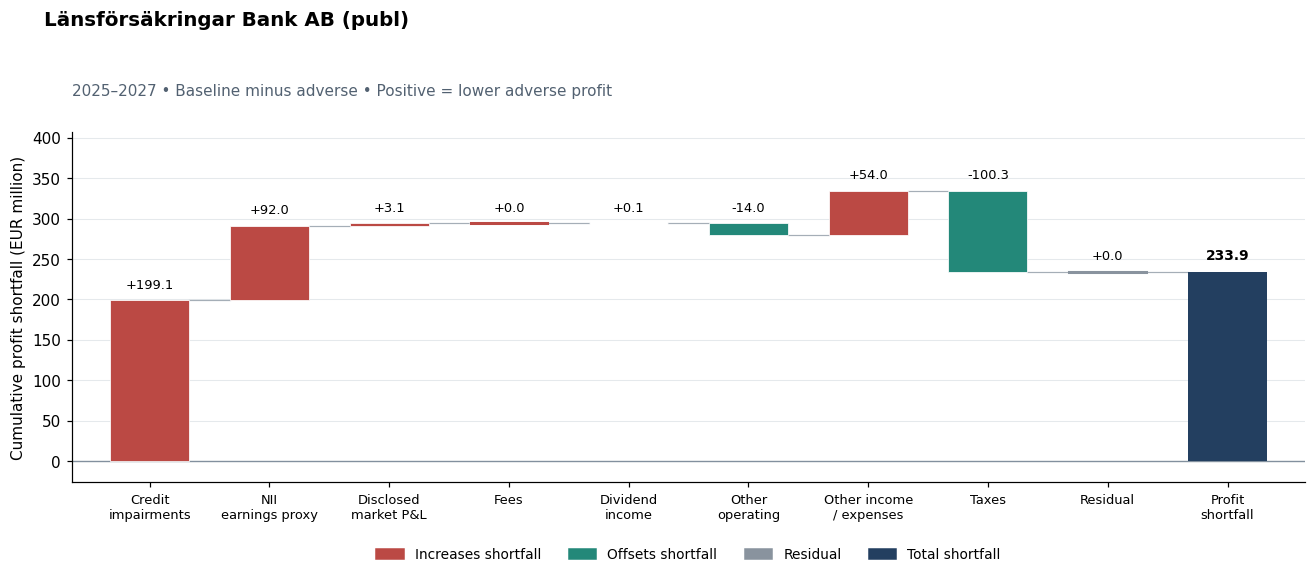

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,167.27"
Disclosed interest expense (signed),"1,194.56"
Derived NII adjustment remainder,64.69
Total NII,91.97


In [72]:
report_bank('549300C6TUMDXNOVXS82')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,193.2,-39.7,232.9
2026,174.5,10.9,163.6
2027,177.5,-25.5,202.9
2025–2027 cumulative,545.2,-54.3,599.5


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-21.87,-765.06,743.19,123.98
NII (earnings proxy),"1,470.13","1,401.42",68.71,11.46
Trading P&L (market proxy),0.00,-14.37,14.37,2.40
Non-trading FVPL revaluation,0.00,0.00,0.00,0.00
Fees and commissions,-12.92,-12.92,0.00,0.00
Dividend income,0.00,0.00,0.00,0.00
Other operating P&L (disclosed),0.54,9.46,-8.92,-1.49
Other income/expenses (incl. OR/CCR),-657.09,-684.44,27.35,4.56
Taxes (signed P&L),-233.64,11.61,-245.25,-40.91
Unexplained residual,-0.00,-0.00,0.00,0.00


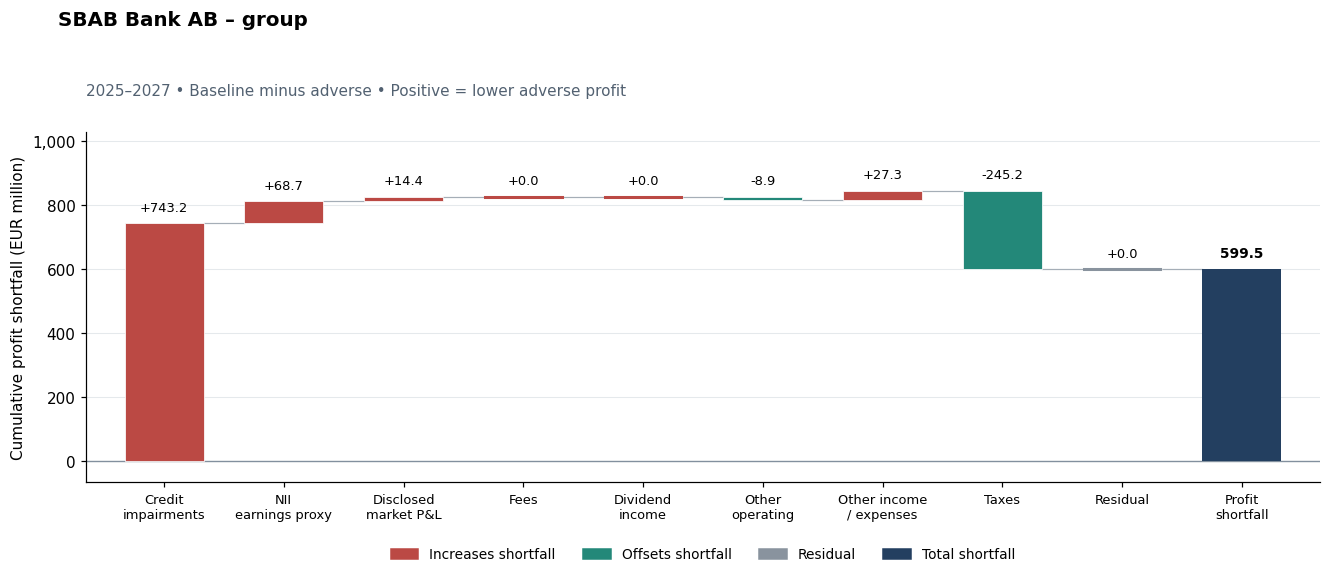

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-1,681.18"
Disclosed interest expense (signed),"1,619.26"
Derived NII adjustment remainder,130.62
Total NII,68.71


In [73]:
report_bank('H0YX5LBGKDVOWCXBZ594')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"3,105.0","-1,124.1","4,229.1"
2026,"2,784.7",966.8,"1,818.0"
2027,"2,543.6",692.1,"1,851.6"
2025–2027 cumulative,"8,433.4",534.7,"7,898.6"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),-344.93,"-5,621.40","5,276.47",66.80
NII (earnings proxy),"12,513.46","10,778.43","1,735.03",21.97
Trading P&L (market proxy),"1,947.60","1,626.27",321.33,4.07
Non-trading FVPL revaluation,0.00,-267.00,267.00,3.38
Fees and commissions,"5,397.57","4,428.54",969.03,12.27
Dividend income,682.87,342.00,340.87,4.32
Other operating P&L (disclosed),183.85,-403.13,586.98,7.43
Other income/expenses (incl. OR/CCR),"-8,332.75","-9,638.03","1,305.28",16.53
Taxes (signed P&L),"-3,614.30",-710.93,"-2,903.37",-36.76
Unexplained residual,-0.00,0.00,-0.00,-0.00


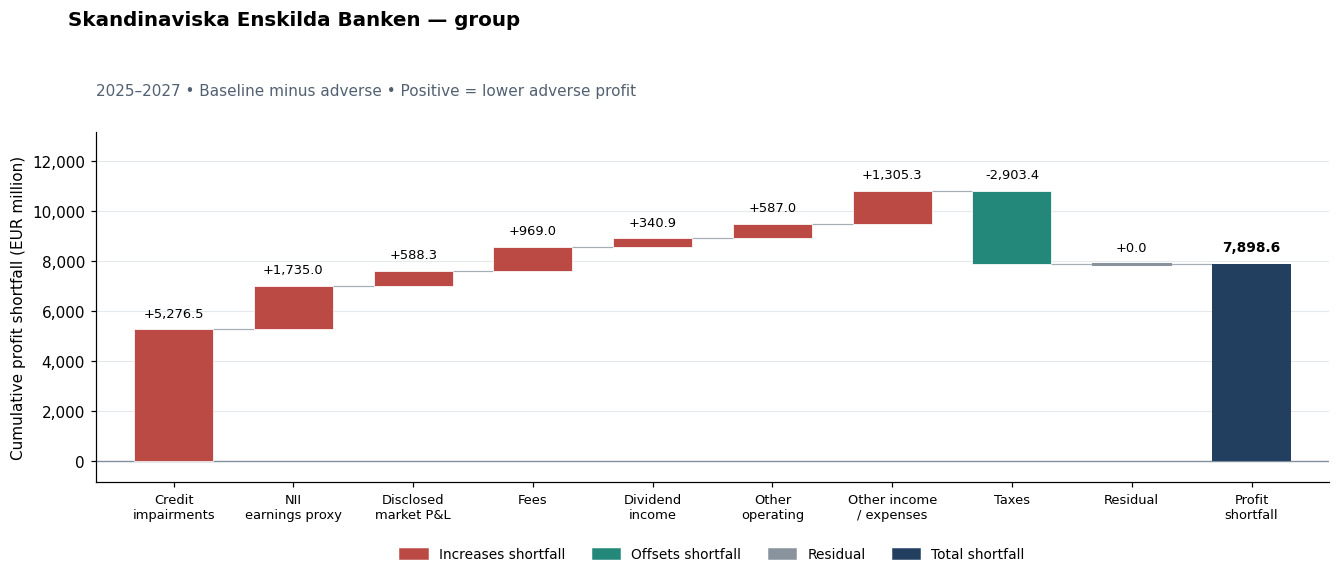

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-6,286.66"
Disclosed interest expense (signed),"8,021.68"
Derived NII adjustment remainder,0.00
Total NII,"1,735.03"


In [74]:
report_bank('F3JS33DEI6XQ4ZBPTN86')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"1,912.2",-833.6,"2,745.8"
2026,"1,720.0",623.2,"1,096.8"
2027,"1,580.4",497.5,"1,082.9"
2025–2027 cumulative,"5,212.6",287.1,"4,925.5"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),41.77,"-4,703.58","4,745.35",96.34
NII (earnings proxy),"12,276.25","11,438.63",837.62,17.01
Trading P&L (market proxy),145.29,14.15,131.14,2.66
Non-trading FVPL revaluation,0.00,-57.07,57.07,1.16
Fees and commissions,"2,397.40","1,812.94",584.46,11.87
Dividend income,4.23,2.11,2.11,0.04
Other operating P&L (disclosed),42.48,38.23,4.25,0.09
Other income/expenses (incl. OR/CCR),"-7,460.87","-7,778.05",317.18,6.44
Taxes (signed P&L),"-2,233.96",-480.29,"-1,753.68",-35.60
Unexplained residual,-0.00,-0.00,0.00,0.00


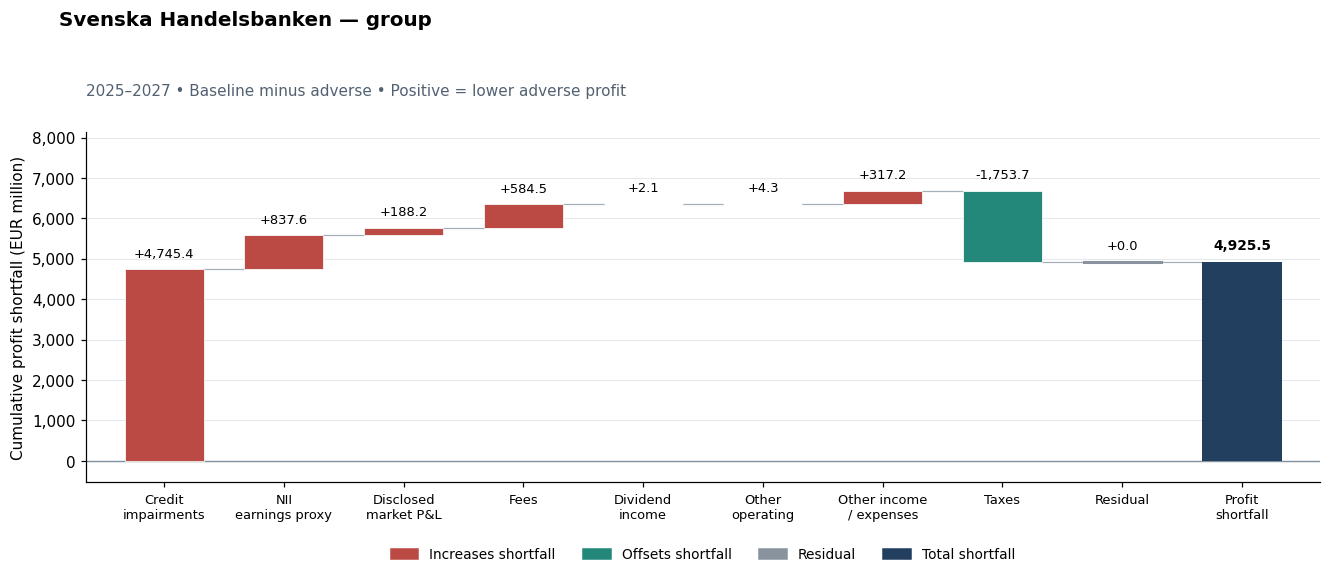

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-7,343.63"
Disclosed interest expense (signed),"7,992.49"
Derived NII adjustment remainder,188.76
Total NII,837.62


The linked December 2025 revision concerns STREA only; its P&L agrees with the database.

In [75]:
report_bank('NHBDILHZTYCNBV5UYZ31')

Period,Baseline profit,Adverse profit,Profit shortfall
2025,"2,054.4",-44.8,"2,099.2"
2026,"2,153.6",645.8,"1,507.8"
2027,"2,003.7",964.9,"1,038.8"
2025–2027 cumulative,"6,211.7","1,565.9","4,645.8"


Driver,Baseline P&L (EUR m),Adverse P&L (EUR m),Shortfall contribution (EUR m),Share of shortfall (%)
Credit impairments (proxy),"-1,219.94","-4,077.46","2,857.51",61.51
NII (earnings proxy),"12,645.86","12,185.37",460.49,9.91
Trading P&L (market proxy),649.82,645.93,3.90,0.08
Non-trading FVPL revaluation,0.00,-83.49,83.49,1.80
Fees and commissions,"3,993.01","3,168.70",824.31,17.74
Dividend income,60.00,30.00,30.00,0.65
Other operating P&L (disclosed),560.59,711.51,-150.92,-3.25
Other income/expenses (incl. OR/CCR),"-7,748.28","-10,326.48","2,578.20",55.50
Taxes (signed P&L),"-2,729.40",-688.20,"-2,041.20",-43.94
Unexplained residual,0.00,0.00,-0.00,-0.00


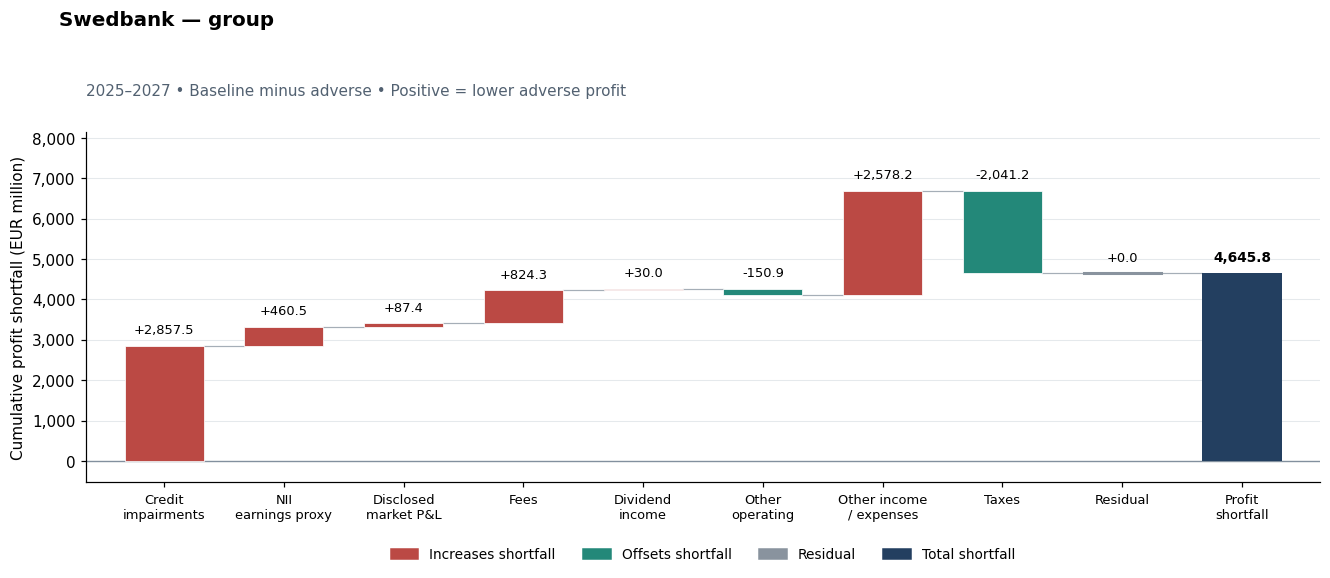

Supplementary NII component,Shortfall contribution (EUR m)
Disclosed interest income,"-7,081.58"
Disclosed interest expense (signed),"7,429.48"
Derived NII adjustment remainder,112.59
Total NII,460.49


In [76]:
report_bank('M312WZV08Y7LYUC71685')

## 6. Reuse, exports and limitations

The numeric objects are available for further work: `facts` (original decoded data), `field_map`,
`annual`, `baseline_totals`, `adverse_totals`, `results`, `validation`, and `nii_diagnostic_shortfall`.
`report_bank(lei)` regenerates a bank's report. Set `EXPORT_RESULTS=True` near the start and rerun
to save machine-readable CSVs and all individual chart PNGs. File paths are relative to the kernel's
working directory. Default execution creates no additional files.

This decomposition exhausts the public P&L lines, which is why the accounting residual is normally
numerical noise. That does **not** mean every economic risk is separately identified. Banks' private
supervisory calculation templates would be required to isolate conduct, other operational risk,
CCR defaults, reference-rate versus margin effects, and valuation-reserve subcomponents. Public
aggregate operational-loss statistics must not be allocated to individual banks without evidence.
Zero residual also does not prove that the stress-test models are accurate.

The common shocks and methodological constraints create interdependencies across risks.
The report is an arithmetic comparison of two prescribed scenarios, with neither factor-by-factor
causal attribution nor capital sensitivity analysis. It uses the EBA regulatory consolidation perimeter
and preserves bank-specific disclosure notes. For legal/official results, the bank PDFs take precedence
over analytical CSV tools; representative PDF checks are included, not a claim to have independently
audited every source PDF.

In [77]:
if report_count != EXPECTED_BANKS:
    raise ValueError(f'Expected {EXPECTED_BANKS} bank reports, generated {report_count}')
if EXPORT_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    results.to_csv(OUTPUT_DIR/'bank_profit_shortfalls.csv', index_label='lei_code', encoding='utf-8-sig')
    annual.to_csv(OUTPUT_DIR/'annual_pnl.csv', encoding='utf-8-sig')
    field_map.to_csv(OUTPUT_DIR/'field_mappings_2025.csv', encoding='utf-8-sig')
    validation.to_csv(OUTPUT_DIR/'validation_checks.csv', index=False, encoding='utf-8-sig')
    pd.Series({lei:bank_explanation(lei) for lei in results.index},name='explanation').to_csv(
        OUTPUT_DIR/'bank_explanations.csv',index_label='lei_code',encoding='utf-8-sig')
    print(f'Optional exports written to {OUTPUT_DIR.resolve()}')
print(f'Completed: {report_count} bank tables, waterfalls and explanations; {len(validation)} numerical and 7 behavioural checks.')

Completed: 64 bank tables, waterfalls and explanations; 24 numerical and 7 behavioural checks.
